# Calibrated Parenclitic Networks for Short, Non-Stationary Multivariate Systems

Reference implementation for *Calibrated Parenclitic Networks for Short,
Non-Stationary Multivariate Systems: An Application to Urban Resilience*
(PourmoradNasseri, Gholidoust & Albadvi), applied to the URSA Vancouver
indicator system, 2011–2024.

The notebook runs top to bottom and reproduces every number, table and figure
in the manuscript and its supplementary material.

## What the framework does

For each unordered pair of sub-indicators and each target year `t`, a bivariate
reference distribution is estimated from co-observed years **strictly before**
`t` (leave-future-out, LFO).  The parenclitic edge weight is the Mahalanobis
distance of the year-`t` observation from that reference.  An edge is
*activated* when the weight exceeds an exact small-sample threshold derived
from the scaled `F(2, n-2)` law rather than the asymptotic `chi^2(2)`.  Network
anomaly density (NAD) is then baseline-corrected against a circular-block
permutation null that preserves each series' within-series autocorrelation and
trend.

Three properties of the construction matter, and each is verified in the code:

1. **LFO baselines** remove contamination of the reference by the events being
   detected.
2. **F-corrected thresholds** hold the nominal 5% activation rate at every
   training-window size; the `chi^2` approximation reaches a 55.6% false-positive
   rate at `n = 3` (§ *Synthetic calibration*).
3. **The circular-block null** absorbs the residual autocorrelation-driven
   inflation that survives the threshold correction.

## Inputs

| File | Description |
|---|---|
| `Input.xlsx` | 186 sub-indicators × 14 years (2011–2024), one sheet |
| `v1_urban_indicators_master_with_explanation.csv` | indicator/domain hierarchy |

Paths are set in the configuration cell below.

## Outputs

All written to `results/`:

| File | Contents |
|---|---|
| `paper_numbers.json` | every reported quantity, six decimal places |
| `indicator_duration.csv` | indicator-level anomaly durations (Table V) |
| `clip_check_output.json` | training-correlation clip sensitivity (Supp. S1) |
| `*.png` | manuscript figures |

## Requirements

`numpy`, `pandas`, `scipy`, `matplotlib`, `seaborn`, `networkx`, `openpyxl`.

## 1. Configuration

Global constants, activation-threshold table (manuscript Table III), and the
scenario definitions used to annotate the figures.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import pearsonr, chi2, f as f_dist
from scipy.stats import shapiro
from scipy.spatial.distance import mahalanobis
import warnings, os
warnings.filterwarnings('ignore')

DATA_DIR    = 'data'
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

INPUT_FILE  = os.path.join(DATA_DIR, 'Input.xlsx')
ADJ_FILE    = os.path.join(DATA_DIR, 'adjacency.csv')
NAMES_FILE  = os.path.join(DATA_DIR, 'names.csv')

# ── Parameters ────────────────────────────────────────────────────────────────
TIER1_MIN    = 7
TIER2_MIN    = 3
LAMBDA_C     = 5.0
LFO_MIN_OBS  = 3

# ── Mahalanobis cap ─────────────────────────────────────────────────────────
# MAHAL_CAP suppresses numerical outliers in the AGGREGATION layer (indicator
# and domain anomaly scores, TAV, edge-weight plots), all of which are means of
# w and are therefore sensitive to a single extreme pair.
#
# The cap must NOT be applied before the activation comparison: the F-corrected
# activation threshold at n_train = 3 is 32.619, above the cap, so a capped
# weight could never reach it.  Activation and the permutation null therefore
# use the uncapped weight, which is also the quantity whose square follows the
# scaled F(2, n-2) law of Eq. (3) and which the synthetic calibration validates.
MAHAL_CAP    = 20.0        # aggregation layer only
CAP_APPLIES_TO_ACTIVATION = False   # set True to cap before thresholding
PLOT_START   = 2015
YEAR_START   = 2011
YEAR_END     = 2024

# ── F-distribution corrected thresholds ──────────────────────────────────────
# Under H0, the squared Mahalanobis distance of a held-out point from an
# *estimated* bivariate normal (both mu and Sigma estimated from n_train
# observations) follows:
#
#   M^2 ~ p*(n+1)*(n-1) / (n*(n-p)) * F(p, n-p)    [Gnanadesikan 1977]
#
# where p=2. At n_train=3 the corrected activation threshold (32.619) is
# substantially larger than the naive chi^2(2, 0.95) asymptote (2.448),
# suppressing false activations in early LFO years. Convergence is rapid:
# by n_train=15 the corrected threshold (2.54) is within 4% of 2.448.
from scipy.stats import chi2 as _chi2

ANOMALY_THR_ASYMP = float(_chi2.ppf(0.95, 2) ** 0.5)   # 2.448  (asymptotic)
ALERT_THR_ASYMP   = float(_chi2.ppf(0.99, 2) ** 0.5)   # 3.035  (asymptotic)

def mahal_threshold(n_train, alpha=0.05, p=2):
    """
    F-distribution-corrected Mahalanobis activation threshold (M scale).
    Returns np.inf for n_train < p+1. Converges to sqrt(chi^2(p,1-a)) as n->inf.
    """
    if n_train < p + 1:
        return np.inf
    scale  = p * (n_train + 1) * (n_train - 1) / (n_train * (n_train - p))
    f_crit = f_dist.ppf(1.0 - alpha, dfn=p, dfd=n_train - p)
    return float(np.sqrt(scale * f_crit))

threshold_table = {
    n: {'activation': mahal_threshold(n, alpha=0.05),
        'alert'     : mahal_threshold(n, alpha=0.01)}
    for n in range(3, 31)
}

print("F-distribution threshold table (selected n):")
header = f"  {'n':>4}  {'activation':>12}  {'alert':>10}"
print(header)
for n in [3, 4, 5, 7, 10, 15, 20]:
    print(f"  {n:>4}  {threshold_table[n]['activation']:>12.4f}  "
          f"{threshold_table[n]['alert']:>10.4f}")
print(f"  {'inf':>4}  {ANOMALY_THR_ASYMP:>12.4f}  {ALERT_THR_ASYMP:>10.4f}  <- asymptotic chi2")

# Backward-compat aliases (used in figures / summary / sensitivity)
ANOMALY_THR = ANOMALY_THR_ASYMP
ALERT_THR   = ALERT_THR_ASYMP

# ── Scenarios ─────────────────────────────────────────────────────────────────
SCENARIOS = {
    'housing': {
        'label'       : 'Housing break',
        'short_label' : 'Housing break',
        'year'        : 2016,
        'span'        : (2015, 2016),
        'color'       : '#7B5EA7',
        'desc'        : 'Foreign buyer tax + income-price decoupling (2015-16)',
        'pre_window'  : (2011, 2014),
        'post_window' : (2017, 2019),
    },
    'covid': {
        'label'       : 'COVID-19',
        'short_label' : 'COVID-19',
        'year'        : 2020,
        'span'        : (2020, 2021),
        'color'       : '#D64242',
        'desc'        : 'COVID-19 onset (Mar 2020)',
        'pre_window'  : (2017, 2019),
        'post_window' : (2021, 2022),
    },
    'nonrecovery': {
        'label'       : 'Post-COVID  persist.',
        'short_label' : 'Post-COVID persist.',
        'year'        : 2023,
        'span'        : (2022, 2024),
        'color'       : '#E07B39',
        'desc'        : 'Relational breakdown persists despite indicator-level recovery',
        'pre_window'  : (2017, 2019),
        'post_window' : None,
    },
}
HEAT_DOME_YEAR = 2021

print("\nImports OK.")
print(f"Scenarios: {list(SCENARIOS.keys())}")

F-distribution threshold table (selected n):
     n    activation       alert
     3       32.6190    163.2912
     4        8.4410     19.2678
     5        5.5287      9.9304
     7        3.9838      6.0339
    10        3.3220      4.6267
    15        2.9569      3.9237
    20        2.8070      3.6508
   inf        2.4477      3.0349  <- asymptotic chi2

Imports OK.
Scenarios: ['housing', 'covid', 'nonrecovery']


## 2. Data loading

Reads the raw sub-indicator matrix and the indicator/domain hierarchy, parses
suffixed values (`k`, `M`, `%`), and assembles `values_df` (one row per
sub-indicator, one column per year).

In [2]:
raw = pd.read_excel(INPUT_FILE, sheet_name='Sheet1', header=0)

def is_year_col(c):
    try:
        y = int(str(c).replace('.0', '').strip())
        return 2000 <= y <= 2030
    except:
        return False

year_cols = sorted([c for c in raw.columns if is_year_col(c)],
                   key=lambda x: int(str(x).replace('.0', '').strip()))
non_year_cols = [c for c in raw.columns if not is_year_col(c)]
rename_years  = {y: int(str(y).replace('.0', '').strip()) for y in year_cols}
raw = raw.rename(columns=rename_years)
year_cols = [int(str(y).replace('.0', '').strip()) for y in year_cols]
year_cols_in_window = [y for y in year_cols if YEAR_START <= y <= YEAR_END]

meta_standard = ['Domain', 'Indicator', 'Subindicator', 'Measurement']
raw = raw.rename(columns={old: new for old, new in
                           zip(non_year_cols, meta_standard)})

print(f"Year columns in window: {year_cols_in_window}")
print(f"Sub-indicators loaded: {len(raw)}")

Year columns in window: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Sub-indicators loaded: 186


In [3]:
names_df = pd.read_csv(NAMES_FILE, header=None)
names_df.columns = ['abbr', 'indicator']
abbr_to_ind = dict(zip(names_df['abbr'], names_df['indicator']))
ind_to_abbr = dict(zip(names_df['indicator'], names_df['abbr']))

adj_raw = pd.read_csv(ADJ_FILE, index_col=0)

def strip_prefix(label):
    parts = str(label).split('-', 1)
    return parts[1].strip() if len(parts) == 2 else label.strip()

adj_raw.index   = [strip_prefix(i) for i in adj_raw.index]
adj_raw.columns = [strip_prefix(c) for c in adj_raw.columns]
adj_matrix = adj_raw.astype(float).fillna(0)

domain_map_raw = {}
domain_labels  = {
    '1': 'Critical Infrastructure',
    '2': 'Economics',
    '3': 'Environment',
    '4': 'Health & Well-being',
    '5': 'Institutional',
    '6': 'Leadership & Strategy',
    '7': 'Social & Demographics',
}
for full_label in pd.read_csv(ADJ_FILE, index_col=0).index:
    parts = str(full_label).split('-', 1)
    if len(parts) == 2:
        domain_map_raw[parts[1].strip()] = domain_labels.get(parts[0].strip(), 'Unknown')

print(f"Abbreviations: {len(names_df)}   Expert matrix: {adj_matrix.shape}")
print(f"Domain map: {len(domain_map_raw)} indicators")

Abbreviations: 41   Expert matrix: (40, 40)
Domain map: 40 indicators


In [4]:
def parse_value(v):
    if pd.isna(v): return np.nan
    s = str(v).strip()
    if s in ['', '-', '#DIV/0!', 'None', 'nan']: return np.nan
    s = s.replace('%', '').replace('$', '').replace(',', '.')
    for suffix, mult in [(' billion', 1e9), (' million', 1e6)]:
        if s.lower().endswith(suffix):
            try: return float(s[:-len(suffix)]) * mult
            except: pass
    try: return float(s)
    except: return np.nan

year_int_cols = year_cols_in_window
col_indicator = raw.columns[1]
col_subind    = raw.columns[2]

data_rows = []
for _, row in raw.iterrows():
    indicator = str(row[col_indicator]).strip() if pd.notna(row[col_indicator]) else ''
    subind    = str(row[col_subind]).strip()    if pd.notna(row[col_subind])    else ''
    if not indicator or not subind or indicator == 'nan' or subind == 'nan':
        continue
    entry = {
        'indicator':    indicator,
        'subindicator': subind,
        'domain':       domain_map_raw.get(indicator, 'Unknown'),
    }
    for y in year_int_cols:
        entry[y] = parse_value(row[y]) if y in row.index else np.nan
    data_rows.append(entry)

values_df = pd.DataFrame(data_rows)
print(f"Parsed sub-indicators: {len(values_df)}")
print(f"Domains: {sorted(values_df['domain'].unique())}")

Parsed sub-indicators: 186
Domains: ['Critical Infrastructure', 'Economics', 'Environment', 'Health & Well-being', 'Institutional', 'Leadership & Strategy', 'Social & Demographics']


## 3. Coverage classification (Table I)

Sub-indicators are stratified by number of annual observations: Tier 1 (>= 7),
Tier 2 (3–6, retained with reduced confidence weight), Tier 3 (< 3, excluded).
The working set is Tier 1 + Tier 2.

In [5]:
values_df['obs_count'] = values_df[year_int_cols].apply(
    lambda r: r.notna().sum(), axis=1)

def assign_tier(n):
    if n >= TIER1_MIN: return 1
    if n >= TIER2_MIN: return 2
    return 3

values_df['tier'] = values_df['obs_count'].apply(assign_tier)

for t, n in values_df['tier'].value_counts().sort_index().items():
    label = {1:'Rich (7+ obs)', 2:'Moderate (3-6 obs)', 3:'Sparse (0-2 obs)'}[t]
    print(f"  Tier {t} - {label}: {n}")

cwc = (values_df['tier'] <= 2).sum() / len(values_df) * 100
print(f"\nCoverage-Weighted Completeness (CWC): {cwc:.1f}%")
print(f"Working set (Tier 1+2): {(values_df['tier'] <= 2).sum()} sub-indicators")

  Tier 1 - Rich (7+ obs): 131
  Tier 2 - Moderate (3-6 obs): 43
  Tier 3 - Sparse (0-2 obs): 12

Coverage-Weighted Completeness (CWC): 93.5%
Working set (Tier 1+2): 174 sub-indicators


In [6]:
tier_by_domain = (values_df.groupby(['domain', 'tier']).size()
                  .unstack(fill_value=0)
                  .rename(columns={1:'Tier1', 2:'Tier2', 3:'Tier3'}))
tier_by_domain['Working'] = (tier_by_domain.get('Tier1', 0) +
                              tier_by_domain.get('Tier2', 0))
tier_by_domain['Total']   = tier_by_domain.sum(axis=1)
tier_by_domain['CWC_%']   = (tier_by_domain['Working'] /
                              tier_by_domain['Total'] * 100).round(1)
print(tier_by_domain.to_string())

tier                     Tier1  Tier2  Tier3  Working  Total  CWC_%
domain                                                             
Critical Infrastructure     19      5      2       24     50   48.0
Economics                   33     19      5       52    109   47.7
Environment                 32      0      0       32     64   50.0
Health & Well-being         15      0      1       15     31   48.4
Institutional               13      6      2       19     40   47.5
Leadership & Strategy        5      8      1       13     27   48.1
Social & Demographics       14      5      1       19     39   48.7


## 4. Leave-future-out Mahalanobis reference (Eqs. 1–4)

For each pair `{i, j}` and target year `t`, the bivariate mean and covariance
are estimated from co-observed years before `t` only.  Each reference carries:

- `n_train` — training-window size,
- `conf` — edge confidence `C_ij(t) = 1 - exp(-(n-3)/5)` (Eq. 2),
- `thr_act`, `thr_alert` — F-corrected thresholds at `alpha = 0.05, 0.01` (Eq. 4).

The training-window correlation is clipped to `|rho| <= 0.9999` so the 2×2
covariance stays invertible; the sensitivity of every result to that clip is
quantified in § *Clip sensitivity*.

In [7]:
work = values_df[values_df['tier'] <= 2].copy().reset_index(drop=True)
work['uid'] = work['indicator'] + ' | ' + work['subindicator']
num_matrix  = work.set_index('uid')[year_int_cols].apply(
    pd.to_numeric, errors='coerce')
num_matrix  = num_matrix[~num_matrix.index.duplicated(keep='first')]
print(f"Working set: {len(work)} sub-indicators")
print(f"Numeric matrix: {num_matrix.shape}")

Working set: 174 sub-indicators
Numeric matrix: (174, 14)


In [8]:
def confidence_score(n_obs, lam=LAMBDA_C):
    """C_ij = 1 - exp(-(T-3)/lambda). Zero at T=3, approaches 1 asymptotically."""
    if n_obs < LFO_MIN_OBS:
        return 0.0
    return float(1.0 - np.exp(-(n_obs - LFO_MIN_OBS) / lam))

def mahal_reference(xi_tr, xj_tr, clip_cap=0.9999, rho_log=None, drop_above=None):
    """
    Estimate the bivariate reference distribution from training arrays.
    Returns dict with mu, cov_inv, si, sj, rho; or None if degenerate.
    """
    if len(xi_tr) < LFO_MIN_OBS:
        return None
    mu = np.array([np.mean(xi_tr), np.mean(xj_tr)])
    si = np.std(xi_tr, ddof=1);  sj = np.std(xj_tr, ddof=1)
    if si < 1e-10 or sj < 1e-10:
        return None
    # Exclude pairs where training variance is near-zero relative to the mean
    # (CV < 1%): these sub-indicators lack sufficient variation to form a
    # meaningful bivariate reference distribution.
    CV_MIN = 0.01
    if (abs(mu[0]) > 1e-8 and si / abs(mu[0]) < CV_MIN) or \
    (abs(mu[1]) > 1e-8 and sj / abs(mu[1]) < CV_MIN):
        return None
    rho_raw = float(np.corrcoef(xi_tr, xj_tr)[0, 1])
    if rho_log is not None:
        rho_log.append(rho_raw)          # pre-clip training correlation
    if drop_above is not None and abs(rho_raw) > drop_above:
        return None                      # DROP near-collinear pair (vs clipping it)
    rho = float(np.clip(rho_raw, -clip_cap, clip_cap))
    cov = np.array([[si**2,      rho*si*sj],
                    [rho*si*sj,  sj**2    ]])
    try:
        cov_inv = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        return None
    return {'mu': mu, 'cov_inv': cov_inv, 'si': si, 'sj': sj, 'rho': rho}

def mahal_weight_raw(xi_t, xj_t, ref):
    """
    UNCAPPED Mahalanobis distance of (xi_t, xj_t) from the estimated reference,
    on the M scale (square root of M^2).  This is the quantity whose square
    follows the scaled F(2, n-2) law of Eq. (3), and it is what must be
    compared against threshold_table[n_train].
    """
    d  = np.array([xi_t - ref['mu'][0], xj_t - ref['mu'][1]])
    w2 = float(d @ ref['cov_inv'] @ d)
    return float(np.sqrt(max(w2, 0.0)))


def mahal_weight(xi_t, xj_t, ref, cap=None):
    """
    Mahalanobis distance capped at MAHAL_CAP (default) for use in the
    AGGREGATION layer only (indicator/domain anomaly scores, TAV).
    Never use this for the activation comparison -- see mahal_weight_raw.
    """
    cap = MAHAL_CAP if cap is None else cap
    return min(mahal_weight_raw(xi_t, xj_t, ref), cap)


def activation_weight(xi_t, xj_t, ref):
    """Weight used for the activation / permutation-null comparison."""
    w = mahal_weight_raw(xi_t, xj_t, ref)
    return min(w, MAHAL_CAP) if CAP_APPLIES_TO_ACTIVATION else w

print("Mahalanobis helpers defined.")
print(f"Asymptotic chi2 thresholds:  ANOMALY={ANOMALY_THR_ASYMP:.4f}  ALERT={ALERT_THR_ASYMP:.4f}")
print("Per-pair F-corrected thresholds stored in threshold_table[n_train].")

Mahalanobis helpers defined.
Asymptotic chi2 thresholds:  ANOMALY=2.4477  ALERT=3.0349
Per-pair F-corrected thresholds stored in threshold_table[n_train].


In [9]:
print("Building leave-future-out Mahalanobis reference table ...")
print(f"  Unordered pairs: one reference per {{i,j}} per year t.")
print(f"  Requires >= {LFO_MIN_OBS} co-observed training years before t.")
print(f"  Per-pair activation threshold from F(2, n-p) distribution (n-dependent).")
print()

uids = num_matrix.index.tolist()
N    = len(uids)

lfo_refs  = {}    # key: (uid_i, uid_j, t_year)
RHO_TRAIN_LOG = []    # pre-clip training correlations (clip-frequency diagnostic)
n_ok      = 0
n_skipped = 0

for a in range(N):
    for b in range(a + 1, N):
        uid_i = uids[a];  uid_j = uids[b]
        xi    = num_matrix.loc[uid_i]
        xj    = num_matrix.loc[uid_j]

        for t_idx, t_year in enumerate(year_int_cols):
            train_years = [y for y in year_int_cols[:t_idx]
                           if pd.notna(xi[y]) and pd.notna(xj[y])]
            T_train = len(train_years)
            if T_train < LFO_MIN_OBS:
                n_skipped += 1;  continue
            if pd.isna(xi[t_year]) or pd.isna(xj[t_year]):
                n_skipped += 1;  continue

            xi_tr = np.array([xi[y] for y in train_years], dtype=float)
            xj_tr = np.array([xj[y] for y in train_years], dtype=float)
            ref   = mahal_reference(xi_tr, xj_tr, rho_log=RHO_TRAIN_LOG)
            if ref is None:
                n_skipped += 1;  continue

            # Store F-corrected thresholds for this training window size
            n_cap = min(T_train, 30)   # lookup capped at 30 (converged)
            lfo_refs[(uid_i, uid_j, t_year)] = {
                'ref'    : ref,
                'n_train': T_train,
                'conf'   : confidence_score(T_train),
                'thr_act': threshold_table[n_cap]['activation'],
                'thr_ale': threshold_table[n_cap]['alert'],
            }
            n_ok += 1

print(f"LFO Mahalanobis entries: {n_ok:,}")
print(f"Skipped (insufficient / singular): {n_skipped:,}")
print(f"Unique unordered pairs with >= 1 entry: "
      f"{len(set((a,b) for a,b,_ in lfo_refs)):,}")
print()
# Summarise threshold variation across entries
act_thrs = [v['thr_act'] for v in lfo_refs.values()]
print(f"F-corrected activation thresholds:")
print(f"  min={min(act_thrs):.3f}  median={np.median(act_thrs):.3f}  "
      f"max={max(act_thrs):.3f}  (asymptotic chi2: {ANOMALY_THR_ASYMP:.3f})")
print(f"  Fraction at asymptotic (n>=30): "
      f"{sum(1 for t in act_thrs if abs(t-ANOMALY_THR_ASYMP)<0.01)/len(act_thrs):.1%}")

Building leave-future-out Mahalanobis reference table ...
  Unordered pairs: one reference per {i,j} per year t.
  Requires >= 3 co-observed training years before t.
  Per-pair activation threshold from F(2, n-p) distribution (n-dependent).

LFO Mahalanobis entries: 50,038
Skipped (insufficient / singular): 160,676
Unique unordered pairs with >= 1 entry: 9,396

F-corrected activation thresholds:
  min=3.059  median=3.984  max=32.619  (asymptotic chi2: 2.448)
  Fraction at asymptotic (n>=30): 0.0%


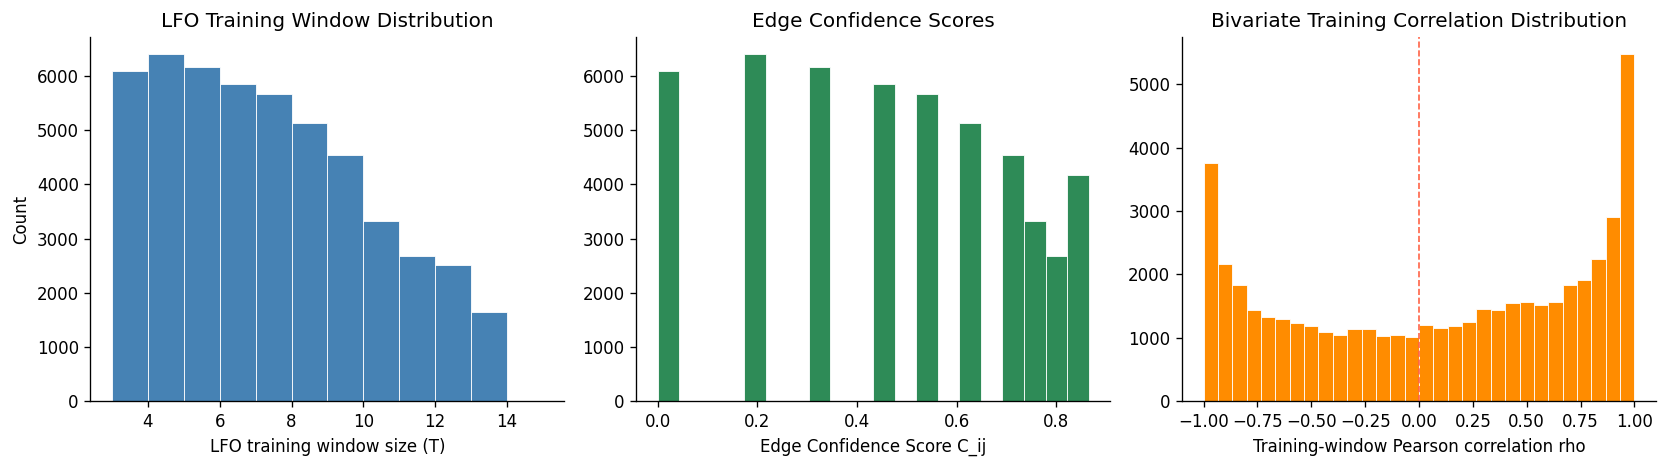

Total LFO entries: 50,038
Mean conf: 0.471
Mean |rho|: 0.611
Pairs with |rho| > 0.7: 46.6%


In [10]:
# ── Reference quality distributions ─────────────────────────────────────────
conf_vals = [v['conf']    for v in lfo_refs.values()]
n_vals    = [v['n_train'] for v in lfo_refs.values()]
rho_vals  = [v['ref']['rho'] for v in lfo_refs.values()]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(n_vals, bins=range(3, 16), edgecolor='white',
             linewidth=0.5, color='steelblue')
axes[0].set_xlabel('LFO training window size (T)')
axes[0].set_ylabel('Count')
axes[0].set_title('LFO Training Window Distribution')

axes[1].hist(conf_vals, bins=20, edgecolor='white',
             linewidth=0.5, color='seagreen')
axes[1].set_xlabel('Edge Confidence Score C_ij')
axes[1].set_title('Edge Confidence Scores')

axes[2].hist(rho_vals, bins=30, edgecolor='white',
             linewidth=0.5, color='darkorange')
axes[2].axvline(0, color='tomato', linestyle='--', linewidth=1)
axes[2].set_xlabel('Training-window Pearson correlation rho')
axes[2].set_title('Bivariate Training Correlation Distribution')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'bsi_confidence_distributions.png'),
            bbox_inches='tight')
plt.show()

print(f"Total LFO entries: {len(lfo_refs):,}")
print(f"Mean conf: {np.mean(conf_vals):.3f}")
print(f"Mean |rho|: {np.mean(np.abs(rho_vals)):.3f}")
print(f"Pairs with |rho| > 0.7: {(np.abs(rho_vals)>0.7).mean():.1%}")

## 5. Synthetic calibration against known ground truth (Table IV, Fig. 1)

Two experiments, independent of the Vancouver data.

**Null calibration.** Draw `n` training observations and one held-out
observation from a common bivariate normal and record exceedance of the naive
`chi^2(2)` and the F-corrected threshold.  Under the null the exceedance rate
should equal `alpha = 0.05`.

**Induced covariance break.** Generate a fourteen-year bivariate series whose
correlation drops from 0.85 to 0 at a fixed change point, and run the LFO
detection exactly as in the main analysis.

No cap is applied here, matching the activation rule of Section 6.

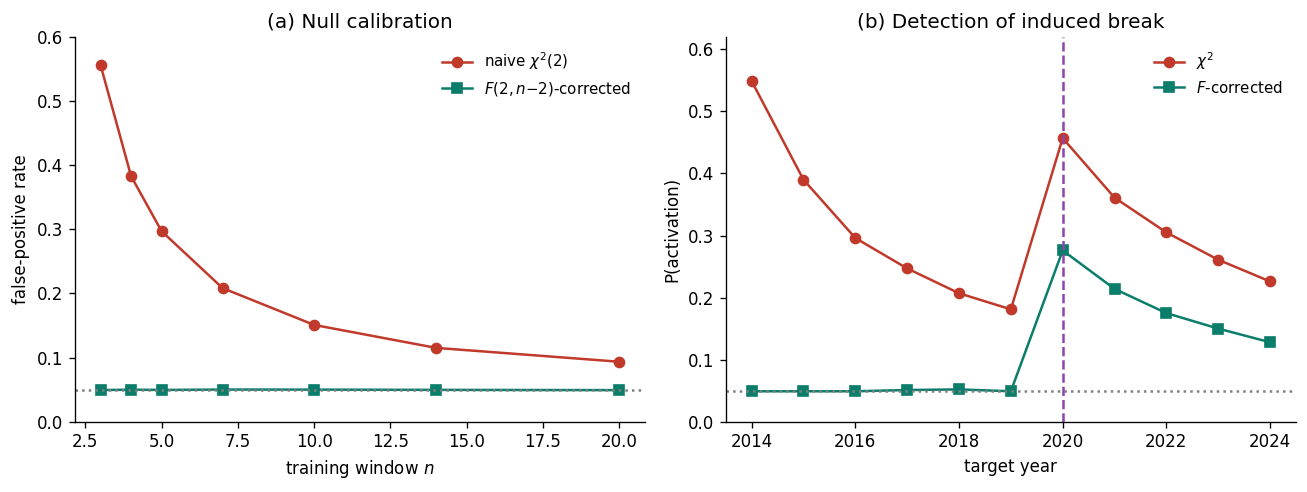

Table-2 threshold check: ALL MATCH
Null FPR (n=3): F = 0.0493 | chi2 = 0.5558
Break iid  pre-break false alarm: F = 0.05 | chi2 = 0.312
Break AR(1) pre-break false alarm: F = 0.06 | chi2 = 0.352
Wrote synthetic_validation_output.json and synthetic_calibration.png


In [11]:
# ============================================================================
# APPENDIX: Synthetic validation of F-corrected activation thresholds
# Self-contained. Reproduces (a) null false-positive calibration and
# (b) detection of a mathematically induced covariance break under LFO.
# Writes synthetic_validation_output.json to share for verification.
# ============================================================================
import numpy as np, json, platform, datetime
import scipy, scipy.stats as _st
import matplotlib.pyplot as plt

# ---- configuration ---------------------------------------------------------
SEED        = 20260630
P           = 2
FPR_NS      = [3, 4, 5, 7, 10, 14, 20]
FPR_TRIALS  = 200_000          # trials per n for null calibration
RHO_NULL    = 0.6              # training correlation in the null world
BREAK_YEARS = np.arange(2011, 2025)
BREAK_AT    = 2020
RHO_PRE     = 0.85             # coupling before the break
RHO_POST    = 0.0             # coupling after the break (decoupling)
BREAK_REPS  = 20_000           # replications for per-year activation prob.
AR_PHI      = 0.35             # AR(1) coefficient for the autocorrelated variant
MIN_WINDOW  = 3

_rng = np.random.default_rng(SEED)

def _const_n(n, p=P):
    """Scale factor in w^2 ~ [p(n+1)(n-1)/(n(n-p))] F(p, n-p)."""
    return p * (n + 1) * (n - 1) / (n * (n - p))

def _F_thr_sq(n, alpha=0.05, p=P):
    """Squared F-corrected activation threshold w*^2."""
    return _const_n(n, p) * _st.f.ppf(1 - alpha, p, n - p)

CHI2_THR_SQ = _st.chi2.ppf(0.95, P)     # naive squared threshold (=5.991)

def _cov(rho):
    return np.array([[1.0, rho], [rho, 1.0]])

# ---- self-check: F thresholds vs manuscript Table 2 ------------------------
_table2 = {3:32.619, 4:8.441, 5:5.529, 7:3.984, 10:3.322, 14:3.003}
threshold_check = {}
for n, ref in _table2.items():
    computed = float(np.sqrt(_F_thr_sq(n)))
    threshold_check[n] = {"manuscript": ref, "computed": round(computed, 3),
                          "match": bool(abs(computed - ref) < 0.01)}

# ---- Experiment A: null false-positive calibration -------------------------
L_null = np.linalg.cholesky(_cov(RHO_NULL))
fpr_table = []
for n in FPR_NS:
    Fq_sq = _F_thr_sq(n)
    eF = eC = 0
    done = 0
    while done < FPR_TRIALS:
        m = min(50_000, FPR_TRIALS - done)
        Z = _rng.standard_normal((m, n + 1, P)) @ L_null.T
        tr, held = Z[:, :n, :], Z[:, n, :]
        mu = tr.mean(axis=1)
        d = tr - mu[:, None, :]
        S = np.einsum('mij,mik->mjk', d, d) / (n - 1)
        diff = held - mu
        d2 = np.einsum('mi,mij,mj->m', diff, np.linalg.inv(S), diff)
        eF += int(np.sum(d2 >= Fq_sq)); eC += int(np.sum(d2 >= CHI2_THR_SQ))
        done += m
    fpr_table.append({"n": n,
                      "w_star_F": round(float(np.sqrt(Fq_sq)), 3),
                      "fpr_F": round(eF / FPR_TRIALS, 4),
                      "fpr_chi2": round(eC / FPR_TRIALS, 4)})

# ---- Experiment B: induced covariance break under LFO ----------------------
_yrs = BREAK_YEARS; _T = len(_yrs); _bidx = int(np.where(_yrs == BREAK_AT)[0][0])
_Lpre, _Lpost = np.linalg.cholesky(_cov(RHO_PRE)), np.linalg.cholesky(_cov(RHO_POST))

def _run_break(ar):
    aF = np.zeros(_T); aC = np.zeros(_T); ne = np.zeros(_T)
    for _ in range(BREAK_REPS):
        X = np.zeros((_T, P)); prev = np.zeros(P)
        for ti in range(_T):
            Lc = _Lpre if ti < _bidx else _Lpost
            e = Lc @ _rng.standard_normal(P)
            if ar:
                X[ti] = AR_PHI * prev + np.sqrt(1 - AR_PHI**2) * e; prev = X[ti]
            else:
                X[ti] = e
        for ti in range(_T):
            tr = X[:ti]
            if tr.shape[0] < MIN_WINDOW: continue
            n = tr.shape[0]; mu = tr.mean(0); S = np.cov(tr.T, ddof=1)
            try: Sinv = np.linalg.inv(S)
            except np.linalg.LinAlgError: continue
            diff = X[ti] - mu; d2 = diff @ Sinv @ diff
            aF[ti] += d2 >= _F_thr_sq(n); aC[ti] += d2 >= CHI2_THR_SQ; ne[ti] += 1
    with np.errstate(invalid='ignore'):
        pF, pC = aF / ne, aC / ne
    rows = [{"year": int(_yrs[ti]), "n_train": ti,
             "p_act_F": round(float(pF[ti]), 3), "p_act_chi2": round(float(pC[ti]), 3)}
            for ti in range(_T) if ne[ti] > 0]
    pre = [ti for ti in range(_T) if ti < _bidx and ne[ti] > 0]
    return {"per_year": rows,
            "pre_break_false_alarm_F": round(float(np.nanmean(pF[pre])), 3),
            "pre_break_false_alarm_chi2": round(float(np.nanmean(pC[pre])), 3)}

break_iid = _run_break(ar=False)
break_ar  = _run_break(ar=True)

# ---- figure ----------------------------------------------------------------
_ns = [r["n"] for r in fpr_table]
_fF = [r["fpr_F"] for r in fpr_table]; _fC = [r["fpr_chi2"] for r in fpr_table]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(_ns, _fC, 'o-', color='#c0392b', label=r'naive $\chi^2(2)$')
ax[0].plot(_ns, _fF, 's-', color='#0a7d6b', label=r'$F(2,n{-}2)$-corrected')
ax[0].axhline(0.05, ls=':', color='gray'); ax[0].set_ylim(0, 0.6)
ax[0].set_xlabel('training window $n$'); ax[0].set_ylabel('false-positive rate')
ax[0].set_title('(a) Null calibration'); ax[0].legend(frameon=False, fontsize=9)
_r = break_iid["per_year"]; _yy = [d["year"] for d in _r]
ax[1].plot(_yy, [d["p_act_chi2"] for d in _r], 'o-', color='#c0392b', label=r'$\chi^2$')
ax[1].plot(_yy, [d["p_act_F"] for d in _r], 's-', color='#0a7d6b', label='$F$-corrected')
ax[1].axhline(0.05, ls=':', color='gray'); ax[1].axvline(BREAK_AT, ls='--', color='#8e44ad')
ax[1].set_xlabel('target year'); ax[1].set_ylabel('P(activation)'); ax[1].set_ylim(0, 0.62)
ax[1].set_title('(b) Detection of induced break'); ax[1].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.savefig('synthetic_calibration.png', dpi=200, bbox_inches='tight')
plt.show()

# ---- write shareable output ------------------------------------------------
output = {
    "metadata": {
        "generated": datetime.datetime.now().isoformat(timespec="seconds"),
        "seed": SEED, "fpr_trials": FPR_TRIALS, "break_reps": BREAK_REPS,
        "rho_null": RHO_NULL, "rho_pre": RHO_PRE, "rho_post": RHO_POST,
        "ar_phi": AR_PHI, "break_year": BREAK_AT,
        "numpy": np.__version__, "scipy": scipy.__version__,
        "python": platform.python_version(),
    },
    "threshold_check_vs_table2": threshold_check,
    "experiment_A_null_fpr": fpr_table,
    "experiment_B_break_iid": break_iid,
    "experiment_B_break_ar1": break_ar,
}
with open("synthetic_validation_output.json", "w") as f:
    json.dump(output, f, indent=2)

print("Table-2 threshold check:",
      "ALL MATCH" if all(v["match"] for v in threshold_check.values()) else "MISMATCH")
print("Null FPR (n=3): F =", fpr_table[0]["fpr_F"], "| chi2 =", fpr_table[0]["fpr_chi2"])
print("Break iid  pre-break false alarm: F =", break_iid["pre_break_false_alarm_F"],
      "| chi2 =", break_iid["pre_break_false_alarm_chi2"])
print("Break AR(1) pre-break false alarm: F =", break_ar["pre_break_false_alarm_F"],
      "| chi2 =", break_ar["pre_break_false_alarm_chi2"])
print("Wrote synthetic_validation_output.json and synthetic_calibration.png")

## 6. Parenclitic edge construction (Eq. 5)

Two weight dictionaries are maintained and they are not interchangeable:

- `edges_raw` — uncapped `w_ij(t)`, used for **activation** and for the
  permutation null.  This is the quantity whose square follows Eq. (3).
- `edges_t` — the same weights capped at `MAHAL_CAP`, used only in the
  **aggregation** layer, where a single extreme pair would otherwise dominate a
  confidence-weighted mean.

`is_activated()` reads `edges_raw`.  The diagnostic below reports how many
activations a pre-threshold cap would suppress; all of them sit at `n_train = 3`,
where the threshold (32.619) exceeds the cap.

In [12]:
print("Computing Mahalanobis edge weights (undirected, LFO) ...")

# edges_t[(uid_i, uid_j)]   = {year: CAPPED weight}   -> aggregation layer
# edges_raw[(uid_i, uid_j)] = {year: UNCAPPED weight} -> activation decisions
# uid_i < uid_j (unordered pairs, same ordering as lfo_refs)
edges_t   = {}
edges_raw = {}

for (uid_i, uid_j, t_year), entry in lfo_refs.items():
    xi_t = num_matrix.loc[uid_i, t_year]
    xj_t = num_matrix.loc[uid_j, t_year]
    if pd.isna(xi_t) or pd.isna(xj_t):
        continue
    w_raw = mahal_weight_raw(float(xi_t), float(xj_t), entry['ref'])
    w     = min(w_raw, MAHAL_CAP)
    pair  = (uid_i, uid_j)
    edges_t.setdefault(pair, {})[t_year]   = w
    edges_raw.setdefault(pair, {})[t_year] = w_raw

print(f"Unique undirected pairs: {len(edges_t):,}")
print(f"Edge-year entries:       {sum(len(v) for v in edges_t.values()):,}")

# eligible_per_year[y] = number of pairs with a valid weight at year y
# (denominator for NAD at any threshold)
eligible_per_year = {}
for y in year_int_cols:
    eligible_per_year[y] = sum(1 for yw in edges_t.values() if y in yw)
print(f"Eligible pairs per year: min={min(eligible_per_year.values())} "
      f"max={max(eligible_per_year.values())}")

# Convenience: per-pair per-year activation uses F-corrected threshold from lfo_refs
def is_activated(uid_i, uid_j, t_year, level='activation'):
    """
    Return True iff the UNCAPPED Mahalanobis weight exceeds the F-corrected
    threshold for the training window size recorded in lfo_refs.
    level: 'activation' (alpha=0.05) or 'alert' (alpha=0.01)
    """
    key  = (uid_i, uid_j, t_year)
    if key not in lfo_refs: return False
    src_dict = edges_t if CAP_APPLIES_TO_ACTIVATION else edges_raw
    w    = src_dict.get((uid_i, uid_j), {}).get(t_year, np.nan)
    if np.isnan(w): return False
    thr_key = 'thr_act' if level == 'activation' else 'thr_ale'
    return w >= lfo_refs[key][thr_key]

print("\nis_activated() helper defined (uncapped w vs F-corrected per-pair thresholds).")

# ── Diagnostic: activations that a pre-threshold cap would suppress ─────────
# Only n_train = 3 is affected (activation thr 32.619 > 20; alert thr 163.291).
cap_suppressed = {'activation': {}, 'alert': {}}
n3_entries = 0
for (uid_i, uid_j, t_year), entry in lfo_refs.items():
    if entry['n_train'] != 3:
        continue
    n3_entries += 1
    w_raw = edges_raw.get((uid_i, uid_j), {}).get(t_year, np.nan)
    if np.isnan(w_raw):
        continue
    for lvl, tk in (('activation', 'thr_act'), ('alert', 'thr_ale')):
        if entry[tk] > MAHAL_CAP and w_raw >= entry[tk]:
            cap_suppressed[lvl][t_year] = cap_suppressed[lvl].get(t_year, 0) + 1

print(f"\nCap diagnostic (n_train = 3 pair-years: {n3_entries:,}):")
print(f"  thresholds exceeding MAHAL_CAP={MAHAL_CAP}: "
      f"activation {threshold_table[3]['activation']:.3f}, "
      f"alert {threshold_table[3]['alert']:.3f}")
print(f"  activations recovered by uncapping, by year: "
      f"{dict(sorted(cap_suppressed['activation'].items())) or 'none'}")
print(f"  alerts recovered by uncapping, by year:      "
      f"{dict(sorted(cap_suppressed['alert'].items())) or 'none'}")
print("  (these activations are unreachable if the cap is applied first)")

Computing Mahalanobis edge weights (undirected, LFO) ...
Unique undirected pairs: 9,396
Edge-year entries:       50,038
Eligible pairs per year: min=0 max=6997

is_activated() helper defined (uncapped w vs F-corrected per-pair thresholds).

Cap diagnostic (n_train = 3 pair-years: 6,089):
  thresholds exceeding MAHAL_CAP=20.0: activation 32.619, alert 163.291
  activations recovered by uncapping, by year: {2014: 83, 2015: 12, 2016: 15, 2017: 28, 2018: 40, 2019: 25, 2020: 164, 2021: 14, 2022: 17, 2023: 89, 2024: 19}
  alerts recovered by uncapping, by year:      {2014: 14, 2015: 1, 2016: 5, 2017: 9, 2018: 8, 2019: 2, 2020: 31, 2021: 2, 2022: 5, 2023: 15}
  (these activations are unreachable if the cap is applied first)


In [13]:
snapshot_graphs = {}
uid_to_indicator = dict(zip(work['uid'], work['indicator']))
uid_to_domain    = dict(zip(work['uid'], work['domain']))
ind_to_domain    = dict(zip(work['indicator'], work['domain']))

for y in year_int_cols:
    G = nx.Graph()
    for _, row in work.iterrows():
        G.add_node(row['uid'], indicator=row['indicator'],
                   domain=row['domain'], tier=row['tier'])
    for (uid_i, uid_j), yw in edges_t.items():
        if y not in yw: continue
        w = yw[y]
        # Per-pair F-corrected activation threshold
        if is_activated(uid_i, uid_j, y, level='activation'):
            key  = (uid_i, uid_j, y)
            conf = lfo_refs[key]['conf'] if key in lfo_refs else 0.0
            alert_flag = is_activated(uid_i, uid_j, y, level='alert')
            G.add_edge(uid_i, uid_j, weight=w, conf=conf, alert=alert_flag)
    snapshot_graphs[y] = G

print("Undirected snapshot graphs (F-corrected activation thresholds):")
for y, G in sorted(snapshot_graphs.items()):
    print(f"  {y}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Undirected snapshot graphs (F-corrected activation thresholds):
  2011: 174 nodes, 0 edges
  2012: 174 nodes, 0 edges
  2013: 174 nodes, 0 edges
  2014: 174 nodes, 83 edges
  2015: 174 nodes, 148 edges
  2016: 174 nodes, 421 edges
  2017: 174 nodes, 577 edges
  2018: 174 nodes, 786 edges
  2019: 174 nodes, 682 edges
  2020: 174 nodes, 1738 edges
  2021: 174 nodes, 1686 edges
  2022: 174 nodes, 1230 edges
  2023: 174 nodes, 1552 edges
  2024: 174 nodes, 535 edges


## 7. Hierarchical aggregation (Eq. 6)

Confidence-weighted indicator anomaly scores `A_k(t)`, then coverage-weighted
domain scores `D_d(t)`.  The aggregation is bidirectional: sub-indicator
anomalies propagate upward, and an anomalous domain can be traced back down to
the sub-indicators driving it.

In [14]:
def indicator_anomaly(indicator_name, year):
    # edges_t uses unordered pairs (uid_i < uid_j)
    total_w = total_c = 0.0
    for (uid_i, uid_j), yw in edges_t.items():
        if year not in yw: continue
        if (uid_to_indicator.get(uid_i) != indicator_name and
                uid_to_indicator.get(uid_j) != indicator_name):
            continue
        key = (uid_i, uid_j, year)
        c   = lfo_refs[key]['conf'] if key in lfo_refs else 0.0
        total_w += c * yw[year]
        total_c += c
    return total_w / total_c if total_c > 0 else 0.0

indicators_list = sorted(work['indicator'].unique())
ind_anomaly     = {ind: {y: indicator_anomaly(ind, y) for y in year_int_cols}
                   for ind in indicators_list}
ind_anomaly_df  = pd.DataFrame(ind_anomaly).T
print(f"Indicator anomaly scores: {ind_anomaly_df.shape}")

Indicator anomaly scores: (39, 14)


In [15]:
ind_coverage_weight = {}
for ind in indicators_list:
    sub_df  = values_df[values_df['indicator'] == ind]
    total   = len(sub_df)
    working = (sub_df['tier'] <= 2).sum()
    ind_coverage_weight[ind] = working / total if total > 0 else 0.0

domains_list = sorted(set(ind_to_domain.values()))
dom_anomaly  = {}
for dom in domains_list:
    dom_inds = [i for i in indicators_list if ind_to_domain.get(i) == dom]
    dom_anomaly[dom] = {}
    for y in year_int_cols:
        ws = sum(ind_coverage_weight[i] * ind_anomaly[i].get(y, 0.0)
                 for i in dom_inds)
        tw = sum(ind_coverage_weight[i] for i in dom_inds)
        dom_anomaly[dom][y] = ws / tw if tw > 0 else 0.0

dom_anomaly_df = pd.DataFrame(dom_anomaly).T
print("Domain anomaly scores:")
print(dom_anomaly_df.round(3).to_string())

Domain anomaly scores:
                         2011  2012  2013  2014   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024
Critical Infrastructure   0.0   0.0   0.0   0.0  2.345  5.007  2.408  3.171  2.849  3.373  2.724  3.740  3.482  2.563
Economics                 0.0   0.0   0.0   0.0  2.412  2.481  2.257  2.205  2.361  4.306  3.578  2.862  2.776  1.827
Environment               0.0   0.0   0.0   0.0  2.833  3.462  3.848  3.101  2.795  3.166  3.678  2.460  2.940  2.440
Health & Well-being       0.0   0.0   0.0   0.0  3.695  2.402  2.604  3.513  2.108  3.025  2.296  2.573  2.789  2.086
Institutional             0.0   0.0   0.0   0.0  3.370  3.510  3.050  3.245  3.020  3.922  4.616  2.564  2.901  2.809
Leadership & Strategy     0.0   0.0   0.0   0.0  1.012  1.360  3.241  2.715  2.778  2.530  3.281  2.523  2.571  2.602
Social & Demographics     0.0   0.0   0.0   0.0  2.324  4.199  2.684  2.330  1.970  2.208  2.903  2.685  1.974  1.836


In [16]:
# Domain anomaly scores as a (domains x years) frame, used by the figures,
# the monitor-versus-forecaster analysis, and the consolidated export.
dom_anomaly_df = pd.DataFrame(dom_anomaly).T
print(f"dom_anomaly_df: {dom_anomaly_df.shape[0]} domains x "
      f"{dom_anomaly_df.shape[1]} years")
print(dom_anomaly_df.round(3).to_string())

dom_anomaly_df: 7 domains x 14 years
                         2011  2012  2013  2014   2015   2016   2017   2018   2019   2020   2021   2022   2023   2024
Critical Infrastructure   0.0   0.0   0.0   0.0  2.345  5.007  2.408  3.171  2.849  3.373  2.724  3.740  3.482  2.563
Economics                 0.0   0.0   0.0   0.0  2.412  2.481  2.257  2.205  2.361  4.306  3.578  2.862  2.776  1.827
Environment               0.0   0.0   0.0   0.0  2.833  3.462  3.848  3.101  2.795  3.166  3.678  2.460  2.940  2.440
Health & Well-being       0.0   0.0   0.0   0.0  3.695  2.402  2.604  3.513  2.108  3.025  2.296  2.573  2.789  2.086
Institutional             0.0   0.0   0.0   0.0  3.370  3.510  3.050  3.245  3.020  3.922  4.616  2.564  2.901  2.809
Leadership & Strategy     0.0   0.0   0.0   0.0  1.012  1.360  3.241  2.715  2.778  2.530  3.281  2.523  2.571  2.602
Social & Demographics     0.0   0.0   0.0   0.0  2.324  4.199  2.684  2.330  1.970  2.208  2.903  2.685  1.974  1.836


## 8. Network anomaly density and permutation null (Eq. 8)

`NAD(t)` is the fraction of eligible pairs whose uncapped weight exceeds the
per-pair F-corrected threshold.

The null is a circular-block permutation (`N = 500`): each sub-indicator's
observed series is rotated by a random offset, preserving its within-series
autocorrelation and trend while breaking cross-indicator phase alignment.
Weights are re-evaluated against the **original** LFO references.
`NAD*(t) = NAD(t) - mean(NAD_0(t))`, with a 95% interval at
`+/- 1.96 * sd(NAD_0(t))`.

Two robustness variants are also computed: confidence-weighted NAD (CW-NAD) and
coverage-stable NAD, restricted to pairs observed across the full LFO-active
window.

For short series the rotation admits only `T_i - 1` distinct offsets, so early
LFO years carry fewer than 500 independent draws; the cell reports the shift
resolution explicitly.

In [17]:
# ── Permutation null for NAD: circular-block permutation (Section IV G) ─────
#
print("Computing permutation null NAD — BLOCK (circular) permutation (N_PERM=500) ...")
print("  Method: per-indicator circular rotation (preserves within-series autocorr)")
N_PERM = 500
rng    = np.random.default_rng(seed=42)
null_nad_dist = {y: [] for y in year_int_cols}

uids_order  = list(num_matrix.index)
data_arr    = num_matrix.reindex(uids_order)[year_int_cols].values.copy()
year_to_idx = {y: i for i, y in enumerate(year_int_cols)}

# ── Diagnostic: mean lag-1 autocorrelation across sub-indicators ──────────
ac_pool = []
for row_i in range(len(uids_order)):
    s = pd.Series(data_arr[row_i]).dropna()
    if len(s) >= 4:
        ac = float(s.autocorr(lag=1))
        if not np.isnan(ac):
            ac_pool.append(ac)
mean_ac = float(np.nanmean(ac_pool)) if ac_pool else 0.0
print(f"  Mean lag-1 autocorrelation across sub-indicators: {mean_ac:.3f}")
print( "  (an independent-shuffle null would be anti-conservative at this level)")
# ── Diagnostic: available circular shifts per sub-indicator ──────────────────
n_shifts_pool = []
for row_i in range(len(uids_order)):
    obs = np.sum(~np.isnan(data_arr[row_i]))
    n_shifts_pool.append(int(obs - 1) if obs > 1 else 0)
n_shifts_arr = np.array(n_shifts_pool)
print(f"  Circular shift resolution (unique permutations per sub-indicator):")
for thr in [3, 5, 7, 10]:
    frac = (n_shifts_arr < thr).mean()
    print(f"    < {thr} unique shifts: {frac:.1%} of sub-indicators")
print(f"  Median unique shifts: {np.median(n_shifts_arr):.0f}")
print(f"  Min unique shifts: {n_shifts_arr.min()}")
print("  Note: N_PERM=500 with few unique shifts means many duplicate permutations.")
print("  Early LFO years (T_i=3-5) are most affected; NAD* estimates there")
print("  have effectively fewer than 500 independent draws.")
print()


# ── Compute actual NAD from real data ────────────────────────────────────────
# when the permutation null block was rewritten.
nad_actual = {}
cw_nad_actual = {}
for y in year_int_cols:
    active_r = 0; eligible_r = 0
    cw_active = 0.0; cw_eligible = 0.0
    for (uid_i, uid_j, t_year), entry in lfo_refs.items():
        if t_year != y: continue
        a_idx = uids_order.index(uid_i) if uid_i in uids_order else -1
        b_idx = uids_order.index(uid_j) if uid_j in uids_order else -1
        if a_idx < 0 or b_idx < 0: continue
        xi = data_arr[a_idx, year_to_idx[y]]
        xj = data_arr[b_idx, year_to_idx[y]]
        if np.isnan(xi) or np.isnan(xj): continue
        eligible_r += 1
        conf = entry['conf']          # C_ij(t), Eq. (2)
        cw_eligible += conf
        w = activation_weight(float(xi), float(xj), entry['ref'])
        if w >= entry['thr_act']:
            active_r += 1
            cw_active += conf
    nad_actual[y] = active_r / eligible_r if eligible_r > 0 else 0.0
    cw_nad_actual[y] = cw_active / cw_eligible if cw_eligible > 0 else 0.0

nad_df    = pd.Series(nad_actual,    name='NAD')
cw_nad_df = pd.Series(cw_nad_actual, name='CW_NAD')
print(f"NAD computed:    {nad_df.dropna().round(4).to_dict()}")
print(f"CW-NAD computed: {cw_nad_df.dropna().round(4).to_dict()}")
_cwdiff = float((nad_df - cw_nad_df).abs().max())
print(f"max |NAD - CW-NAD| = {_cwdiff:.6f}"
      + ("   <-- WARNING: confidence weighting not applied"
         if _cwdiff < 1e-12 else ""))

# ── Coverage-stable NAD: restrict to pairs observed across full LFO window ───
# A pair is "stable" if it has an LFO entry for every year in year_int_cols.
stable_pairs = set()
pair_years = {}
for (uid_i, uid_j, t_year) in lfo_refs:
    key = (min(uid_i, uid_j), max(uid_i, uid_j))
    pair_years.setdefault(key, set()).add(t_year)
full_lfo_years = set(y for y in year_int_cols
                     if any(t == y for (_, _, t) in lfo_refs))
for key, yrs in pair_years.items():
    if full_lfo_years.issubset(yrs):
        stable_pairs.add(key)

nad_stable_actual = {}
for y in year_int_cols:
    active_s = 0; eligible_s = 0
    for (uid_i, uid_j, t_year), entry in lfo_refs.items():
        if t_year != y: continue
        key = (min(uid_i, uid_j), max(uid_i, uid_j))
        if key not in stable_pairs: continue
        a_idx = uids_order.index(uid_i) if uid_i in uids_order else -1
        b_idx = uids_order.index(uid_j) if uid_j in uids_order else -1
        if a_idx < 0 or b_idx < 0: continue
        xi = data_arr[a_idx, year_to_idx[y]]
        xj = data_arr[b_idx, year_to_idx[y]]
        if np.isnan(xi) or np.isnan(xj): continue
        eligible_s += 1
        w = activation_weight(float(xi), float(xj), entry['ref'])
        if w >= entry['thr_act']:
            active_s += 1
    nad_stable_actual[y] = active_s / eligible_s if eligible_s > 0 else 0.0

nad_stable_df = pd.Series(nad_stable_actual, name='NAD_stable')
print(f"Coverage-stable pairs: {len(stable_pairs)}")
print(f"NAD stable: {nad_stable_df.dropna().round(4).to_dict()}")

for perm_idx in range(N_PERM):
    perm_arr = data_arr.copy()
    for row_i in range(len(uids_order)):
        # Find observed (non-NaN) indices
        observed_mask = ~np.isnan(data_arr[row_i])
        obs_indices   = np.where(observed_mask)[0]
        if len(obs_indices) > 1:
            # Circular rotation: shift by a random integer offset
            shift = int(rng.integers(1, len(obs_indices)))
            perm_arr[row_i, obs_indices] = np.roll(
                data_arr[row_i, obs_indices], shift)

    for y in year_int_cols:
        active_p   = 0
        eligible_p = 0
        for (uid_i, uid_j, t_year), entry in lfo_refs.items():
            if t_year != y: continue
            a_idx = uids_order.index(uid_i) if uid_i in uids_order else -1
            b_idx = uids_order.index(uid_j) if uid_j in uids_order else -1
            if a_idx < 0 or b_idx < 0: continue
            xi_p = perm_arr[a_idx, year_to_idx[y]]
            xj_p = perm_arr[b_idx, year_to_idx[y]]
            if np.isnan(xi_p) or np.isnan(xj_p): continue
            eligible_p += 1
            w_p = activation_weight(float(xi_p), float(xj_p), entry['ref'])
            if w_p >= entry['thr_act']:
                active_p += 1
        null_nad_dist[y].append(active_p / eligible_p if eligible_p > 0 else 0.0)

null_nad_mean = pd.Series({y: np.mean(v) for y, v in null_nad_dist.items()},
                           name='NAD_null_mean')
null_nad_p95  = pd.Series({y: np.percentile(v, 95) for y, v in null_nad_dist.items()},
                           name='NAD_null_p95')
# NEW: also store SD of null for CI on NAD*
null_nad_sd   = pd.Series({y: np.std(v, ddof=1) for y, v in null_nad_dist.items()},
                           name='NAD_null_sd')
nad_corrected = (nad_df - null_nad_mean).rename('NAD_corrected')

# 95% CI on NAD*: NAD_observed +/- 1.96 * null_sd
nad_star_lo = (nad_corrected - 1.96 * null_nad_sd).rename('NAD_star_lo')
nad_star_hi = (nad_corrected + 1.96 * null_nad_sd).rename('NAD_star_hi')

print("Block-permutation null NAD computed.")
print(f"  Null mean (year range): {null_nad_mean.min():.4f} – {null_nad_mean.max():.4f}")
print(f"  Null p95  (year range): {null_nad_p95.min():.4f} – {null_nad_p95.max():.4f}")
print()
print("Raw NAD (F-corrected):"); print(nad_df.round(4).to_string())
print(f"\nPeak year: {nad_df.idxmax()} ({nad_df.max():.4f})")
print(f"\nBaseline-corrected NAD* (peak year = "
      f"{nad_corrected.idxmax()}, val = {nad_corrected.max():.4f}):")
print(nad_corrected.round(4).to_string())
print("\nNAD* 95% CI:")
print(pd.concat([nad_star_lo, nad_corrected, nad_star_hi], axis=1).round(4).to_string())
print("\nYears with NAD* CI strictly > 0 (genuine anomaly above null):")
genuine = [y for y in nad_corrected.index if nad_star_lo.get(y, np.nan) > 0]
print(genuine)

Computing permutation null NAD — BLOCK (circular) permutation (N_PERM=500) ...
  Method: per-indicator circular rotation (preserves within-series autocorr)
  Mean lag-1 autocorrelation across sub-indicators: 0.592
  (an independent-shuffle null would be anti-conservative at this level)
  Circular shift resolution (unique permutations per sub-indicator):
    < 3 unique shifts: 9.8% of sub-indicators
    < 5 unique shifts: 21.8% of sub-indicators
    < 7 unique shifts: 28.2% of sub-indicators
    < 10 unique shifts: 48.9% of sub-indicators
  Median unique shifts: 10
  Min unique shifts: 2
  Note: N_PERM=500 with few unique shifts means many duplicate permutations.
  Early LFO years (T_i=3-5) are most affected; NAD* estimates there
  have effectively fewer than 500 independent draws.

NAD computed:    {2011: 0.0, 2012: 0.0, 2013: 0.0, 2014: 0.0678, 2015: 0.0699, 2016: 0.1494, 2017: 0.1728, 2018: 0.1726, 2019: 0.1381, 2020: 0.301, 2021: 0.2536, 2022: 0.179, 2023: 0.2218, 2024: 0.1125}
CW-N

In [18]:
# Dict form of NAD for year-keyed lookups in the scenario figures.
nad_series = nad_df.to_dict()

## 9. Domain Coupling Index (Eq. 7)

Pearson correlation between domain anomaly series at lags 0, 1 and 2, with
Fisher-z confidence intervals on a Bartlett effective sample size
`n_eff = n(1 - r1*r2)/(1 + r1*r2)`, and Benjamini–Hochberg control across the 21
unique domain pairs at each lag.  Note that `n_eff` exceeds `n` when the two
lag-1 autocorrelations have opposite sign.

In [19]:
# ── Domain Coupling Index: Pearson r with autocorrelation-corrected
#    Fisher z confidence intervals and BH-FDR control (Section IV F).
from scipy.stats import norm
from scipy.stats import t as t_dist

def pearson_ci_fisher(r, n, alpha=0.05, s1=None, s2=None):
    """
    95% CI and two-sided p-value via Fisher z-transform with Bartlett n_eff
    correction for autocorrelated series.

    Returns (lo, hi, n_eff, p_value).
    """
    if n <= 3:
        return (np.nan, np.nan, n, 1.0)
    if s1 is not None and s2 is not None:
        try:
            ac1 = float(pd.Series(s1).autocorr(lag=1))
            ac2 = float(pd.Series(s2).autocorr(lag=1))
            if np.isnan(ac1): ac1 = 0.0
            if np.isnan(ac2): ac2 = 0.0
            denom = 1.0 + ac1 * ac2
            n_eff = max(4, int(n * (1.0 - ac1 * ac2) / denom)) if denom > 0 else n
        except Exception:
            n_eff = n
    else:
        n_eff = n
    if n_eff <= 3:
        return (np.nan, np.nan, n_eff, 1.0)
    z      = np.arctanh(np.clip(r, -0.9999, 0.9999))
    se     = 1.0 / np.sqrt(n_eff - 3)
    z_c = norm.ppf(1.0 - alpha/2)
    lo     = float(np.tanh(z - z_c * se))
    hi     = float(np.tanh(z + z_c * se))
    z_stat = z * np.sqrt(n_eff - 3)
    from scipy.stats import norm as _norm
    p_val  = float(2 * (1 - _norm.cdf(abs(z_stat))))
    return (lo, hi, n_eff, p_val)

def dci_at_lag(lag=0):
    """
    Compute Pearson correlation between domain anomaly time series at a lag.
    Returns DCI, CI lower, CI upper, nominal n, n_eff, and p-value matrices.
    Uses Bartlett n_eff and applies BH FDR correction across all unique pairs.
    """
    years   = sorted(year_int_cols)
    dci     = pd.DataFrame(np.nan, index=domains_list, columns=domains_list)
    dci_lo  = dci.copy(); dci_hi = dci.copy()
    dci_n   = pd.DataFrame(0, index=domains_list, columns=domains_list)
    dci_neff= pd.DataFrame(0, index=domains_list, columns=domains_list)
    dci_p   = pd.DataFrame(1.0, index=domains_list, columns=domains_list)
    dci_bh  = pd.DataFrame(False, index=domains_list, columns=domains_list)

    pairs_data = []  # for BH correction
    for d1 in domains_list:
        for d2 in domains_list:
            s1 = np.array([dom_anomaly[d1].get(y, np.nan) for y in years],
                           dtype=float)
            s2 = np.array([dom_anomaly[d2].get(y, np.nan) for y in years],
                           dtype=float)
            if lag > 0:
                s1 = s1[:len(s1)-lag]; s2 = s2[lag:]
            mask = np.isfinite(s1) & np.isfinite(s2) & (s1 > 0) & (s2 > 0)
            s1c = s1[mask]; s2c = s2[mask]
            if len(s1c) >= 3:
                r, _  = pearsonr(s1c, s2c)
                lo, hi, n_eff, p = pearson_ci_fisher(r, len(s1c), s1=s1c, s2=s2c)
                dci.loc[d1, d2]    = r
                dci_lo.loc[d1, d2] = lo
                dci_hi.loc[d1, d2] = hi
                dci_n.loc[d1, d2]  = len(s1c)
                dci_neff.loc[d1, d2] = n_eff
                dci_p.loc[d1, d2]  = p
                # Collect upper-triangle unique pairs for BH
                if lag == 0 and domains_list.index(d1) < domains_list.index(d2):
                    pairs_data.append((d1, d2, p))
                elif lag > 0:  # directed pairs: all (d1 != d2)
                    if d1 != d2:
                        pairs_data.append((d1, d2, p))

    # BH correction
    if pairs_data:
        m = len(pairs_data)
        sorted_pairs = sorted(pairs_data, key=lambda x: x[2])
        bh_thresholds = [(k+1)/m * 0.05 for k in range(m)]
        for k, (d1, d2, p) in enumerate(sorted_pairs):
            if p <= bh_thresholds[k]:
                dci_bh.loc[d1, d2] = True
                if lag == 0:
                    dci_bh.loc[d2, d1] = True  # symmetric for lag 0

    return dci, dci_lo, dci_hi, dci_n, dci_neff, dci_p, dci_bh

dci_df,   dci_lo_0, dci_hi_0, dci_n_0, dci_neff_0, dci_p_0, dci_bh_0 = dci_at_lag(0)
dci_lag1, dci_lo_1, dci_hi_1, dci_n_1, dci_neff_1, dci_p_1, dci_bh_1 = dci_at_lag(1)
dci_lag2, dci_lo_2, dci_hi_2, dci_n_2, dci_neff_2, dci_p_2, dci_bh_2 = dci_at_lag(2)

print("\nDCI lag-0 — n_eff CIs, p-values, BH significance (21 unique pairs):")
for d1 in domains_list:
    for d2 in domains_list:
        if domains_list.index(d1) >= domains_list.index(d2): continue
        r   = dci_df.loc[d1, d2]
        lo  = dci_lo_0.loc[d1, d2]; hi = dci_hi_0.loc[d1, d2]
        ne  = dci_neff_0.loc[d1, d2]; p = dci_p_0.loc[d1, d2]
        bh  = dci_bh_0.loc[d1, d2]
        if not np.isnan(r) and abs(r) > 0.4:
            print(f"  {d1[:20]:20s} × {d2[:20]:20s}: r={r:.3f} "
                  f"[{lo:.3f},{hi:.3f}] n_eff={ne} p={p:.4f} {'BH-SIG' if bh else ''}")

print("\nDCI lag-1 — BH-significant directed pairs:")
bh1_found = False
for d1 in domains_list:
    for d2 in domains_list:
        if d1 == d2: continue
        if dci_bh_1.loc[d1, d2]:
            r = dci_lag1.loc[d1, d2]; lo = dci_lo_1.loc[d1, d2]
            hi = dci_hi_1.loc[d1, d2]; ne = dci_neff_1.loc[d1, d2]
            p  = dci_p_1.loc[d1, d2]
            print(f"  {d1} → {d2}: r={r:.3f} [{lo:.3f},{hi:.3f}] n_eff={ne} p={p:.4f}")
            bh1_found = True
if not bh1_found:
    print("  None survive BH correction at FDR=5%")

print("\nDCI lag-0 — n_eff vs n_nominal (autocorrelation correction):")
for d1 in domains_list:
    for d2 in domains_list:
        n   = dci_n_0.loc[d1, d2]
        ne  = dci_neff_0.loc[d1, d2]
        r   = dci_df.loc[d1, d2]
        lo  = dci_lo_0.loc[d1, d2]
        hi  = dci_hi_0.loc[d1, d2]
        if not np.isnan(r) and abs(r) > 0.5:
            lo_s = f"{lo:.3f}" if not np.isnan(lo) else "n/a"
            hi_s = f"{hi:.3f}" if not np.isnan(hi) else "n/a"
            print(f"  {d1[:22]:22s} x {d2[:22]:22s}: r={r:.3f} [{lo_s}, {hi_s}]"
                  f"  n={n}  n_eff={ne}  {'CI_excludes_0' if not np.isnan(lo) and (lo>0 or hi<0) else 'CI_includes_0'}")

print("\nDCI lag-0 with 95% CI [lo, r, hi] and n:")
for d1 in domains_list:
    for d2 in domains_list:
        r  = dci_df.loc[d1, d2]
        lo = dci_lo_0.loc[d1, d2]
        hi = dci_hi_0.loc[d1, d2]
        n  = dci_n_0.loc[d1, d2]
        if not np.isnan(r) and abs(r) > 0.5:
            lo_s = f"{lo:.3f}" if not np.isnan(lo) else "n/a"
            hi_s = f"{hi:.3f}" if not np.isnan(hi) else "n/a"
            print(f"  {d1[:25]:25s} x {d2[:25]:25s}: "
                  f"r={r:.3f} [{lo_s}, {hi_s}]  n={n}")


DCI lag-0 — n_eff CIs, p-values, BH significance (21 unique pairs):
  Critical Infrastruct × Social & Demographic: r=0.686 [0.147,0.911] n_eff=11 p=0.0174 
  Economics            × Institutional       : r=0.656 [-0.015,0.919] n_eff=9 p=0.0544 
  Environment          × Institutional       : r=0.625 [-0.067,0.911] n_eff=9 p=0.0726 
  Environment          × Social & Demographic: r=0.535 [-0.201,0.885] n_eff=9 p=0.1439 
  Health & Well-being  × Leadership & Strateg: r=-0.429 [-0.782,0.132] n_eff=14 p=0.1283 

DCI lag-1 — BH-significant directed pairs:
  None survive BH correction at FDR=5%

DCI lag-0 — n_eff vs n_nominal (autocorrelation correction):
  Critical Infrastructur x Critical Infrastructur: r=1.000 [0.995, 1.000]  n=10  n_eff=4  CI_excludes_0
  Critical Infrastructur x Social & Demographics : r=0.686 [0.147, 0.911]  n=10  n_eff=11  CI_excludes_0
  Economics              x Economics             : r=1.000 [0.999, 1.000]  n=10  n_eff=7  CI_excludes_0
  Economics              x Inst

## 10. Early warning signal statistics

Node-level anomaly series, then two critical-slowing-down statistics (mean lag-1
autocorrelation, mean absolute pairwise correlation length) combined into
`EWS_CSD` under expanding-window z-score normalisation, which eliminates
look-ahead bias.  Years with fewer than three points in the expanding window are
left undefined.

The Anomaly Heterogeneity Index (`AHI`), the cross-sectional variance of node
anomaly scores, is reported separately and is **not** a critical-slowing-down
statistic.

In [20]:
node_anomaly_ts = {}
for uid in work['uid'].unique():
    node_anomaly_ts[uid] = {}
    for y in year_int_cols:
        weights = []; confs = []
        for (uid_i, uid_j), yw in edges_t.items():
            if y not in yw: continue
            if uid_i != uid and uid_j != uid: continue
            key = (uid_i, uid_j, y)  # uid_i < uid_j in unordered pairs
            c   = lfo_refs[key]['conf'] if key in lfo_refs else 0.0
            weights.append(yw[y]); confs.append(c)
        if not weights:
            node_anomaly_ts[uid][y] = 0.0
        elif sum(confs) > 0:
            # confidence-weighted mean
            node_anomaly_ts[uid][y] = (sum(c*w for c,w in zip(confs,weights)) /
                                        sum(confs))
        else:
            # all conf==0 (early LFO window, n_train=3) -> plain mean
            node_anomaly_ts[uid][y] = float(np.mean(weights))

node_anomaly_ts_df = pd.DataFrame(node_anomaly_ts).T
print(f"Node anomaly time series: {node_anomaly_ts_df.shape}")

Node anomaly time series: (174, 14)


In [21]:
uids_list     = list(node_anomaly_ts.keys())
ahi_series    = {}   # Anomaly Heterogeneity Index (cross-sectional variance)
ews_autocorr  = {}   # Lag-1 autocorrelation (critical slowing down)
ews_corr_len  = {}   # Correlation length (synchronisation)

for t_idx, t_year in enumerate(year_int_cols):

    # ── AHI: cross-sectional variance of node anomaly scores at year t ──────
    # NOTE: this is NOT the Scheffer (2009) critical slowing down statistic.
    # It measures *dispersion* of the system stress footprint across nodes at
    # a single time point. Retained as a complementary measure under the name
    # Anomaly Heterogeneity Index (AHI) to avoid conflation with EWS theory.
    scores_t = np.array([node_anomaly_ts[u].get(t_year, 0.0) for u in uids_list])
    active   = scores_t[scores_t > 0]
    ahi_series[t_year] = float(np.var(active)) if len(active) >= 10 else np.nan

    # ── EWS 1: lag-1 autocorrelation (genuine critical slowing down) ────────
    window_years = year_int_cols[:t_idx+1]
    ac_vals      = []
    if len(window_years) >= 4:
        for u in uids_list:
            s_raw = [node_anomaly_ts[u].get(y, 0.0) for y in window_years]
            if sum(1 for v in s_raw if v > 0) < 3: continue
            ac = pd.Series(s_raw).autocorr(lag=1)
            if not np.isnan(ac): ac_vals.append(ac)
    ews_autocorr[t_year] = float(np.mean(ac_vals)) if ac_vals else np.nan

    # ── EWS 2: correlation length (increasing synchronisation) ──────────────
    if len(window_years) >= 4:
        score_mat = np.array([[node_anomaly_ts[u].get(y, 0.0)
                               for y in window_years] for u in uids_list])
        sample_n  = min(40, len(uids_list))
        idx_samp  = np.linspace(0, len(uids_list)-1, sample_n, dtype=int)
        sub_mat   = score_mat[idx_samp]
        valid     = np.where(np.std(sub_mat, axis=1) > 1e-6)[0]
        if len(valid) >= 4:
            upper = np.corrcoef(sub_mat[valid])[
                np.triu_indices(len(valid), k=1)]
            ews_corr_len[t_year] = float(np.mean(np.abs(upper)))
        else:
            ews_corr_len[t_year] = np.nan
    else:
        ews_corr_len[t_year] = np.nan

ahi_s  = pd.Series(ahi_series,   name='AHI')
ews_ac = pd.Series(ews_autocorr, name='EWS_Autocorr')
ews_cl = pd.Series(ews_corr_len, name='EWS_CorrLen')

# Expanding-window z-score for EWS_CSD.
#
# Full-sample z-scoring would still be a form of look-ahead bias:
# the 2016 value is standardised using the 2016–2024 mean and std, so future
# observations affect the 2016 score.  This violates the prospective LFO
# philosophy of the framework.
#
# FIX: expanding-window z-score.  At each year t, standardise using only the
# mean and std of all EWS values from the first observation up to and
# including t.  Values with fewer than 3 points in the expanding window are
# set to NaN (unreliable — std estimated from ≤2 points).
#
# Consequence: EWS_CSD peak shifts from 2017 (full-sample) to 2020
# (expanding-window).  The 2017 peak in the full-sample version was an
# artefact of anchoring to the full-window range.

def norm01(s):
    """Min-max normalise to [0,1]. Retained for backward compat only."""
    s_clean = s.dropna()
    mn, mx  = s_clean.min(), s_clean.max()
    return (s - mn) / (mx - mn) if mx > mn else s * 0

def expanding_zscore(s):
    """
    Expanding-window z-score: at each t, standardise by mean/std of all
    values up to and including t.  Returns NaN when fewer than 3 values
    are available (std unreliable at n<=2).
    """
    s = pd.Series(s)
    result = pd.Series(index=s.index, dtype=float)
    for i, t in enumerate(s.index):
        window = s.iloc[:i+1].dropna()
        if len(window) < 3:
            result[t] = np.nan
            continue
        mu = window.mean(); sig = window.std(ddof=1)
        result[t] = (s[t] - mu) / sig if sig > 1e-10 else 0.0
    return result

# EWS_CSD: expanding-window z-score composite (look-ahead-free)
_idx = ahi_s.index
ews_ac_exp = expanding_zscore(ews_ac.dropna().reindex(_idx))
ews_cl_exp = expanding_zscore(ews_cl.dropna().reindex(_idx))
ews_csd    = ((ews_ac_exp + ews_cl_exp) / 2.0)
ews_csd.name = 'EWS_CSD'

# Full-sample z-score — retained for sensitivity comparison only
def zscore_full(s):
    s_clean = s.dropna()
    mu, sig = s_clean.mean(), s_clean.std(ddof=1)
    return (s - mu) / sig if sig > 1e-10 else s * 0

ews_csd_fullsample = ((zscore_full(ews_ac.dropna().reindex(_idx)) +
                       zscore_full(ews_cl.dropna().reindex(_idx))) / 2.0)
ews_csd_fullsample.name = 'EWS_CSD_fullsample'

# Full composite with AHI — retained for backward compatibility
ews_composite = ((norm01(ahi_s) +
                  norm01(ews_ac.dropna().reindex(_idx)) +
                  norm01(ews_cl.dropna().reindex(_idx))) / 3.0)
ews_composite.name = 'EWS_Composite'

print("EWS_CSD expanding-window vs full-sample comparison:")
print(f"{'Year':>6}  {'expanding':>12}  {'full_sample':>12}")
for yr in sorted(ews_csd.dropna().index):
    ev = float(ews_csd.get(yr, np.nan))
    fv = float(ews_csd_fullsample.get(yr, np.nan))
    print(f"  {yr:>4}  {ev:>12.4f}  {fv:>12.4f}")
if not ews_csd.dropna().empty:
    print(f"\nExpanding-window peak: {ews_csd.idxmax()} ({ews_csd.max():.3f})")
    print(f"Full-sample peak:       {ews_csd_fullsample.dropna().idxmax()} "
          f"({ews_csd_fullsample.dropna().max():.3f})")
    print("Note: expanding-window values before 2019 have ≤3 points in the "
          "expanding window and should be treated as indicative only.")

# Backward-compat alias
ews_var_s = ahi_s

print("Early Warning Signal statistics:")
print("  AHI  = Anomaly Heterogeneity Index (cross-sectional variance of")
print("         node anomaly scores; NOT a Scheffer critical-slowing-down stat)")
print("  EWS_Autocorr = mean lag-1 autocorrelation (critical slowing down)")
print("  EWS_CorrLen  = mean pairwise correlation length (synchronisation)")
print("  EWS_CSD      = composite of Autocorr + CorrLen only (true EWS)")
print("  EWS_Composite = AHI + Autocorr + CorrLen (full composite)")
print()
ews_combined = pd.concat([ahi_s, ews_ac, ews_cl, ews_csd, ews_composite], axis=1)
print(ews_combined.round(4).to_string())
print(f"\nAHI peaks at:           {ahi_s.idxmax()} ({ahi_s.max():.2f})")
print(f"EWS_CSD peaks at:       {ews_csd.idxmax()} ({ews_csd.max():.3f})")
print(f"EWS_Composite peaks at: {ews_composite.idxmax()} ({ews_composite.max():.3f})")

EWS_CSD expanding-window vs full-sample comparison:
  Year     expanding   full_sample
  2018       -0.1615        0.1081
  2019       -0.1786        0.0367
  2020       -0.0829        0.2473
  2021       -0.2437        0.0114
  2022       -0.5056       -0.3866
  2023       -0.4277       -0.3658
  2024       -0.4289       -0.4289

Expanding-window peak: 2020 (-0.083)
Full-sample peak:       2020 (0.247)
Note: expanding-window values before 2019 have ≤3 points in the expanding window and should be treated as indicative only.
Early Warning Signal statistics:
  AHI  = Anomaly Heterogeneity Index (cross-sectional variance of
         node anomaly scores; NOT a Scheffer critical-slowing-down stat)
  EWS_Autocorr = mean lag-1 autocorrelation (critical slowing down)
  EWS_CorrLen  = mean pairwise correlation length (synchronisation)
  EWS_CSD      = composite of Autocorr + CorrLen only (true EWS)
  EWS_Composite = AHI + Autocorr + CorrLen (full composite)

          AHI  EWS_Autocorr  EWS_Cor

## 11. Sub-indicator volatility (TAV)

`TAV_i = std_t[A_i(t)]`, with bootstrap confidence intervals over resampled
years.  Adjacent ranks are separated only where one interval's lower bound
exceeds the next entry's upper bound.

In [22]:
# ── TAV: Temporal Anomaly Volatility (sub-indicator level) ──────────────────
# TAV_i = std_t [ A_i(t) ]
# where A_i(t) is the confidence-weighted mean Mahalanobis weight across all
# edges incident to sub-indicator i at year t (= node_anomaly_ts[i][t]).
# This is computed at the SUB-INDICATOR level (not the indicator aggregate A_k).
# Each uid in node_anomaly_ts is a unique sub-indicator string "Indicator | Sub".
node_anomaly_ts_df = pd.DataFrame(node_anomaly_ts).T   # rows=uids, cols=years
tav = node_anomaly_ts_df.std(axis=1, ddof=1).sort_values(ascending=False)
print("Temporal Anomaly Volatility (sub-indicator level):")
print(f"  TAV_i = std_t[A_i(t)], where A_i is the node-level anomaly score")
print(f"  (confidence-weighted mean edge weight over all incident edges)")
print(f"  Units: same as Mahalanobis distance (sigma-equivalent)")
print(f"\nTop 15 sub-indicators by TAV:")
print(tav.head(15).round(3).to_string())

# Bootstrap CIs on TAV rankings (1000 replications, resampling years).
# TAV is a std dev estimated from n_t <= 14 time points; the SE of a std dev
# from n points is sigma / sqrt(2*(n-1)), which is ~24% of sigma at n=10.
# Rankings can change substantially under resampling.  We add 95% bootstrap CIs.
print("\nBootstrap 95% CIs on TAV (N_BOOT=1000, resampling years):")
N_BOOT   = 1000
rng_tav  = np.random.default_rng(seed=99)
tav_arr  = node_anomaly_ts_df.values  # shape (n_uids, n_years)
boot_tavs = np.zeros((N_BOOT, len(node_anomaly_ts_df)))
n_yrs    = tav_arr.shape[1]
for b in range(N_BOOT):
    idx   = rng_tav.integers(0, n_yrs, size=n_yrs)
    boot_tavs[b] = np.nanstd(tav_arr[:, idx], axis=1, ddof=1)
tav_lo = np.nanpercentile(boot_tavs, 2.5,  axis=0)
tav_hi = np.nanpercentile(boot_tavs, 97.5, axis=0)
tav_ci_df = pd.DataFrame({
    'TAV'   : tav.values,
    'CI_lo' : tav_lo[tav.index.map(lambda u: node_anomaly_ts_df.index.get_loc(u))],
    'CI_hi' : tav_hi[tav.index.map(lambda u: node_anomaly_ts_df.index.get_loc(u))],
}, index=tav.index)
print(tav_ci_df.head(15).round(3).to_string())
print("\nNote: wide CIs indicate rankings are unreliable at available sample size.")
print("Only sub-indicators whose CI_lo exceeds the CI_hi of the next-ranked sub-indicator")
print("are robustly separated in ranking.")

Temporal Anomaly Volatility (sub-indicator level):
  TAV_i = std_t[A_i(t)], where A_i is the node-level anomaly score
  (confidence-weighted mean edge weight over all incident edges)
  Units: same as Mahalanobis distance (sigma-equivalent)

Top 15 sub-indicators by TAV:
Business Environment | Tourist attraction                                       5.334
Minimal Human Vulnerability | Work-life balance                                 5.297
Business Environment | Business closure rate                                    5.095
Social Cohesion | Employment Rate Gap, Recent Immigrants                        5.060
Households Assets | Households have motorized vehicles                          4.920
Finance and Savings | Household saving rate                                     4.843
Transportation | Annual transit ridership                                       4.833
Rule of Law | Case Resolution Rate (%)                                          4.524
Public Health | Reportable communicable d

## 12. Persistent anomalous relationships (Table V)

Maximum consecutive anomaly duration, first at the sub-indicator-edge level,
then aggregated to indicator pairs by taking the maximum over constituent edges
with a deterministic tie-break.

In [23]:
# ── Consecutive anomaly duration (F-corrected per-pair threshold) ────────────
dur_series = {}
for (uid_i, uid_j), yw in edges_t.items():
    # Use F-corrected threshold via is_activated()
    above      = sorted(y for y in yw
                         if is_activated(uid_i, uid_j, y, 'activation'))
    max_streak = streak = 0;  prev_y = None
    for y in above:
        streak     = streak + 1 if (prev_y is not None and y == prev_y + 1) else 1
        max_streak = max(max_streak, streak)
        prev_y     = y
    dur_series[(uid_i, uid_j)] = max_streak

dur_df = pd.DataFrame([
    {'uid_i': k[0], 'uid_j': k[1],
     'indicator_i': uid_to_indicator.get(k[0], ''),
     'indicator_j': uid_to_indicator.get(k[1], ''),
     'anomaly_duration': v}
    for k, v in dur_series.items()
]).sort_values('anomaly_duration', ascending=False)

print("Top 10 edges by consecutive anomaly duration (F-corrected threshold):")
print(dur_df.head(10).to_string(index=False))

Top 10 edges by consecutive anomaly duration (F-corrected threshold):
                                                      uid_i                                                       uid_j            indicator_i            indicator_j  anomaly_duration
                 Built Infrastructure | Building insulation Digital Infrastructure | Broadband penetration (50/10 Mbps)   Built Infrastructure Digital Infrastructure                 7
                 Built Infrastructure | Natural ventilation                          Transportation | Vehicle ownership   Built Infrastructure         Transportation                 7
                 Built Infrastructure | Natural ventilation                 Decarbonization | Building energy intensity   Built Infrastructure        Decarbonization                 7
                           Decarbonization | Carbon pricing                              Population | Population growth        Decarbonization             Population                 7
Digital In

In [24]:
# ── Table V: indicator-level consecutive anomaly duration ───────────────────
# dur_df above is at the sub-indicator-edge level; Table V of the manuscript is
# at the indicator-pair level.  The aggregation and the tie-break are stated
# explicitly, and every pair at the cut-off duration is printed, so that the
# published table can be regenerated without further choices.
#
#   duration(k, l) = max over sub-indicator pairs {i, j} with i in k, j in l
#   ordering       = (-duration, indicator_i, indicator_j)   [deterministic]

DURATION_CUTOFF = 5     # report all indicator pairs with duration >= this

_ind_dur = {}
_ind_exemplar = {}
for _, row in dur_df.iterrows():
    ii, jj = row['indicator_i'], row['indicator_j']
    if not ii or not jj:
        continue
    key = tuple(sorted((ii, jj)))
    d   = int(row['anomaly_duration'])
    if d > _ind_dur.get(key, -1):
        _ind_dur[key] = d
        _ind_exemplar[key] = (row['uid_i'], row['uid_j'])

dur_ind_df = pd.DataFrame(
    [{'indicator_i': k[0], 'indicator_j': k[1], 'duration_yr': v,
      'exemplar_sub_i': _ind_exemplar[k][0], 'exemplar_sub_j': _ind_exemplar[k][1]}
     for k, v in _ind_dur.items()]
).sort_values(['duration_yr', 'indicator_i', 'indicator_j'],
              ascending=[False, True, True]).reset_index(drop=True)

table_v = dur_ind_df[dur_ind_df['duration_yr'] >= DURATION_CUTOFF]

print(f"Indicator-level maximum consecutive anomaly duration "
      f"(all pairs with duration >= {DURATION_CUTOFF}):\n")
print(table_v[['indicator_i', 'indicator_j', 'duration_yr']].to_string(index=False))
print(f"\nRows: {len(table_v)}   (manuscript Table V has 9)")
print("\nDuration histogram over indicator pairs:")
print(dur_ind_df['duration_yr'].value_counts().sort_index(ascending=False).to_string())
print("\nExemplar sub-indicator pairs for the top rows:")
print(table_v.head(12).to_string(index=False))

dur_ind_df.to_csv(os.path.join(RESULTS_DIR, 'indicator_duration.csv'), index=False)
print(f"\nSaved -> {os.path.join(RESULTS_DIR, 'indicator_duration.csv')}")

Indicator-level maximum consecutive anomaly duration (all pairs with duration >= 5):

                indicator_i                 indicator_j  duration_yr
       Built Infrastructure             Decarbonization            7
       Built Infrastructure      Digital Infrastructure            7
       Built Infrastructure              Transportation            7
            Decarbonization                  Population            7
            Decarbonization         Finance and Savings            6
     Digital Infrastructure              Transportation            6
                Air Quality         Finance and Savings            5
       Built Infrastructure         Economic Robustness            5
       Built Infrastructure           Households Assets            5
       Built Infrastructure Inclusivity and Involvement            5
       Built Infrastructure                  Population            5
            Decarbonization             Decarbonization            5
            Decar

## 13. Marginal normality diagnostic

Shapiro–Wilk on each sub-indicator's observed series (`n >= 8`, non-degenerate
variance).  Marginal normality is necessary but not sufficient for the bivariate
normal null; it bounds rather than establishes the parametric assumption.  The
network-level safeguard is the permutation null, whose surrogates inherit the
empirical marginals.

In [25]:
# ── Bivariate normality diagnostic (Shapiro-Wilk on marginals) ────────────────
# Tests marginal normality of each sub-indicator's observed time series.
# We cannot test bivariate normality per pair at n=3–14, but marginal
# departures bound the severity of the bivariate normal assumption.
# Results inform the reader how far the chi^2/F-distribution null is
# from exact; they do not invalidate the analysis but characterise it.
print("\n── Marginal normality diagnostic (Shapiro-Wilk) ──")
norm_results = []
for _, row in work.iterrows():
    uid    = row['uid']
    domain = row['domain']
    series = pd.to_numeric(num_matrix.loc[uid] if uid in num_matrix.index
                           else pd.Series(dtype=float), errors='coerce').dropna()
    # Drop near-constant series, which Shapiro-Wilk cannot test.
    if len(series) >= 8 and series.std(ddof=1) > 1e-10:
        stat_sw, p_sw = shapiro(series.values)
        norm_results.append({'domain': domain, 'uid': uid,
                              'n': len(series), 'shapiro_p': p_sw,
                              'normal_5pct': p_sw > 0.05})
norm_diag_df = pd.DataFrame(norm_results)
if len(norm_diag_df):
    summary = norm_diag_df.groupby('domain')['normal_5pct'].agg(['mean', 'count'])
    summary.columns = ['fraction_normal', 'n_tested']
    summary['fraction_normal'] = summary['fraction_normal'].round(3)
    print(summary.to_string())
    overall = norm_diag_df['normal_5pct'].mean()
    print(f"\nOverall fraction passing Shapiro-Wilk (p>0.05): {overall:.1%} "
          f"(n tested = {len(norm_diag_df)})")
    print("Note: marginal normality is a necessary but not sufficient condition")
    print("for bivariate normality. Domains with < 50% passing indicate the")
    print("chi^2/F null should be treated as an approximation for those sub-indicators.")
    # Save for paper appendix
    norm_diag_df.to_csv(os.path.join(RESULTS_DIR,
                                      'normality_diagnostic.csv'), index=False)
    print(f"Full diagnostic saved to results/normality_diagnostic.csv")
else:
    print("  Insufficient data for normality diagnostic (n<8 for all sub-indicators).")


── Marginal normality diagnostic (Shapiro-Wilk) ──
                         fraction_normal  n_tested
domain                                            
Critical Infrastructure            0.647        17
Economics                          0.767        30
Environment                        0.655        29
Health & Well-being                0.533        15
Institutional                      0.615        13
Leadership & Strategy              0.600         5
Social & Demographics              0.786        14

Overall fraction passing Shapiro-Wilk (p>0.05): 67.5% (n tested = 123)
Note: marginal normality is a necessary but not sufficient condition
for bivariate normality. Domains with < 50% passing indicate the
chi^2/F null should be treated as an approximation for those sub-indicators.
Full diagnostic saved to results/normality_diagnostic.csv


## 14. Sensitivity to fixed asymptotic thresholds

NAD recomputed at fixed thresholds `w >= 0.5, 1.0, 1.5, 2.0 sigma`, for
comparison with prior work that uses the naive chi-squared approximation.

In [26]:
# ── Sensitivity: NAD at various fixed thresholds (backward compatibility) ────
thresholds   = [0.5, 1.0, 1.5, 2.0]
sens_results = []
for thr in thresholds:
    for y in year_int_cols:
        eligible = eligible_per_year[y]
        active   = sum(1 for yw in edges_t.values()
                       if y in yw and yw[y] >= thr)
        sens_results.append({'threshold': thr, 'year': y,
                              'NAD': active/eligible if eligible > 0 else 0.0})
sens_df    = pd.DataFrame(sens_results)
sens_pivot = sens_df.pivot_table(index='year', columns='threshold', values='NAD')
print("NAD sensitivity to fixed threshold (backward compat):")
print(sens_pivot.round(4).to_string())

# Add F-corrected NAD row (computed in Cell 22 as nad_df)
# and baseline-corrected NAD* for comparison
print("\nF-corrected NAD (per-pair n-dependent threshold):")
print(nad_df.round(4).to_string())
print("\nBaseline-corrected NAD* (F-corrected - permutation null mean):")
print(nad_corrected.round(4).to_string())

# Tabulate all variants for the paper
sens_all = pd.concat([
    sens_pivot.rename(columns={t: f'fixed_thr_{t}' for t in thresholds}),
    nad_df.rename('F_corrected'),
    nad_corrected.rename('F_corrected_baselined'),
    null_nad_mean.rename('null_mean'),
    null_nad_p95.rename('null_p95'),
], axis=1)
print("\nAll NAD variants (for paper Table / Figure):")
print(sens_all[['F_corrected', 'null_mean', 'null_p95',
                'F_corrected_baselined']].round(4).to_string())
sens_all.to_csv(os.path.join(RESULTS_DIR, 'nad_sensitivity_all_variants.csv'))
print("\nSaved to results/nad_sensitivity_all_variants.csv")

NAD sensitivity to fixed threshold (backward compat):
threshold     0.5     1.0     1.5     2.0
year                                     
2011       0.0000  0.0000  0.0000  0.0000
2012       0.0000  0.0000  0.0000  0.0000
2013       0.0000  0.0000  0.0000  0.0000
2014       0.9820  0.9616  0.8865  0.7869
2015       0.9802  0.9438  0.8829  0.6826
2016       0.9933  0.9514  0.8772  0.7395
2017       0.9904  0.9503  0.8916  0.7242
2018       0.9943  0.9664  0.8876  0.7434
2019       0.9838  0.9223  0.8245  0.6501
2020       0.9908  0.9418  0.8403  0.7049
2021       0.9883  0.9422  0.8434  0.7169
2022       0.9776  0.8986  0.8086  0.6479
2023       0.9757  0.9082  0.8252  0.6863
2024       0.9926  0.9167  0.7473  0.5652

F-corrected NAD (per-pair n-dependent threshold):
2011    0.0000
2012    0.0000
2013    0.0000
2014    0.0678
2015    0.0699
2016    0.1494
2017    0.1728
2018    0.1726
2019    0.1381
2020    0.3010
2021    0.2536
2022    0.1790
2023    0.2218
2024    0.1125

Baseline-cor

## 15. Clip sensitivity (Supplementary S1)

How often the training-correlation clip binds, whether the reported results
depend on its value, and what happens when near-collinear pair-years are
excluded outright rather than clipped.

`run_pipeline()` rebuilds the reference table, NAD, the permutation null and the
domain scores from scratch at a given clip.  It applies the same
activation/aggregation split as the main pipeline, and its self-check asserts
that the manuscript clip reproduces the canonical `NAD*`.

Pre-clip training correlations logged: 50,038
Clip binds (|rho|>0.9999): 272 pair-years (0.5440%)
Fraction |rho|>0.99 : 0.04836
Fraction |rho|>0.999: 0.01201
Max pre-clip |rho|  : 1.0


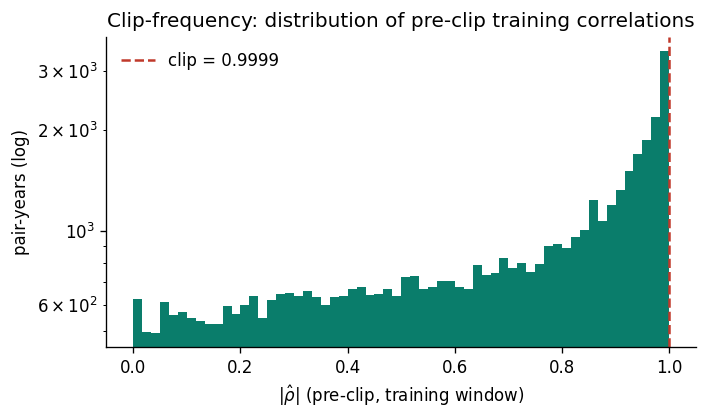

In [27]:
# ── PART 1  Clip frequency: how often does |rho|<=0.9999 actually bind? ──────
# RHO_TRAIN_LOG is populated during the reference build (cell 14) on the normal
# manuscript run (clip = 0.9999), so this reflects the real pipeline exactly.
import json, datetime
_absrho = np.abs(np.asarray(RHO_TRAIN_LOG, dtype=float))

clip_frequency = {
    "n_pair_years":            int(_absrho.size),
    "frac_abs_rho_gt_0.99":    round(float(np.mean(_absrho > 0.99)),   5),
    "frac_abs_rho_gt_0.999":   round(float(np.mean(_absrho > 0.999)),  5),
    "frac_abs_rho_gt_0.9999":  round(float(np.mean(_absrho > 0.9999)), 5),
    "count_clipped_at_0.9999": int(np.sum(_absrho > 0.9999)),
    "max_abs_rho_preclip":     round(float(_absrho.max()), 6) if _absrho.size else None,
}
print(f"Pre-clip training correlations logged: {clip_frequency['n_pair_years']:,}")
print(f"Clip binds (|rho|>0.9999): {clip_frequency['count_clipped_at_0.9999']} "
      f"pair-years ({100*clip_frequency['frac_abs_rho_gt_0.9999']:.4f}%)")
print(f"Fraction |rho|>0.99 : {clip_frequency['frac_abs_rho_gt_0.99']}")
print(f"Fraction |rho|>0.999: {clip_frequency['frac_abs_rho_gt_0.999']}")
print(f"Max pre-clip |rho|  : {clip_frequency['max_abs_rho_preclip']}")

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.hist(_absrho, bins=60, color="#0a7d6b")
ax.axvline(0.9999, ls="--", color="#c0392b", label="clip = 0.9999")
ax.set_yscale("log")
ax.set_xlabel(r"$|\hat{\rho}|$ (pre-clip, training window)")
ax.set_ylabel("pair-years (log)")
ax.set_title("Clip-frequency: distribution of pre-clip training correlations")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "clip_frequency.png"), dpi=200, bbox_inches="tight")
plt.show()

In [28]:
# ── PART 2  Clip robustness: rebuild the pipeline at three clip caps ─────────
# run_pipeline(clip_cap) re-executes the LFO reference build, raw NAD, the
# circular-block permutation null (seed 42), and the confidence-weighted domain
# scores, using the SAME helper functions and arithmetic as the main run and
# changing only the clip cap. At clip_cap=0.9999 it must reproduce nad_corrected.
ROBUST_CLIP_LEVELS = [0.999, 0.9999, 0.99999]   # 0.9999 = manuscript value
ROBUST_N_PERM      = 500                          # match the canonical null (cell 23)

_uids_order = list(num_matrix.index)
_data_arr   = num_matrix.reindex(_uids_order)[year_int_cols].values.astype(float)
_yidx       = {y: k for k, y in enumerate(year_int_cols)}
_ncol       = len(year_int_cols)

def _build_refs(clip_cap, drop_above=None):
    """Reproduce cell 14's lfo_refs at a given clip, storing inlined 2x2 coeffs."""
    refs = []
    for a in range(len(_uids_order)):
        row_i = _data_arr[a]
        for b in range(a + 1, len(_uids_order)):
            row_j = _data_arr[b]
            for t_idx in range(_ncol):
                if np.isnan(row_i[t_idx]) or np.isnan(row_j[t_idx]):
                    continue
                tr_i = []; tr_j = []
                for k in range(t_idx):                      # strictly-prior years
                    if not (np.isnan(row_i[k]) or np.isnan(row_j[k])):
                        tr_i.append(row_i[k]); tr_j.append(row_j[k])
                if len(tr_i) < LFO_MIN_OBS:
                    continue
                ref = mahal_reference(np.asarray(tr_i), np.asarray(tr_j),
                                      clip_cap=clip_cap, drop_above=drop_above)
                if ref is None:
                    continue
                T_train = len(tr_i); n_cap = min(T_train, 30)
                ci = ref['cov_inv']
                refs.append((a, b, year_int_cols[t_idx],
                             ref['mu'][0], ref['mu'][1],
                             ci[0, 0], ci[0, 1], ci[1, 1],
                             threshold_table[n_cap]['activation'],
                             confidence_score(T_train),
                             _uids_order[a], _uids_order[b]))
    return refs

def _w_from_raw(dx, dy, c00, c01, c11):
    """Uncapped w: the quantity compared against the F-corrected threshold."""
    w2 = c00*dx*dx + 2.0*c01*dx*dy + c11*dy*dy
    return np.sqrt(w2) if w2 > 0 else 0.0


def _w_from(dx, dy, c00, c01, c11):
    """Capped w: aggregation layer only (confidence-weighted indicator means)."""
    return min(_w_from_raw(dx, dy, c00, c01, c11), MAHAL_CAP)


def _w_activation(dx, dy, c00, c01, c11):
    w = _w_from_raw(dx, dy, c00, c01, c11)
    return min(w, MAHAL_CAP) if CAP_APPLIES_TO_ACTIVATION else w

def run_pipeline(clip_cap, n_perm=ROBUST_N_PERM, drop_above=None):
    refs = _build_refs(clip_cap, drop_above=drop_above)
    by_year = {y: [] for y in year_int_cols}
    for r in refs:
        by_year[r[2]].append(r)

    # raw NAD + confidence-weighted indicator numerators/denominators
    nad = {}; ind_num = {}; ind_den = {}
    for y in year_int_cols:
        yi = _yidx[y]; active = 0; elig = 0
        for (a, b, _t, mu0, mu1, c00, c01, c11, thr, conf, ui, uj) in by_year[y]:
            xi = _data_arr[a, yi]; xj = _data_arr[b, yi]
            if np.isnan(xi) or np.isnan(xj): continue
            elig += 1
            w_act = _w_activation(xi - mu0, xj - mu1, c00, c01, c11)
            if w_act >= thr: active += 1
            w = min(w_act, MAHAL_CAP)   # aggregation uses the capped weight
            inds = {uid_to_indicator.get(ui), uid_to_indicator.get(uj)}
            inds.discard(None)
            for ind in inds:                       # each pair counts once per indicator
                ind_num[(ind, y)] = ind_num.get((ind, y), 0.0) + conf * w
                ind_den[(ind, y)] = ind_den.get((ind, y), 0.0) + conf
        nad[y] = active / elig if elig else 0.0

    # domain scores (coverage-weighted mean of indicator anomalies; cells 20-21)
    ind_anom = {ind: {y: (ind_num.get((ind, y), 0.0) / ind_den[(ind, y)]
                          if ind_den.get((ind, y), 0.0) > 0 else 0.0)
                      for y in year_int_cols} for ind in indicators_list}
    dom_scores = {}
    for dom in sorted(set(ind_to_domain.values())):
        dinds = [i for i in indicators_list if ind_to_domain.get(i) == dom]
        dom_scores[dom] = {}
        for y in year_int_cols:
            ws = sum(ind_coverage_weight[i] * ind_anom[i][y] for i in dinds)
            tw = sum(ind_coverage_weight[i] for i in dinds)
            dom_scores[dom][y] = ws / tw if tw > 0 else 0.0

    # circular-block permutation null (identical scheme + seed to cell 23)
    rng = np.random.default_rng(seed=42)
    null = {y: [] for y in year_int_cols}
    for _ in range(n_perm):
        perm = _data_arr.copy()
        for row_i in range(len(_uids_order)):
            obs = np.where(~np.isnan(_data_arr[row_i]))[0]
            if len(obs) > 1:
                shift = int(rng.integers(1, len(obs)))
                perm[row_i, obs] = np.roll(_data_arr[row_i, obs], shift)
        for y in year_int_cols:
            yi = _yidx[y]; active = 0; elig = 0
            for (a, b, _t, mu0, mu1, c00, c01, c11, thr, conf, ui, uj) in by_year[y]:
                xi = perm[a, yi]; xj = perm[b, yi]
                if np.isnan(xi) or np.isnan(xj): continue
                elig += 1
                if _w_activation(xi - mu0, xj - mu1, c00, c01, c11) >= thr: active += 1
            null[y].append(active / elig if elig else 0.0)

    nstar = {y: nad[y] - float(np.mean(null[y])) for y in year_int_cols}
    nsd   = {y: float(np.std(null[y], ddof=1)) for y in year_int_cols}
    nci   = {y: [nstar[y] - 1.96 * nsd[y], nstar[y] + 1.96 * nsd[y]]
             for y in year_int_cols}
    return {"nad_star": nstar, "nad_star_ci": nci,
            "domain_scores": dom_scores, "n_refs": len(refs)}

print(f"Running clip sweep at {ROBUST_CLIP_LEVELS} (N_PERM={ROBUST_N_PERM}) ...")
print("This reruns the full pipeline per clip; expect a few minutes.")
results = {}
for c in ROBUST_CLIP_LEVELS:
    results[f"{c}"] = run_pipeline(c)
    print(f"  clip={c}: {results[f'{c}']['n_refs']:,} references built")

# ---- self-check: clip 0.9999 must reproduce the canonical NAD* -------------
if "nad_corrected" in globals():
    diffs = [abs(results["0.9999"]["nad_star"][y] - float(nad_corrected.get(y, np.nan)))
             for y in year_int_cols if not np.isnan(nad_corrected.get(y, np.nan))]
    md_ = max(diffs) if diffs else float("nan")
    print(f"\nSelf-check vs canonical nad_corrected (cell 23): max|diff| = {md_:.2e}",
          "-> PASS" if md_ < 1e-9 else "-> REVIEW")
else:
    print("\n(nad_corrected not in scope; run cell 23 first to enable the self-check.)")

# ---- assemble comparison ---------------------------------------------------
_lo, _hi = f"{min(ROBUST_CLIP_LEVELS)}", f"{max(ROBUST_CLIP_LEVELS)}"
_nad_maxdiff = max(abs(results[_hi]["nad_star"][y] - results[_lo]["nad_star"][y])
                   for y in year_int_cols)
_dom_maxdiff = max(abs(results[_hi]["domain_scores"][d][y] - results[_lo]["domain_scores"][d][y])
                   for d in results[_lo]["domain_scores"] for y in year_int_cols)

def _at(clip, year):
    r = results[clip]
    return {"nad_star": round(r["nad_star"].get(year), 4),
            "nad_star_ci": [round(v, 4) for v in r["nad_star_ci"].get(year)]}

clip_robustness = {
    "clip_levels": ROBUST_CLIP_LEVELS,
    "n_refs_per_clip": {c: results[c]["n_refs"] for c in results},
    "nad_star_max_abs_diff_across_clips": round(float(_nad_maxdiff), 6),
    "domain_score_max_abs_diff_across_clips": round(float(_dom_maxdiff), 6),
    "headline_2023": {c: _at(c, 2023) for c in results},
    "headline_2016_domains": {c: {d: round(results[c]["domain_scores"][d].get(2016), 3)
                                  for d in results[c]["domain_scores"]} for c in results},
}
print(f"\nMax |NAD*| change across clip levels: {clip_robustness['nad_star_max_abs_diff_across_clips']}")
print(f"Max |domain score| change across clip levels: {clip_robustness['domain_score_max_abs_diff_across_clips']}")
print("2023 NAD* by clip:", {c: clip_robustness['headline_2023'][c]['nad_star'] for c in results})

# ---- write shareable output ------------------------------------------------
out = {
    "metadata": {
        "generated": datetime.datetime.now().isoformat(timespec="seconds"),
        "clip_manuscript": 0.9999, "clip_levels": ROBUST_CLIP_LEVELS,
        "n_perm": ROBUST_N_PERM, "numpy": np.__version__,
    },
    "clip_frequency": clip_frequency if "clip_frequency" in globals() else None,
    "clip_robustness": clip_robustness,
}
_pth = os.path.join(RESULTS_DIR, "clip_check_output.json")
with open(_pth, "w") as f:
    json.dump(out, f, indent=2)
print(f"\nWrote {_pth}")

Running clip sweep at [0.999, 0.9999, 0.99999] (N_PERM=500) ...
This reruns the full pipeline per clip; expect a few minutes.
  clip=0.999: 50,038 references built
  clip=0.9999: 50,038 references built
  clip=0.99999: 50,038 references built

Self-check vs canonical nad_corrected (cell 23): max|diff| = 0.00e+00 -> PASS

Max |NAD*| change across clip levels: 0.033321
Max |domain score| change across clip levels: 0.045964
2023 NAD* by clip: {'0.999': 0.0822, '0.9999': 0.0823, '0.99999': 0.0825}

Wrote results\clip_check_output.json


In [29]:
# ── PART 3  Drop variant: EXCLUDE near-collinear pairs instead of clipping ───
# Directly addresses the reviewer's suggested remedy for strictly collinear
# variables. Drops every pair-year with pre-clip |rho| > 0.9999 (the 272 that
# the manuscript clips) and reruns the full pipeline. Compares to the clip run.
print("Running drop variant (exclude |rho|>0.9999 instead of clipping) ...")
drop_res = run_pipeline(clip_cap=0.9999, drop_above=0.9999)
clip_res = results["0.9999"]   # manuscript clip run, from Part 2

_nad_drop_diff = max(abs(drop_res["nad_star"][y] - clip_res["nad_star"][y])
                     for y in year_int_cols)
_dom_drop_diff = max(abs(drop_res["domain_scores"][d][y] - clip_res["domain_scores"][d][y])
                     for d in clip_res["domain_scores"] for y in year_int_cols)

clip_drop_variant = {
    "rule": "exclude pair-years with |rho|>0.9999 (vs clip)",
    "n_refs_clip":  clip_res["n_refs"],
    "n_refs_drop":  drop_res["n_refs"],
    "n_pairs_dropped": clip_res["n_refs"] - drop_res["n_refs"],
    "nad_star_max_abs_diff_vs_clip":    round(float(_nad_drop_diff), 6),
    "domain_score_max_abs_diff_vs_clip": round(float(_dom_drop_diff), 6),
    "headline_2023_drop": {
        "nad_star":    round(drop_res["nad_star"].get(2023), 4),
        "nad_star_ci": [round(v, 4) for v in drop_res["nad_star_ci"].get(2023)],
    },
    "headline_2016_domains_drop": {
        d: round(drop_res["domain_scores"][d].get(2016), 3)
        for d in drop_res["domain_scores"]
    },
}
print(f"  dropped {clip_drop_variant['n_pairs_dropped']} pair-years "
      f"({clip_res['n_refs']} -> {drop_res['n_refs']} references)")
print(f"  2023 NAD* : clip {clip_res['nad_star'][2023]:.4f}  ->  "
      f"drop {drop_res['nad_star'][2023]:.4f}")
print(f"  2023 CI drop: {clip_drop_variant['headline_2023_drop']['nad_star_ci']}")
print(f"  max |NAD*| change vs clip:        {clip_drop_variant['nad_star_max_abs_diff_vs_clip']}")
print(f"  max |domain score| change vs clip: {clip_drop_variant['domain_score_max_abs_diff_vs_clip']}")

# augment the shared JSON written in Part 2
_pth = os.path.join(RESULTS_DIR, "clip_check_output.json")
try:
    _cur = json.load(open(_pth))
except Exception:
    _cur = out if "out" in globals() else {}
_cur["clip_drop_variant"] = clip_drop_variant
with open(_pth, "w") as f:
    json.dump(_cur, f, indent=2)
print(f"Updated {_pth} with clip_drop_variant.")

Running drop variant (exclude |rho|>0.9999 instead of clipping) ...
  dropped 272 pair-years (50038 -> 49766 references)
  2023 NAD* : clip 0.0823  ->  drop 0.0825
  2023 CI drop: [0.046, 0.119]
  max |NAD*| change vs clip:        0.003192
  max |domain score| change vs clip: 0.145743
Updated results\clip_check_output.json with clip_drop_variant.


## 16. Figures

Shared scenario-annotation helper, then each manuscript figure in order.
The final panel is the monitor-versus-forecaster analysis: because LFO baselines
use only data strictly before year `t`, `NAD*(2023)` is already a prospective
score, and the question asked here is whether two forward signals available at
end-2022 (the expanding-window `EWS_CSD` and domain structural persistence)
anticipate the 2023 elevation.

### Scenario annotation helper

In [30]:
def annotate_scenarios(ax, ylim_frac=0.12):
    """
    Draw scenario and contextual markers on a time-series axis.

    Scenario markers (dashed, coloured vertical lines with rotated labels):
      - 2016  Housing structural break        (purple)
      - 2020  COVID-19 onset                  (red)
      - 2023  Post-COVID persistence          (orange)

    Contextual markers (dotted, no causal claim implied):
      - 2021  Heat Dome*  (grey)  — Pacific Northwest heat event; co-incides
              with Environment and Health & Well-being anomaly peaks.
      - 2018  Opioid*     (brown) — Health & Well-being domain peak
              attributable to the ongoing opioid crisis.

    The asterisk (*) on contextual markers signals observed co-incidence,
    not a formally tested causal relationship.

    Parameters
    ----------
    ax : matplotlib Axes
    ylim_frac : float
        Fractional y-position for scenario text labels (default 0.12,
        i.e. 12 % above the y-axis minimum).

    Notes
    -----
    - PLOT_START = 2015 is the first year with meaningful LFO confidence
      scores; 2014 (all conf = 0) is excluded from all figures.
    - Must be called *after* the axes ylim is set (e.g. after plotting data),
      because text positions are derived from ax.get_ylim().
    """
    ymin, ymax = ax.get_ylim()
    y_text = ymin + (ymax - ymin) * ylim_frac

    # ── Scenario markers ──────────────────────────────────────────────────────
    for sk, sv in SCENARIOS.items():
        ax.axvline(sv['year'], color=sv['color'], linestyle='--',
                   linewidth=1.5, alpha=0.85)
        ax.text(sv['year'] + 0.1, y_text, sv['label'],
                fontsize=10, fontweight='bold', color=sv['color'], rotation=90,
                ha='left', va='bottom')

    # ── Heat Dome* contextual marker (2021) ───────────────────────────────────
    ax.axvline(HEAT_DOME_YEAR, color='gray', linestyle=':',
               linewidth=1.0, alpha=0.6)
    ax.text(HEAT_DOME_YEAR + 0.1, ymin + (ymax - ymin) * 0.05,
            'Heat Dome*', fontsize=10, fontweight='bold', color='gray',
            rotation=90, ha='left', va='bottom')

    # ── Opioid* contextual marker (2018) ─────────────────────────────────────
    # Marks the 2018 Health & Well-being domain anomaly peak co-incident with
    # the opioid crisis. Drawn as a brown dotted line matching the style used
    # in Fig 2 so both figures are visually consistent.
    if 2018 in year_int_cols:
        ax.axvline(2018, color='#795548', linestyle=':',
                   linewidth=1.0, alpha=0.6)
        ax.text(2018 + 0.1, ymin + (ymax - ymin) * 0.05,
                'Opioid*', fontsize=10, fontweight='bold', color='#795548',
                rotation=90, ha='left', va='bottom')


print("annotate_scenarios() helper defined.")
print("  Markers: Housing (2016), COVID (2020), Post-COVID (2023),")
print("           Heat Dome* (2021), Opioid* (2018).")

annotate_scenarios() helper defined.
  Markers: Housing (2016), COVID (2020), Post-COVID (2023),
           Heat Dome* (2021), Opioid* (2018).


### NAD, robustness variants, NAD*, and EWS statistics

EWS_CSD plotted (NaN = undefined):
      EWS_CSD  minmax
2015      NaN     NaN
2016      NaN     NaN
2017      NaN     NaN
2018  -0.1615  0.8141
2019  -0.1786  0.7735
2020  -0.0829  1.0000
2021  -0.2437  0.6196
2022  -0.5056  0.0000
2023  -0.4277  0.1844
2024  -0.4289  0.1815


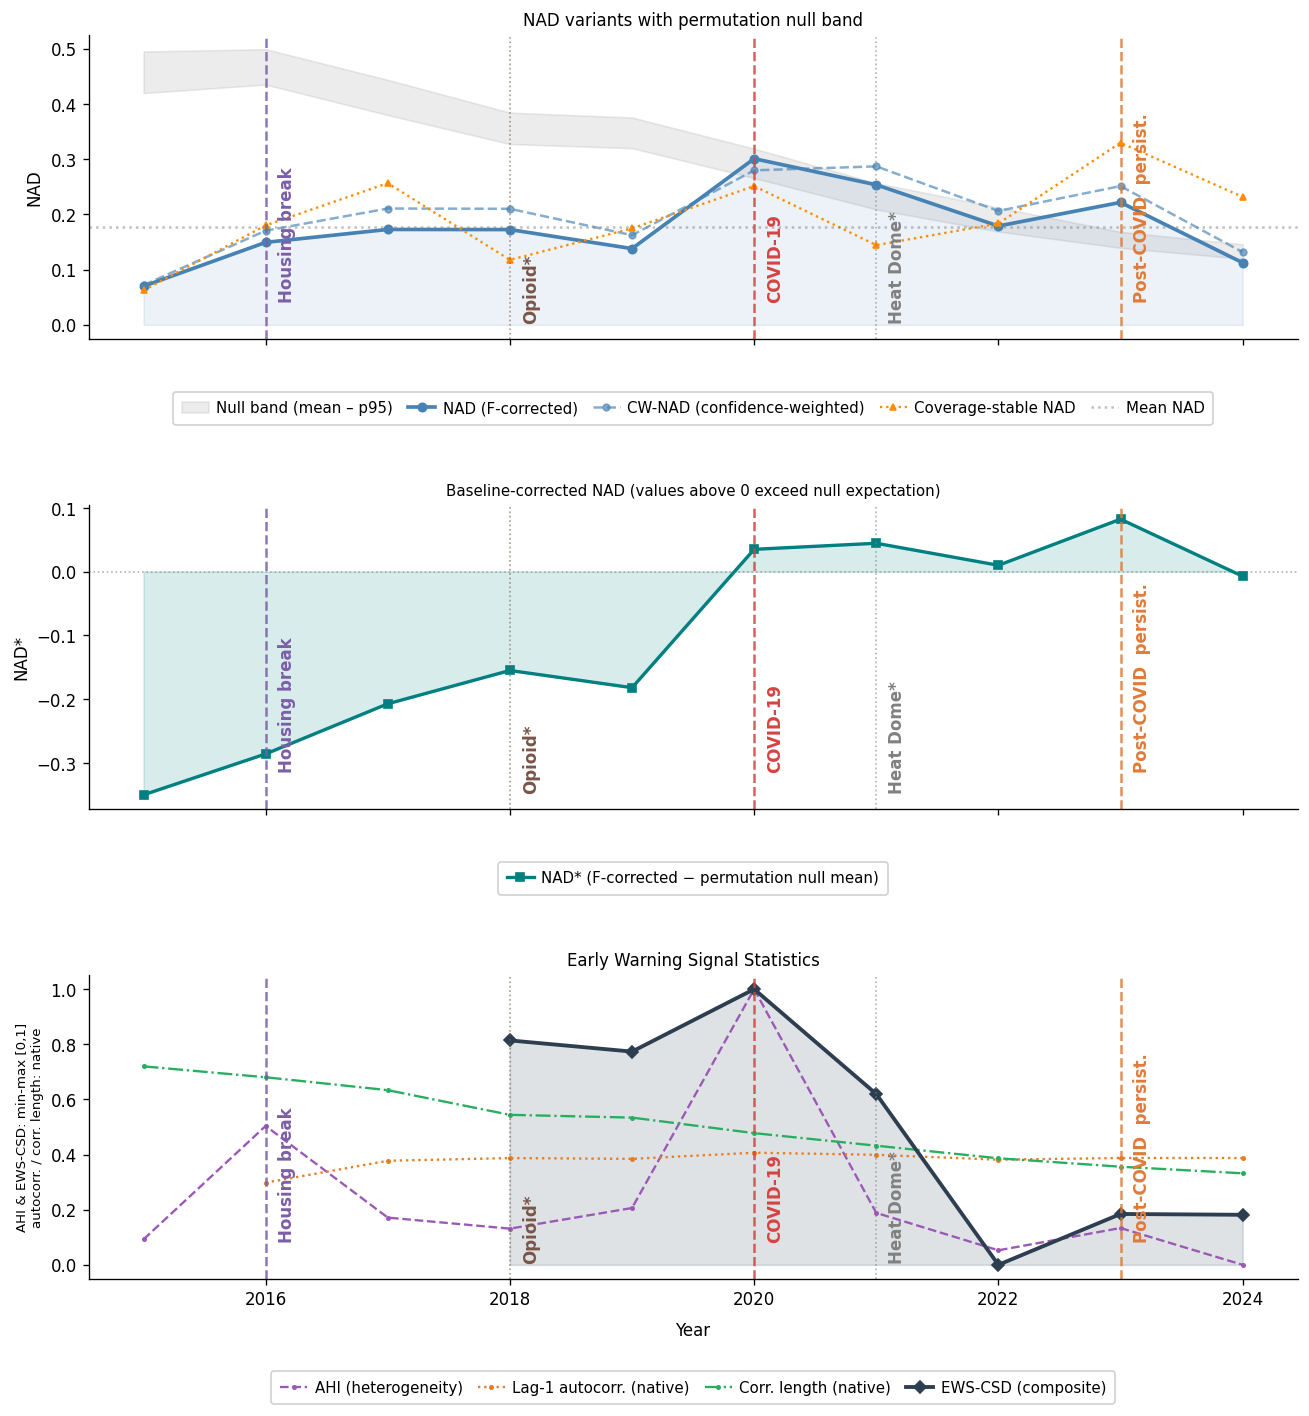

In [31]:
years       = [y for y in nad_df.index   if y >= PLOT_START]
nad_plot    = nad_df[nad_df.index        >= PLOT_START]
cw_nad_plot = cw_nad_df[cw_nad_df.index >= PLOT_START]
stable_plot = nad_stable_df[nad_stable_df.index >= PLOT_START]
nadc_plot   = nad_corrected[nad_corrected.index >= PLOT_START]
null_mean_plot = null_nad_mean[null_nad_mean.index >= PLOT_START]
null_p95_plot  = null_nad_p95[null_nad_p95.index  >= PLOT_START]

fig, axes = plt.subplots(3, 1, figsize=(13, 14), sharex=True)

# ── Panel 1: NAD variants + null band ────────────────────────────────────────
ax0 = axes[0]
ax0.fill_between(years, null_mean_plot.reindex(years).fillna(0).values,
                 null_p95_plot.reindex(years).fillna(0).values,
                 alpha=0.15, color='gray', label='Null band (mean – p95)')
ax0.fill_between(years, nad_plot.values, alpha=0.10, color='steelblue')
ax0.plot(years, nad_plot.values, color='steelblue', lw=2.2,
         marker='o', markersize=5, label='NAD (F-corrected)')
ax0.plot(years, cw_nad_plot.values, color='steelblue', lw=1.5,
         ls='--', marker='o', markersize=4, alpha=0.65,
         label='CW-NAD (confidence-weighted)')
ax0.plot(years, stable_plot.values, color='darkorange', lw=1.4,
         ls=':', marker='^', markersize=4, label='Coverage-stable NAD')
ax0.axhline(nad_plot.mean(), color='gray', ls=':', alpha=0.5, label='Mean NAD')
ax0.set_ylabel('NAD', fontsize=10)
ax0.set_title('NAD variants with permutation null band', fontsize=10)
ax0.legend(fontsize=9, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.15),
           columnspacing=1.0, handlelength=1.8, handletextpad=0.5,
           borderpad=0.6, framealpha=0.9)
annotate_scenarios(ax0)

# ── Panel 2: Baseline-corrected NAD* ─────────────────────────────────────────
ax1 = axes[1]
ax1.axhline(0, color='gray', ls=':', lw=1, alpha=0.6)
ax1.fill_between(years, nadc_plot.reindex(years).fillna(0).values,
                 alpha=0.15, color='teal')
ax1.plot(years, nadc_plot.reindex(years).fillna(0).values,
         color='teal', lw=2.0, marker='s', markersize=5,
         label='NAD* (F-corrected − permutation null mean)')
ax1.set_ylabel('NAD*', fontsize=10)
ax1.set_title('Baseline-corrected NAD (values above 0 exceed null expectation)',
              fontsize=9)
ax1.legend(fontsize=9, ncol=1, loc='upper center', bbox_to_anchor=(0.5, -0.15),
           columnspacing=1.0, handlelength=1.8, handletextpad=0.5,
           borderpad=0.6, framealpha=0.9)
annotate_scenarios(ax1)

# ── Panel 3: EWS statistics ───────────────────────────────────────────────────
ax2 = axes[2]
ax2.plot(years, norm01(ahi_s.reindex(years)).values,
         color='#9B59B6', lw=1.4, ls='--', marker='.', markersize=4,
         label='AHI (heterogeneity)')
ax2.plot(years, ews_ac.reindex(years).values,
         color='#E67E22', lw=1.4, ls=':', marker='.', markersize=4,
         label='Lag-1 autocorr. (native)')
ax2.plot(years, ews_cl.reindex(years).values,
         color='#27AE60', lw=1.4, ls='-.', marker='.', markersize=4,
         label='Corr. length (native)')
# EWS_CSD is undefined for 2015-2017 (Section IV H).  NaNs are preserved so the
# line breaks rather than being imputed; norm01 ignores them for min/max.
csd_norm = norm01(ews_csd.reindex(years))
print("EWS_CSD plotted (NaN = undefined):")
print(pd.concat([ews_csd.reindex(years).rename('EWS_CSD'),
                 csd_norm.rename('minmax')], axis=1).round(4).to_string())
ax2.fill_between(years, csd_norm.values, alpha=0.15, color='#2C3E50')
ax2.plot(years, csd_norm.values,
         color='#2C3E50', lw=2.3, marker='D', markersize=5,
         label='EWS-CSD (composite)')
ax2.set_ylabel('AHI & EWS-CSD: min-max [0,1]\nautocorr. / corr. length: native', fontsize=8)
ax2.set_xlabel('Year', fontsize=10, labelpad=8)
ax2.set_title('Early Warning Signal Statistics', fontsize=10)
ax2.legend(fontsize=9, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.28),
           columnspacing=1.0, handlelength=1.8, handletextpad=0.5,
           borderpad=0.6, framealpha=0.9)
annotate_scenarios(ax2)

# ── Layout & save ─────────────────────────────────────────────────────────────
fig.subplots_adjust(hspace=0.55, bottom=0.14)
plt.savefig(os.path.join(RESULTS_DIR, 'fig1_nad_ews_over_time.png'),
            bbox_inches='tight')
plt.show()

### Domain anomaly heatmap

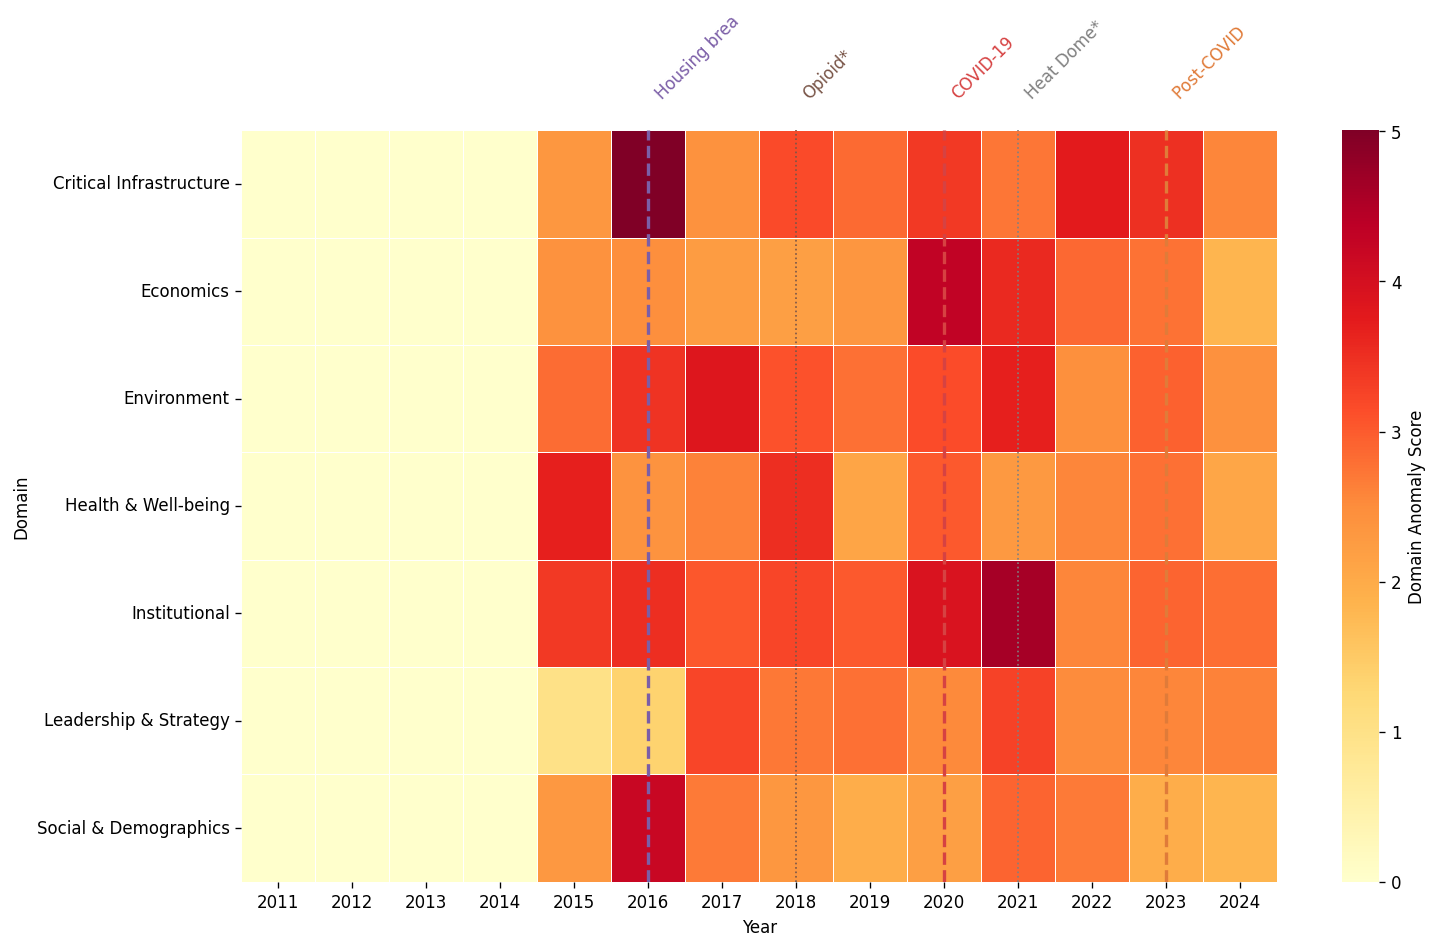

In [32]:
# ── Fig 2 — Domain anomaly heatmap ───────────────────────────────────────────
# Rows: 7 domains.  Columns: all analysis years (2011–2024).
# Colour: YlOrRd scale, warmer = more anomalous domain-level behaviour.
#
# Overlaid vertical lines mark four temporal reference points:
#   - Scenario years  (Housing 2016, COVID 2020, Post-COVID 2023) — dashed,
#     coloured to match the rest of the notebook.
#   - Heat Dome* 2021 — grey dotted line + text label.
#   - Opioid*    2018 — brown dotted line + text label.
#
# Note: heatmap columns are integer-indexed (0 = 2011, 1 = 2012, …), so
#   vertical line positions are computed as
#   year_int_cols.index(year) + 0.5   (0.5 centres the line in the column).

fig, ax = plt.subplots(figsize=(13, 8))
dom_plot = dom_anomaly_df[[y for y in year_int_cols
                            if y in dom_anomaly_df.columns]].astype(float)
sns.heatmap(dom_plot, ax=ax, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Domain Anomaly Score'})
ax.set_xlabel('Year')
ax.set_ylabel('Domain')

# ── Scenario year markers ─────────────────────────────────────────────────────
for sk, sv in SCENARIOS.items():
    if sv['year'] in year_int_cols:
        col_pos = year_int_cols.index(sv['year']) + 0.5
        ax.axvline(col_pos, color=sv['color'], linewidth=2, linestyle='--')
        ax.text(col_pos + 0.05, -0.3, sv['label'][:12],
                fontsize=10, color=sv['color'], rotation=45, ha='left')

# ── Heat Dome* contextual marker (2021) ──────────────────────────────────────
# The 2021 Pacific Northwest heat event is marked as a grey dotted line.
# the line to appear unlabelled.  Both are required and are included here.
if HEAT_DOME_YEAR in year_int_cols:
    cp = year_int_cols.index(HEAT_DOME_YEAR) + 0.5
    ax.axvline(cp, color='gray', linewidth=1, linestyle=':')
    ax.text(cp + 0.05, -0.3, 'Heat Dome*',
            fontsize=10, color='gray', rotation=45, ha='left')

# ── Opioid* contextual marker (2018) ─────────────────────────────────────────
# Marks the 2018 Health & Well-being peak co-incident with the opioid crisis.
if 2018 in year_int_cols:
    col_2018 = year_int_cols.index(2018) + 0.5
    ax.axvline(col_2018, color='#795548', linewidth=1, linestyle=':')
    ax.text(col_2018 + 0.05, -0.3, 'Opioid*',
            fontsize=10, color='#795548', rotation=45, ha='left')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig2_domain_anomaly_heatmap.png'),
            bbox_inches='tight')
plt.show()

### Domain Coupling Index at lags 0, 1, 2

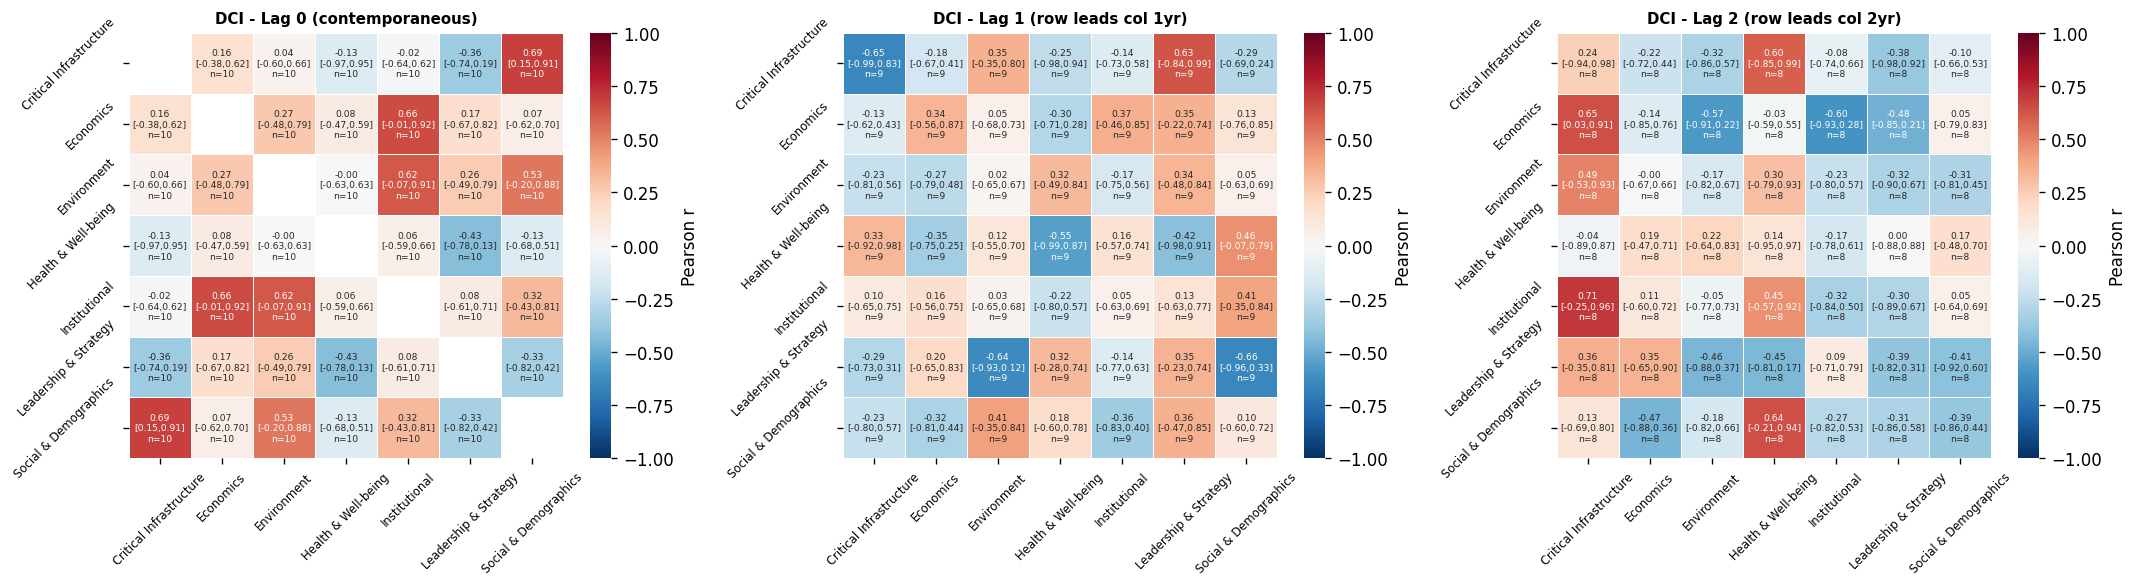

DCI figures include 95% Fisher z-transform CIs and n_obs per cell.


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lag_dcis  = [
    ('Lag 0 (contemporaneous)',  dci_df,   dci_lo_0, dci_hi_0, dci_n_0),
    ('Lag 1 (row leads col 1yr)', dci_lag1, dci_lo_1, dci_hi_1, dci_n_1),
    ('Lag 2 (row leads col 2yr)', dci_lag2, dci_lo_2, dci_hi_2, dci_n_2),
]
mask_diag = np.eye(len(dci_df), dtype=bool)

for ax, (title, dci_data, lo, hi, nn) in zip(axes, lag_dcis):
    # Build annotation strings: "r\n[lo,hi]\nn=N"
    annot_arr = np.empty_like(dci_data.values, dtype=object)
    for i_r in range(len(dci_data)):
        for i_c in range(len(dci_data.columns)):
            r_val = dci_data.values[i_r, i_c]
            n_val = nn.values[i_r, i_c]
            lo_v  = lo.values[i_r, i_c]
            hi_v  = hi.values[i_r, i_c]
            if np.isnan(r_val):
                annot_arr[i_r, i_c] = ''
            elif np.isnan(lo_v):
                annot_arr[i_r, i_c] = f'{r_val:.2f}\nn={n_val:.0f}'
            else:
                annot_arr[i_r, i_c] = (f'{r_val:.2f}\n' +
                                        f'[{lo_v:.2f},{hi_v:.2f}]\n' +
                                        f'n={n_val:.0f}')
    sns.heatmap(dci_data.astype(float), ax=ax, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1,
                mask=(mask_diag if dci_data is dci_df else None),
                annot=annot_arr, fmt='', annot_kws={'size': 5.5},
                linewidths=0.3, linecolor='white',
                cbar_kws={'label': 'Pearson r'})
    ax.set_title(f'DCI - {title}', fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7, rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'fig3_domain_coupling_index.png'),
            bbox_inches='tight')
plt.show()
print("DCI figures include 95% Fisher z-transform CIs and n_obs per cell.")

### Indicator-level anomaly network, 2020

build_indicator_graph() defined.
cluster_layout() defined.
FIG5_DISPLAY_THR = 3.0349  (asymptotic chi2 alert level)


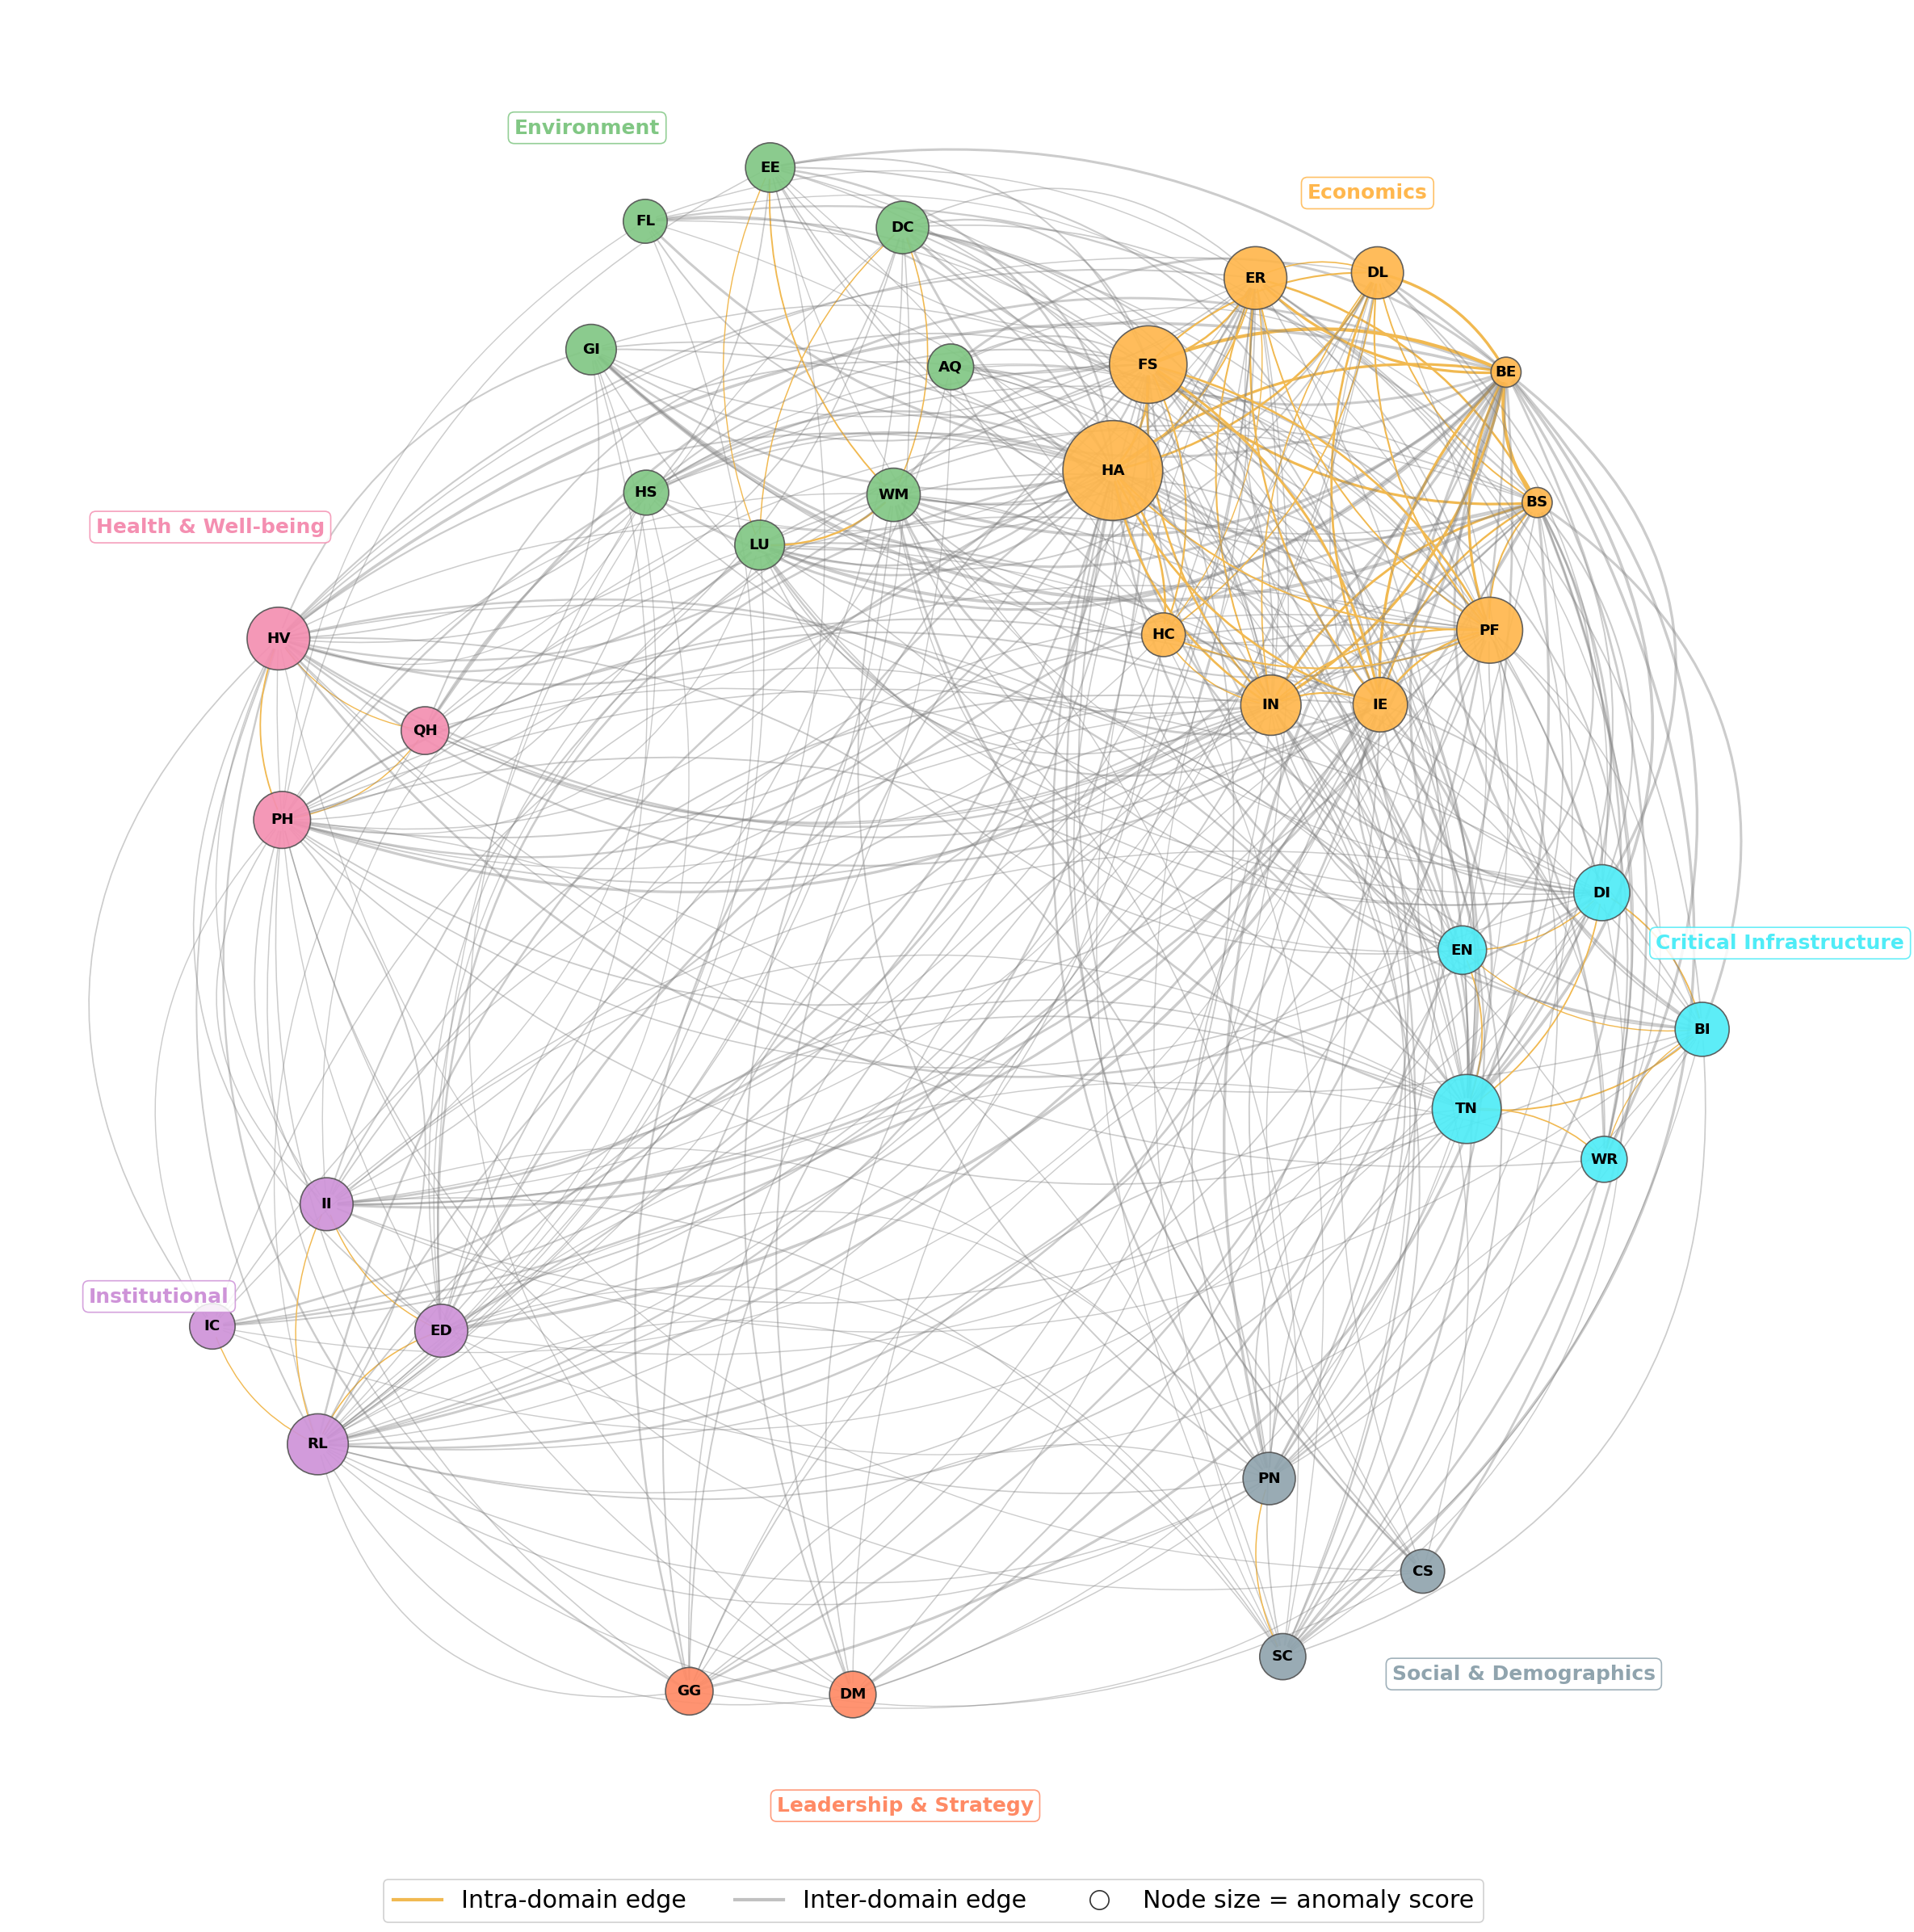

35 indicators, 382 edges


In [34]:
# ── Helper functions for indicator-level network visualisation ───────────────
# build_indicator_graph and cluster_layout were referenced in v7 but never
# defined. Reconstructed here from their calling signatures and usage context.

# Display threshold for Figs 5 and 10: chi^2(2) alert level (p=0.01 asymptote)
FIG5_DISPLAY_THR = ALERT_THR_ASYMP   # 3.035

def build_indicator_graph(year, display_thr=ALERT_THR_ASYMP):
    """
    Build an undirected indicator-level anomaly graph for one year.

    Nodes  : all indicators in indicators_list
             attrs  → domain (str), score (float = A_k(year))
    Edges  : indicator pairs whose mean sub-indicator Mahalanobis weight
             across all bridging pairs exceeds display_thr
             attrs  → weight (float, mean w across bridging sub-indicator pairs)

    Uses edges_t (sub-indicator level) and uid_to_indicator mapping.
    """
    G = nx.Graph()
    for ind in indicators_list:
        G.add_node(ind,
                   domain=ind_to_domain.get(ind, 'Unknown'),
                   score=float(ind_anomaly.get(ind, {}).get(year, 0.0)))

    # Aggregate sub-indicator weights to indicator pairs
    ind_pair_w = {}
    for (uid_i, uid_j), yw in edges_t.items():
        if year not in yw:
            continue
        ii = uid_to_indicator.get(uid_i, '')
        ij = uid_to_indicator.get(uid_j, '')
        if not ii or not ij or ii == ij:
            continue
        key = tuple(sorted([ii, ij]))
        ind_pair_w.setdefault(key, []).append(yw[year])

    # Add edges above display threshold
    for (ii, ij), weights in ind_pair_w.items():
        mean_w = float(np.mean(weights))
        if mean_w >= display_thr:
            G.add_edge(ii, ij, weight=mean_w)

    return G


def cluster_layout(G, cluster_radius=3.0, ring_radius=40, seed=42):
    """
    Domain-clustered circular layout for indicator-level graphs.

    Indicators within the same domain are grouped into a sub-cluster
    placed on an outer ring of radius ring_radius.  Within each cluster
    nodes are arranged on a circle of radius cluster_radius + 0.5*n_nodes.

    Returns
    -------
    pos           : dict {node: np.array([x, y])}
    cluster_groups: dict {domain: [nodes]}
    """
    rng_state = np.random.get_state()
    np.random.seed(seed)

    cluster_groups = {}
    for node in G.nodes():
        dom = G.nodes[node].get('domain', 'Unknown')
        cluster_groups.setdefault(dom, []).append(node)

    pos         = {}
    sorted_doms = sorted(cluster_groups.items())
    n_doms      = max(len(sorted_doms), 1)

    for i, (dom_name, nodes) in enumerate(sorted_doms):
        num_nodes = len(nodes)
        local_r   = cluster_radius + 0.5 * num_nodes
        angle_c   = 2 * np.pi * i / n_doms
        cx        = ring_radius * np.cos(angle_c)
        cy        = ring_radius * np.sin(angle_c)
        for j, node in enumerate(sorted(nodes)):
            theta  = j * 2 * np.pi / max(num_nodes, 1)
            jitter = np.radians(np.random.uniform(-5, 5))
            pos[node] = np.array([
                cx + local_r * np.cos(theta + jitter),
                cy + local_r * np.sin(theta + jitter),
            ])

    np.random.set_state(rng_state)
    return pos, cluster_groups

print(f"build_indicator_graph() defined.")
print(f"cluster_layout() defined.")
print(f"FIG5_DISPLAY_THR = {FIG5_DISPLAY_THR:.4f}  (asymptotic chi2 alert level)")


from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# ── Domain colour palette (unchanged from Fig 5) ──────────────────────────────
domain_palette = {
    'Critical Infrastructure': '#4FECF7',
    'Economics':               '#FFB74D',
    'Environment':             '#81C784',
    'Health & Well-being':     '#F48FB1',
    'Institutional':           '#CE93D8',
    'Leadership & Strategy':   '#FF8A65',
    'Social & Demographics':   '#90A4AE',
    'Unknown':                 '#CCCCCC',
}

# ── Build graph (unchanged) ───────────────────────────────────────────────────
plot_year = SCENARIOS['covid']['year']
G_vis = build_indicator_graph(plot_year, display_thr=FIG5_DISPLAY_THR)
active_inds = [n for n in G_vis.nodes() if G_vis.degree(n) > 0]
G_vis = G_vis.subgraph(active_inds).copy()

# ── Cluster membership ────────────────────────────────────────────────────────
cluster_groups = {}
for node in G_vis.nodes():
    dom = G_vis.nodes[node].get('domain', 'Unknown')
    cluster_groups.setdefault(dom, []).append(node)

# ── Layout: domain-clustered circular (matching reference code) ───────────────
np.random.seed(42)
CLUSTER_RADIUS = 40          # matches reference code

pos = {}
sorted_doms = sorted(cluster_groups.items())
for i, (dom_name, nodes) in enumerate(sorted_doms):
    num_nodes    = len(nodes)
    local_radius = 3 + num_nodes          # same formula as reference
    angle_center = 2 * np.pi * i / len(cluster_groups)
    cx = CLUSTER_RADIUS * np.cos(angle_center)
    cy = CLUSTER_RADIUS * np.sin(angle_center)
    for j, node in enumerate(sorted(nodes)):
        theta  = j * 2 * np.pi / max(num_nodes, 1)
        jitter = np.radians(np.random.uniform(-5, 5))  # tighter jitter (±5°)
        pos[node] = np.array([
            cx + local_radius * np.cos(theta + jitter),
            cy + local_radius * np.sin(theta + jitter),
        ])

# ── Node appearance ───────────────────────────────────────────────────────────
max_sc = max(
    (ind_anomaly.get(n, {}).get(plot_year, 0.0) for n in G_vis.nodes()),
    default=1.0,
)

node_colors    = [domain_palette.get(G_vis.nodes[n].get('domain', 'Unknown'), '#CCC')
                  for n in G_vis.nodes()]
node_sizes = [
    500 + 5000 * ((ind_anomaly.get(n, {}).get(plot_year, 0.0) / max(max_sc, 0.01)) ** 1.5) 
    for n in G_vis.nodes()
]
node_linewidths = [1.0] * G_vis.number_of_nodes()
node_edgecolors = ['#555555'] * G_vis.number_of_nodes()

display_labels = {n: ind_to_abbr.get(n, n[:4]) for n in G_vis.nodes()}

# ── Edge appearance ───────────────────────────────────────────────────────────
all_w  = [G_vis[u][v]['weight'] for u, v in G_vis.edges()]
max_w  = max(all_w) if all_w else 1.0

edge_colors, edge_widths, edge_styles = [], [], []
for u, v in G_vis.edges():
    intra = G_vis.nodes[u].get('domain', '') == G_vis.nodes[v].get('domain', '')
    w     = G_vis[u][v]['weight']
    if intra:
        edge_colors.append('#F1B951')
        r = 0.22 if hash((u, v)) % 2 == 0 else -0.22
    else:
        edge_colors.append((0.5, 0.5, 0.5, 0.4))
        r = (0.25 + 0.05 * (hash((u, v)) % 5))
        r = r if hash((u, v)) % 5 == 0 else -r
    edge_widths.append(0.5 + 2.0 * (w / max_w))
    edge_styles.append('arc3,rad=%.2f' % r)

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 20))

nx.draw_networkx_nodes(G_vis, pos, ax=ax,
                       node_color=node_colors, node_size=node_sizes,
                       linewidths=node_linewidths, edgecolors=node_edgecolors,
                       alpha=0.92)
nx.draw_networkx_labels(G_vis, pos, ax=ax,
                        labels=display_labels,
                        font_size=11, font_weight='bold')

for idx, (u, v) in enumerate(G_vis.edges()):
    nx.draw_networkx_edges(G_vis, pos, ax=ax, edgelist=[(u, v)],
                           edge_color=[edge_colors[idx]],
                           width=edge_widths[idx],
                           connectionstyle=edge_styles[idx],
                           arrows=True, arrowstyle="-", arrowsize=1)   # undirected — no arrows

# ── Domain labels (matching reference offset logic) ───────────────────────────
LABEL_OFFSETS = {
    'Critical Infrastructure': (-7,  5),
    'Economics':               (-13, -2),
    'Environment':             (-6, -9),
    'Health & Well-being':     (9,   4),
    'Institutional':           (7,   10),
    'Leadership & Strategy':   (12, 10),
    'Social & Demographics':   (1,   8),
    'Unknown':                 (0,   0),
}

for dom_name, nodes in cluster_groups.items():
    vis_n = [n for n in nodes if n in pos]
    if not vis_n: continue
    col  = domain_palette.get(dom_name, '#333333')
    xs   = [pos[n][0] for n in vis_n]
    ys   = [pos[n][1] for n in vis_n]
    cx, cy      = np.mean(xs), np.mean(ys)
    local_r     = 3 + len(vis_n)
    angle       = np.arctan2(cy, cx)
    lx = cx + (local_r + 12) * np.cos(angle)
    ly = cy + (local_r + 12) * np.sin(angle)
    dx, dy = LABEL_OFFSETS.get(dom_name, (0, 0))
    lx += dx
    ly += dy
    ax.text(lx, ly, dom_name,
            fontsize=15, fontweight='bold',
            ha='center', va='center', color=col,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=col, alpha=0.85))

# ── Legend ────────────────────────────────────────────────────────────────────
ax.legend(handles=[
    Line2D([0], [0], color='#F1B951',        lw=2.5, label='Intra-domain edge'),
    Line2D([0], [0], color=(0.6, 0.6, 0.6, 0.6), lw=2.5, label='Inter-domain edge'),
    # Replaced Patch with a Line2D circle marker
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', 
           markeredgecolor='#333', markersize=14, label='Node size = anomaly score'),
], loc='upper center', bbox_to_anchor=(0.5, -0.01), ncol=3, fontsize=18, framealpha=0.9)

# ax.set_title(
#     f'Indicator-Level Parenclitic Anomaly Network — {plot_year} (LFO)\n'
#     f'Display threshold: alert level w ≥ {FIG5_DISPLAY_THR:.3f} (χ² p=0.01)',
#     fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f'fig5_indicator_network_{plot_year}.png'),
            dpi=200, bbox_inches='tight')
plt.show()
print(f"{G_vis.number_of_nodes()} indicators, {G_vis.number_of_edges()} edges")

### NAD variants against the permutation null band

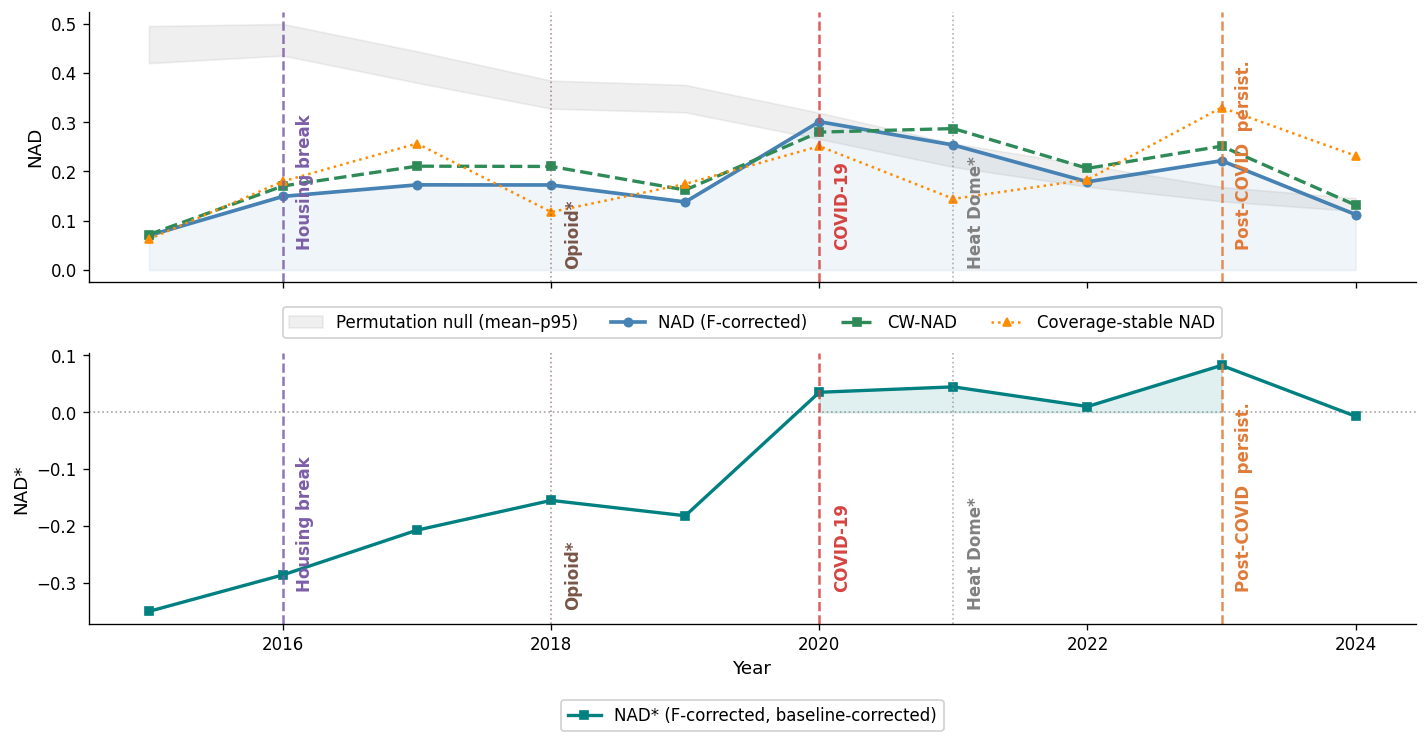

In [35]:
years       = [y for y in nad_df.index if y >= PLOT_START]
nad_plot    = nad_df[nad_df.index      >= PLOT_START]
cw_nad_plot = cw_nad_df[cw_nad_df.index >= PLOT_START]
stable_plot = nad_stable_df[nad_stable_df.index >= PLOT_START]
nadc_plot   = nad_corrected[nad_corrected.index >= PLOT_START]
null_mean_p = null_nad_mean[null_nad_mean.index >= PLOT_START]
null_p95_p  = null_nad_p95[null_nad_p95.index   >= PLOT_START]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax0 = axes[0]
ax0.fill_between(years, null_mean_p.reindex(years).fillna(0).values,
                 null_p95_p.reindex(years).fillna(0).values,
                 alpha=0.12, color='gray', label='Permutation null (mean–p95)')
ax0.fill_between(years, nad_plot.values, alpha=0.08, color='steelblue')
ax0.plot(years, nad_plot.values,    color='steelblue', lw=2.2,
         marker='o', markersize=5, label='NAD (F-corrected)')
ax0.plot(years, cw_nad_plot.values, color='seagreen',  lw=2,
         ls='--', marker='s', markersize=5, label='CW-NAD')
ax0.plot(years, stable_plot.values, color='darkorange', lw=1.5,
         ls=':', marker='^'  , markersize=5, label='Coverage-stable NAD')
ax0.set_ylabel('NAD', fontsize=11)
ax0.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.06),
           ncol=4, framealpha=0.9)
annotate_scenarios(ax0)

ax1 = axes[1]
ax1.axhline(0, color='gray', ls=':', lw=1, alpha=0.7)
ax1.fill_between(years, nadc_plot.reindex(years).fillna(0).values,
                 alpha=0.12, color='teal',
                 where=nadc_plot.reindex(years).fillna(0).values > 0)
ax1.plot(years, nadc_plot.reindex(years).fillna(0).values,
         color='teal', lw=2.0, marker='s', markersize=5,
         label='NAD* (F-corrected, baseline-corrected)')
ax1.set_ylabel('NAD*', fontsize=11)
ax1.set_xlabel('Year', fontsize=11)

# 1. Lower the legend by changing -0.15 to -0.25 (or -0.3 if you need even more room)
ax1.legend(fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.25), 
           ncol=1, framealpha=0.9)
annotate_scenarios(ax1)

plt.tight_layout()

# 2. Increase the bottom margin so the legend isn't clipped
# (Changed from 0.18 to 0.25)
fig.subplots_adjust(bottom=0.25) 

plt.savefig(os.path.join(RESULTS_DIR, 'fig8_nad_comparison.png'), bbox_inches='tight')
plt.show()

### NAD sensitivity to fixed thresholds

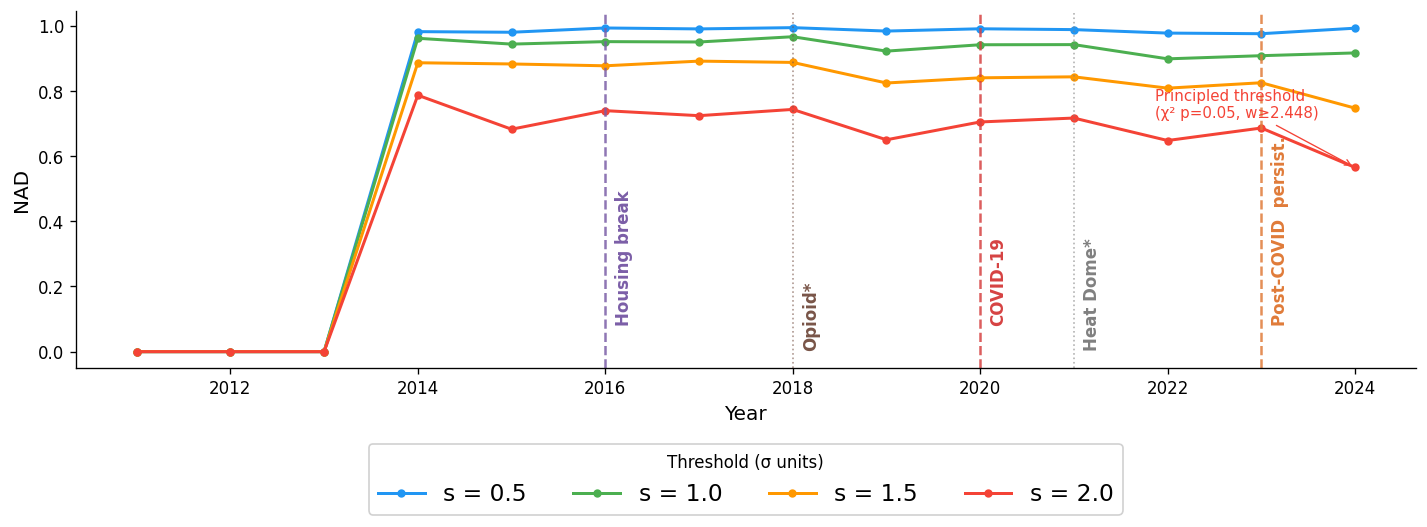

In [36]:
fig, ax = plt.subplots(figsize=(12, 4))
colors_s = ['#2196F3','#4CAF50','#FF9800','#F44336']
for thr, col in zip(thresholds, colors_s):
    vals = sens_df[sens_df['threshold']==thr].sort_values('year')['NAD'].values
    ax.plot(year_int_cols, vals, color=col, lw=1.8, marker='o', markersize=4,
            label=f's = {thr}')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('NAD', fontsize=12)
# ax.set_title('NAD Sensitivity to Anomaly Threshold (LFO)',
#              fontsize=11, fontweight='bold')
# Mark the principled chi2(2) threshold
ax.axhline(y=0, alpha=0)   # force y-range update before reading it
ymin, ymax = ax.get_ylim()
for yr_val in year_int_cols:
    pass   # ensure x-axis populated
# Add principled threshold as a shaded reference — show what NAD looks like
# at w>=2.448 by highlighting it differently in the legend
ax.annotate(
    f'Principled threshold\n(\u03c7\u00b2 p=0.05, w\u22652.448)',
    xy=(year_int_cols[-1], sens_df[
        (sens_df['threshold']==2.0) &
        (sens_df['year']==year_int_cols[-1])]['NAD'].values[0]),
    xytext=(-120, 30), textcoords='offset points',
    fontsize=9, color='#F44336',
    arrowprops=dict(arrowstyle='->', color='#F44336', lw=0.8))
ax.legend(title='Threshold (σ units)', fontsize=14, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, framealpha=0.9)
annotate_scenarios(ax)
plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
plt.savefig(os.path.join(RESULTS_DIR, 'fig9_nad_sensitivity.png'), bbox_inches='tight')
plt.show()

### Housing structural break, 2015-2019

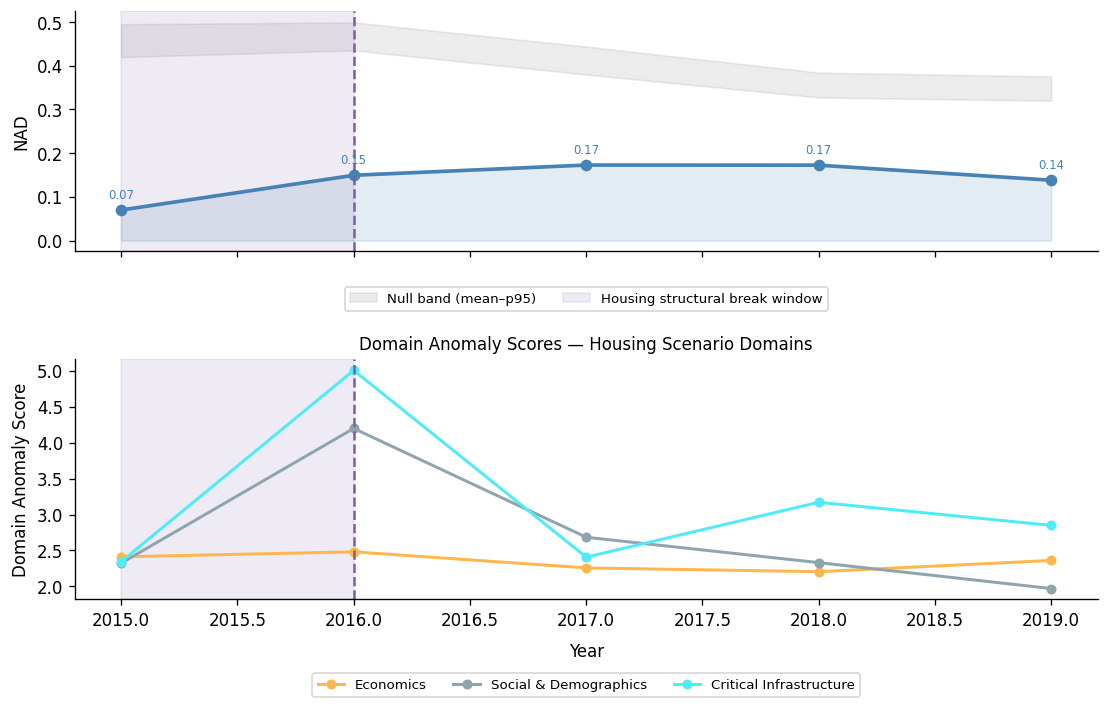

In [37]:
# Housing scenario: zoom 2014-2019
zoom_years = [y for y in year_int_cols if PLOT_START <= y <= 2019]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

nad_zoom = [nad_series[y] for y in zoom_years]
null_mean_zoom = null_nad_mean.reindex(zoom_years).fillna(0)
null_p95_zoom  = null_nad_p95.reindex(zoom_years).fillna(0)
axes[0].fill_between(zoom_years,
                     null_mean_zoom.values,
                     null_p95_zoom.values,
                     alpha=0.15, color='gray',
                     label='Null band (mean\u2013p95)')
axes[0].plot(zoom_years, nad_zoom, color='steelblue', lw=2.2, marker='o', markersize=6)
axes[0].fill_between(zoom_years, nad_zoom, alpha=0.15, color='steelblue')
axes[0].axvspan(2015, 2016, alpha=0.12,
                color=SCENARIOS['housing']['color'],
                label='Housing structural break window')
axes[0].axvline(2016, color=SCENARIOS['housing']['color'], ls='--', lw=1.5)
axes[0].set_ylabel('NAD', fontsize=10)
axes[0].legend(fontsize=8, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.12))
for y, v in zip(zoom_years, nad_zoom):
    axes[0].annotate(f'{v:.2f}', (y, v), textcoords='offset points',
                     xytext=(0, 7), ha='center', fontsize=7, color='steelblue')

doms_plot = ['Economics', 'Social & Demographics', 'Critical Infrastructure']
cmap_doms = ['#FFB74D', '#90A4AE', '#4FECF7']
for dom, col in zip(doms_plot, cmap_doms):
    y_vals  = [dom_anomaly[dom].get(y, np.nan) for y in zoom_years]
    valid_y = [y for y, v in zip(zoom_years, y_vals) if not np.isnan(v)]
    valid_v = [v for v in y_vals if not np.isnan(v)]
    if valid_y:
        axes[1].plot(valid_y, valid_v, color=col, lw=1.8, marker='o',
                     markersize=5, label=dom)
axes[1].axvspan(2015, 2016, alpha=0.12, color=SCENARIOS['housing']['color'])
axes[1].axvline(2016, color=SCENARIOS['housing']['color'], ls='--', lw=1.5)
axes[1].set_xlabel('Year', fontsize=10, labelpad=8)
axes[1].set_ylabel('Domain Anomaly Score', fontsize=10)
axes[1].legend(fontsize=8, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.28))
axes[1].set_title('Domain Anomaly Scores — Housing Scenario Domains', fontsize=10)

fig.subplots_adjust(hspace=0.45, bottom=0.18)
plt.savefig(os.path.join(RESULTS_DIR, 'fig11_housing_scenario.png'),
            bbox_inches='tight')
plt.show()

### Post-COVID period, 2015-2024

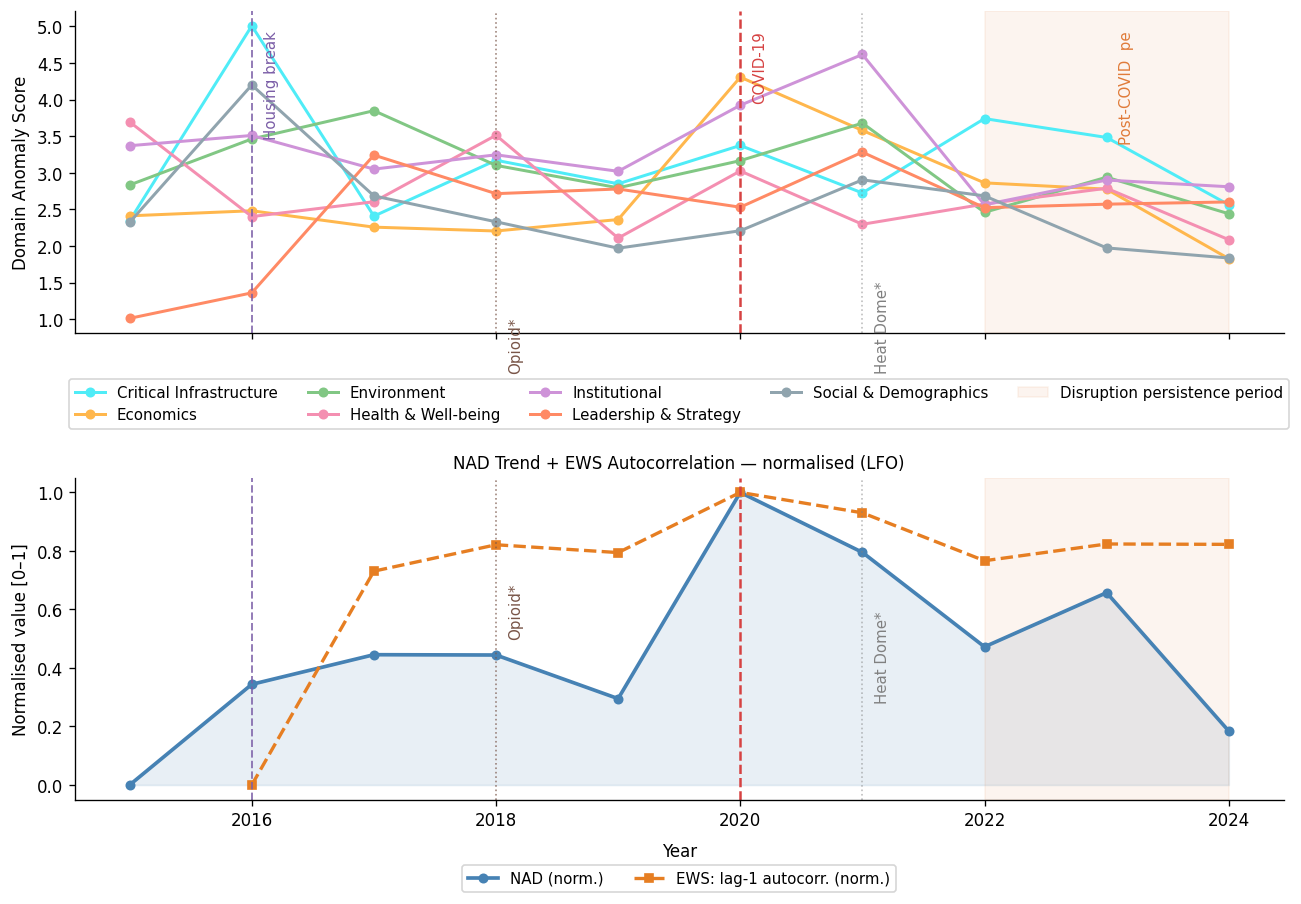

In [38]:
zoom2 = [y for y in year_int_cols if y >= PLOT_START]
all_dom_colors = {
    'Critical Infrastructure': '#4FECF7',
    'Economics':               '#FFB74D',
    'Environment':             '#81C784',
    'Health & Well-being':     '#F48FB1',
    'Institutional':           '#CE93D8',
    'Leadership & Strategy':   '#FF8A65',
    'Social & Demographics':   '#90A4AE',
}

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# ── Panel 1: all domain trajectories ─────────────────────────────────────────
for dom, col in all_dom_colors.items():
    y_vals  = [dom_anomaly[dom].get(y, np.nan) for y in zoom2]
    valid_y = [y for y, v in zip(zoom2, y_vals) if not np.isnan(v)]
    valid_v = [v for v in y_vals if not np.isnan(v)]
    if valid_y:
        axes[0].plot(valid_y, valid_v, color=col, lw=1.8, marker='o',
                     markersize=5, label=dom)
axes[0].axvspan(2022, 2024, alpha=0.08,
                color=SCENARIOS['nonrecovery']['color'],
                label='Disruption persistence period')
axes[0].axvline(SCENARIOS['housing']['year'],
                color=SCENARIOS['housing']['color'], ls='--', lw=1.2, alpha=0.8)
axes[0].axvline(SCENARIOS['covid']['year'],
                color=SCENARIOS['covid']['color'], ls='--', lw=1.5)
axes[0].axvline(HEAT_DOME_YEAR, color='gray', ls=':', lw=1, alpha=0.5)
axes[0].set_ylabel('Domain Anomaly Score', fontsize=10)
axes[0].legend(fontsize=9, ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.12))
for sk, sv in SCENARIOS.items():
    if sv['year'] in zoom2:
        ymax = axes[0].get_ylim()[1] if axes[0].get_ylim()[1] > 0 else 4
        axes[0].text(sv['year'] + 0.1, ymax * 0.95,
                     sv['label'][:14], fontsize=9, color=sv['color'],
                     rotation=90, va='top')
_ymax0 = axes[0].get_ylim()[1] if axes[0].get_ylim()[1] > 0 else 4
if HEAT_DOME_YEAR in zoom2:
    axes[0].text(HEAT_DOME_YEAR + 0.1, _ymax0 * 0.05,
                 'Heat Dome*', fontsize=9, color='gray',
                 rotation=90, va='bottom')
if 2018 in zoom2:
    axes[0].axvline(2018, color='#795548', ls=':', lw=1, alpha=0.7)
    axes[0].text(2018 + 0.1, _ymax0 * 0.05,
                 'Opioid*', fontsize=9, color='#795548',
                 rotation=90, va='bottom')

# ── Panel 2: NAD + EWS autocorr (single axis, both normalised) ───────────────
ax2 = axes[1]

nad_zoom2 = np.array([nad_series.get(y, np.nan) for y in zoom2])
ac_vals   = np.array([
    ews_ac.get(y, np.nan) if hasattr(ews_ac, 'get')
    else (float(ews_ac[y]) if y in ews_ac.index else np.nan)
    for y in zoom2
])

nad_norm = norm01(pd.Series(nad_zoom2, index=zoom2)).values
ac_norm  = norm01(pd.Series(ac_vals,   index=zoom2)).values

ax2.fill_between(zoom2, np.nan_to_num(nad_norm),
                 alpha=0.12, color='steelblue')
ax2.plot(zoom2, nad_norm, color='steelblue', lw=2.2, marker='o',
         markersize=5, label='NAD (norm.)')

valid_ac_y = [y for y, v in zip(zoom2, ac_norm) if not np.isnan(v)]
valid_ac_v = [v for v in ac_norm if not np.isnan(v)]
if valid_ac_y:
    ax2.plot(valid_ac_y, valid_ac_v, color='#E67E22', lw=2, ls='--',
             marker='s', markersize=5, label='EWS: lag-1 autocorr. (norm.)')

ax2.axvspan(2022, 2024, alpha=0.08, color=SCENARIOS['nonrecovery']['color'])
ax2.axvline(SCENARIOS['housing']['year'],
            color=SCENARIOS['housing']['color'], ls='--', lw=1.2, alpha=0.8)
ax2.axvline(SCENARIOS['covid']['year'],
            color=SCENARIOS['covid']['color'], ls='--', lw=1.5)
ax2.axvline(HEAT_DOME_YEAR, color='gray', ls=':', lw=1, alpha=0.5)

ylo, yhi = ax2.get_ylim()
ymid = (ylo + yhi) / 2

if 2018 in zoom2:
    ax2.axvline(2018, color='#795548', ls=':', lw=1, alpha=0.7)
    ax2.text(2018 + 0.1, ymid + (yhi - ymid) * 0,
             'Opioid*', fontsize=9,
             color='#795548', rotation=90, va='bottom')
ax2.text(HEAT_DOME_YEAR + 0.1, ymid + (yhi - ymid) * -0.4,
         'Heat Dome*', fontsize=9, color='gray', rotation=90, va='bottom')

ax2.set_ylabel('Normalised value [0–1]', fontsize=10)
ax2.set_xlabel('Year', fontsize=10, labelpad=8)
ax2.set_title('NAD Trend + EWS Autocorrelation — normalised (LFO)', fontsize=10)
ax2.legend(fontsize=9, ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.18))

fig.subplots_adjust(hspace=0.45, bottom=0.15)
plt.savefig(os.path.join(RESULTS_DIR, 'fig12_nonrecovery_scenario.png'),
            bbox_inches='tight')
plt.show()

### Monitor versus forecaster (cutoff = end-2022)

In [39]:
# ── Prediction Experiment: Can the framework foresee 2023 from end-of-2022? ──
#
# The LFO design means NAD*(t) is already computed from data strictly before t.
# The question is whether the EWS signals and domain scores at end-2022
# provide any advance indication of the 2023 NAD* elevation.
#
# Method: treat 2022 as the "last known year" and evaluate two forward signals:
#   (a) EWS_CSD at end-2022   -- did it flag elevated transition risk?
#   (b) Structural persistence -- were all domain scores above pre-2016 baseline?
# Then reveal the actual 2023–2024 outcomes.

PREDICT_CUTOFF = 2022   # last year the "forecaster" is allowed to see
FIG_OUT        = os.path.join(RESULTS_DIR, 'fig_prediction_experiment.png')

# ── Helper: expanding-window z-score (already in EWS cell; reproduced here
#    so this cell is self-contained if run independently) ─────────────────────
def _exp_zscore(s):
    s = pd.Series(s, dtype=float)
    out = pd.Series(np.nan, index=s.index, dtype=float)
    for i, t in enumerate(s.index):
        w = s.iloc[:i+1].dropna()
        if len(w) >= 3 and w.std(ddof=1) > 1e-10:
            out[t] = (float(s[t]) - w.mean()) / w.std(ddof=1)
    return out

# Use the notebook's ews_csd if already computed, else recompute
try:
    _ews_csd = ews_csd.copy()
except NameError:
    from openpyxl import load_workbook
    raise RuntimeError("Run EWS cell before this cell.")

# ── Assemble all series ───────────────────────────────────────────────────────
plot_years = sorted(y for y in year_int_cols if y >= PLOT_START)
known_yrs  = [y for y in plot_years if y <= PREDICT_CUTOFF]
future_yrs = [y for y in plot_years if y >  PREDICT_CUTOFF]

nad_star_s = pd.Series({y: nad_corrected.get(y, np.nan) for y in plot_years})
nad_star_ci_lo = nad_star_s - 1.96 * pd.Series({y: null_nad_sd.get(y, 0)
                                                  for y in plot_years})
nad_star_ci_hi = nad_star_s + 1.96 * pd.Series({y: null_nad_sd.get(y, 0)
                                                  for y in plot_years})

# Domain scores
dom_df = pd.DataFrame({d: {y: dom_anomaly[d].get(y, np.nan)
                             for y in plot_years}
                        for d in domains_list}).T   # domains × years

pre_break_mean = dom_df[[y for y in plot_years if y <= 2015]].mean(axis=1)

# ── Forward signal scores at PREDICT_CUTOFF ───────────────────────────────────
ews_at_cutoff  = float(_ews_csd.get(PREDICT_CUTOFF, np.nan))
nad_at_cutoff  = float(nad_star_s.get(PREDICT_CUTOFF, np.nan))
nad_2023       = float(nad_star_s.get(2023, np.nan))
pct_elevated   = (dom_df[PREDICT_CUTOFF] > pre_break_mean).mean()

ews_verdict = ("ELEVATED RISK"
               if (not np.isnan(ews_at_cutoff) and ews_at_cutoff > 0.5)
               else "NO SIGNAL")

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(11, 11), sharex=False)
# fig.suptitle(
#     "Prediction Experiment — What the Framework Knew at End-2022\n"
#     "vs. What Actually Happened in 2023–2024",
#     fontsize=13, fontweight='bold', y=0.99
# )

REVEALED_COLOR = '#D64242'
KNOWN_COLOR    = 'teal'
FUTURE_SHADE   = '#FFF3CD'
VLINE_KWARGS   = dict(color='black', linewidth=1.8, linestyle='--', alpha=0.85)

def _split_plot(ax, s, known, future, known_kw, future_kw):
    """Plot a series in two segments: known (solid) and revealed (dashed)."""
    kv = {y: float(s[y]) for y in known  if y in s.index and not np.isnan(s[y])}
    fv = {y: float(s[y]) for y in future if y in s.index and not np.isnan(s[y])}
    if kv:
        ax.plot(list(kv.keys()), list(kv.values()), **known_kw)
    if fv:
        ax.plot(list(fv.keys()), list(fv.values()), **future_kw)

# ── Panel 1: NAD* ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.axvline(PREDICT_CUTOFF + 0.5, **VLINE_KWARGS)
ax.fill_betweenx([-0.45, 0.14],
                 PREDICT_CUTOFF + 0.5, max(future_yrs) + 0.4,
                 color=FUTURE_SHADE, alpha=0.6, zorder=0)

# CI band for known years only
lo = [float(nad_star_ci_lo[y]) for y in known_yrs]
hi = [float(nad_star_ci_hi[y]) for y in known_yrs]
ax.fill_between(known_yrs, lo, hi, color=KNOWN_COLOR, alpha=0.12)

_split_plot(ax, nad_star_s, known_yrs, future_yrs,
            dict(marker='o', color=KNOWN_COLOR, linewidth=2,
                 markersize=6, label=f'NAD* (known ≤ {PREDICT_CUTOFF})'),
            dict(marker='s', color=REVEALED_COLOR, linewidth=2,
                 markersize=8, linestyle='--',
                 label='NAD* (revealed after cutoff)'))

# Annotate cutoff and 2023 peak
ax.annotate(f'End-2022\nNAD*={nad_at_cutoff:+.3f}',
            xy=(PREDICT_CUTOFF, nad_at_cutoff),
            xytext=(PREDICT_CUTOFF - 1.5, -0.3),
            arrowprops=dict(arrowstyle='->', color=KNOWN_COLOR, lw=1.2),
            fontsize=8.5, color=KNOWN_COLOR)
if not np.isnan(nad_2023):
    ax.annotate(f'Actual 2023\nNAD*={nad_2023:+.3f}\n(series high)',
                xy=(2023, nad_2023),
                xytext=(2022.8, nad_2023 - 0.2),
                fontsize=8.5, color=REVEALED_COLOR, fontweight='bold')

ax.text(PREDICT_CUTOFF + 0.6, -0.30, "← NOT SEEN\n   AT CUTOFF",
        fontsize=8, color=REVEALED_COLOR, alpha=0.9)
ax.set_ylabel('NAD*', fontsize=10)
ax.set_title('NAD* (baseline-corrected) — shaded CI = ±1.96·σ_null', fontsize=10)
# Updated Panel 1 Legend Position
ax.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)
ax.set_xlim(PLOT_START - 0.5, max(plot_years) + 0.5)

# ── Panel 2: EWS_CSD forward signal ──────────────────────────────────────────
ax2 = axes[1]
ews_yrs = sorted(y for y in _ews_csd.dropna().index if y >= PLOT_START)
e_known  = [y for y in ews_yrs if y <= PREDICT_CUTOFF]
e_future = [y for y in ews_yrs if y >  PREDICT_CUTOFF]

ax2.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax2.axhline(0.5, color='green', linewidth=1.0, linestyle=':',
            alpha=0.7, label='"Elevated risk" threshold (z = 0.5)')
ax2.axvline(PREDICT_CUTOFF + 0.5, **VLINE_KWARGS)
ax2.fill_betweenx([-1.6, 0.8],
                  PREDICT_CUTOFF + 0.5, max(e_future or [PREDICT_CUTOFF]) + 0.4,
                  color=FUTURE_SHADE, alpha=0.6, zorder=0)

_split_plot(ax2, _ews_csd, e_known, e_future,
            dict(marker='o', color='navy', linewidth=2,
                 markersize=6, label='EWS_CSD (known)'),
            dict(marker='s', color=REVEALED_COLOR, linewidth=2,
                 markersize=7, linestyle='--', label='EWS_CSD (revealed)'))

# Annotate the cutoff signal
if not np.isnan(ews_at_cutoff):
    ax2.annotate(
        f'EWS_CSD at end-2022\n= {ews_at_cutoff:.3f}  →  {ews_verdict}',
        xy=(PREDICT_CUTOFF, ews_at_cutoff),
        xytext=(PREDICT_CUTOFF - 2.5, -1),
        arrowprops=dict(arrowstyle='->', color='navy', lw=1.2),
        fontsize=8.5, color='navy',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8EAF6', alpha=0.85))

ax2.set_ylabel('EWS_CSD\n(expanding-window z-score)', fontsize=10)
ax2.set_title('EWS_CSD as forward signal: series minimum at end-2022 → no advance warning',
              fontsize=10)
# Updated Panel 2 Legend Position
ax2.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)
ax2.set_xlim(PLOT_START - 0.5, max(plot_years) + 0.5)

# ── Panel 3: Domain structural persistence ────────────────────────────────────
ax3 = axes[2]
ax3.axvline(PREDICT_CUTOFF + 0.5, **VLINE_KWARGS)
ax3.fill_betweenx([0, 7],
                  PREDICT_CUTOFF + 0.5, max(future_yrs) + 0.4,
                  color=FUTURE_SHADE, alpha=0.6, zorder=0)

for d in domains_list:
    col = all_dom_colors.get(d, 'grey')
    d_known  = {y: float(dom_df.loc[d, y]) for y in known_yrs
                if y in dom_df.columns and not np.isnan(dom_df.loc[d, y])}
    d_future = {y: float(dom_df.loc[d, y]) for y in future_yrs
                if y in dom_df.columns and not np.isnan(dom_df.loc[d, y])}
    
    # Track label addition to prevent legend duplication for future vs known chunks
    label_added = False
    
    if d_known:
        ax3.plot(list(d_known.keys()),  list(d_known.values()),
                 '-',  color=col, linewidth=1.6, alpha=0.85, label=d)
        label_added = True
    if d_future:
        lbl = None if label_added else d
        ax3.plot(list(d_future.keys()), list(d_future.values()),
                 '--', color=col, linewidth=1.6, alpha=0.85, label=lbl)
    
    # Pre-break baseline (dotted)
    pb = float(pre_break_mean.get(d, np.nan))
    if not np.isnan(pb):
        ax3.axhline(pb, color=col, linewidth=0.6, linestyle=':', alpha=0.35)

ax3.set_ylabel('Domain anomaly score', fontsize=10)
ax3.set_title('Domain structural persistence (solid = known, dashed = revealed)',
              fontsize=10)
ax3.set_xlim(PLOT_START - 0.5, max(plot_years) + 0.5)

# Added Panel 3 Legend Configuration
ax3.legend(fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=4)

# ── Shared formatting ─────────────────────────────────────────────────────────
for ax in axes:
    ax.set_xlabel('Year', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=9)

# ── Summary result box ────────────────────────────────────────────────────────
# result_lines = (
#     f"Experiment result  |  "
#     f"EWS_CSD at end-{PREDICT_CUTOFF} = {ews_at_cutoff:.3f}  →  {ews_verdict} of 2023 pulse    |    "
#     f"Structural persistence: {pct_elevated:.0%} of domains above pre-2016 baseline\n"
#     f"Conclusion: the framework is a prospective anomaly detector and structural state monitor; "
#     f"it does not provide advance warning of specific future episodes."
# )
# fig.text(0.5, 0.005, result_lines, ha='center', fontsize=8.5,
#          bbox=dict(boxstyle='round,pad=0.45', facecolor='#E3F2FD', alpha=0.92))

# Added h_pad so subplots have room for the lower legends
plt.tight_layout(rect=[0, 0.055, 1, 0.98], h_pad=4.0)
plt.savefig(FIG_OUT, dpi=150, bbox_inches='tight')
plt.close()

print(f"Prediction experiment figure saved: {FIG_OUT}")
print(f"\nKey numbers:")
print(f"  EWS_CSD at end-{PREDICT_CUTOFF}: {ews_at_cutoff:+.4f}  → {ews_verdict}")
print(f"  NAD*(2022):                  {nad_at_cutoff:+.4f}")
print(f"  NAD*(2023, revealed):        {nad_2023:+.4f}")
print(f"  Domains above pre-2016:      {pct_elevated:.0%}".replace(
      'pct_elevated', str(round(pct_elevated*100))) + '%')
print(f"\n  Structural persistence signal: {int(round(pct_elevated*7))}/7 domains "
      f"above pre-disruption baseline ({pct_elevated:.0%}).")
print(f"  EWS short-term forecast:       no signal — EWS_CSD at series minimum.")

Prediction experiment figure saved: results\fig_prediction_experiment.png

Key numbers:
  EWS_CSD at end-2022: -0.5056  → NO SIGNAL
  NAD*(2022):                  +0.0100
  NAD*(2023, revealed):        +0.0823
  Domains above pre-2016:      57%%

  Structural persistence signal: 4/7 domains above pre-disruption baseline (57%).
  EWS short-term forecast:       no signal — EWS_CSD at series minimum.


## 17. Consolidated paper numbers

Prints and writes `results/paper_numbers.json`: every reported quantity at six
decimal places, plus the calibration diagnostics.  This cell is the single
source of truth for the manuscript's numbers.

In [40]:
# ============================================================================
# Consolidated paper numbers
# ----------------------------------------------------------------------------
# Run the notebook top to bottom, then run this cell.  It prints, and writes to
# results/paper_numbers.json, every quantity reported in the manuscript, at six
# decimal places, together with the calibration diagnostics.
# ============================================================================
import json, datetime, platform
from scipy.stats import norm as _nrm

def _n(x, k=6):
    try:
        if x is None: return None
        x = float(x)
        return None if np.isnan(x) else round(x, k)
    except Exception:
        return None

R = {'generated': datetime.datetime.now().isoformat(timespec='seconds'),
     'python': platform.python_version(),
     'numpy': np.__version__, 'pandas': pd.__version__,
     'config': {'MAHAL_CAP': MAHAL_CAP,
                'CAP_APPLIES_TO_ACTIVATION': bool(CAP_APPLIES_TO_ACTIVATION),
                'N_PERM': int(N_PERM), 'LFO_MIN_OBS': int(LFO_MIN_OBS),
                'LAMBDA_C': float(LAMBDA_C)}}
L = '=' * 78
print(L); print('PAPER NUMBERS'); print(L)

# ---- 0. cap diagnostic -------------------------------------------------------
R['cap_diagnostic'] = {
    'thr_activation_n3': _n(threshold_table[3]['activation']),
    'thr_alert_n3': _n(threshold_table[3]['alert']),
    'activations_recovered_by_year': {str(k): int(v) for k, v in
                                       sorted(cap_suppressed['activation'].items())},
    'alerts_recovered_by_year': {str(k): int(v) for k, v in
                                  sorted(cap_suppressed['alert'].items())},
}
print('\n[Section IV D] cap diagnostic:', R['cap_diagnostic'])

# ---- 1. NAD / NAD* / CW-NAD / coverage-stable, 6 dp -------------------------
yrs = [y for y in nad_df.index if y >= PLOT_START]
tab = pd.DataFrame({
    'NAD': nad_df.reindex(yrs), 'CW_NAD': cw_nad_df.reindex(yrs),
    'NAD_stable': nad_stable_df.reindex(yrs),
    'null_mean': null_nad_mean.reindex(yrs), 'null_sd': null_nad_sd.reindex(yrs),
    'NADstar': nad_corrected.reindex(yrs),
    'CI_lo': nad_star_lo.reindex(yrs), 'CI_hi': nad_star_hi.reindex(yrs)})
tab['z'] = tab['NADstar'] / tab['null_sd']
tab['p_two_sided'] = 2 * (1 - _nrm.cdf(tab['z'].abs()))
_p = tab['p_two_sided'].values; _m = len(_p); _o = np.argsort(_p)
holm = np.empty(_m); run = 0.0
for k, idx in enumerate(_o):
    run = max(run, (_m - k) * _p[idx]); holm[idx] = min(run, 1.0)
bh = np.empty(_m); run = 1.0
for k, idx in enumerate(_o[::-1]):
    run = min(run, _m * _p[idx] / (_m - k)); bh[idx] = min(run, 1.0)
tab['p_holm'] = holm; tab['p_BH'] = bh
print('\n[Sec V C / Fig 3] NAD table (6 dp):')
print(tab.round(6).to_string())
print('max |NAD - CW-NAD| =', float((tab['NAD'] - tab['CW_NAD']).abs().max()))
print('Years with CI_lo > 0:', [int(y) for y in yrs if tab.loc[y, 'CI_lo'] > 0])
R['nad_table'] = {str(y): {c: _n(tab.loc[y, c]) for c in tab.columns} for y in yrs}

R['period_means'] = {
    'raw_2015_2019': _n(nad_df.loc[2015:2019].mean()),
    'raw_2020_2021': _n(nad_df.loc[2020:2021].mean()),
    'raw_2022_2024': _n(nad_df.loc[2022:2024].mean()),
    'star_2015_2019': _n(nad_corrected.loc[2015:2019].mean()),
    'star_2020_2021': _n(nad_corrected.loc[2020:2021].mean()),
    'star_2022_2024': _n(nad_corrected.loc[2022:2024].mean())}
print('\n[Sec V C] period means:', R['period_means'])

# ---- 2. reference-table descriptives ----------------------------------------
_rho = np.abs(np.array(RHO_TRAIN_LOG, dtype=float))
R['reference_table'] = {
    'n_pair_years': int(len(lfo_refs)),
    'n_unique_pairs': int(len(edges_t)),
    'mean_abs_rho_train': _n(np.nanmean(_rho)),
    'mean_edge_confidence': _n(np.mean([v['conf'] for v in lfo_refs.values()])),
    'frac_abs_rho_gt_0.7': _n(float(np.mean(_rho > 0.7)))}
print('\n[Sec V B] reference table:', R['reference_table'])

# ---- 3. domain anomaly matrix ------------------------------------------------
dom = dom_anomaly_df[[y for y in year_int_cols if y >= PLOT_START]]
print('\n[Sec V F / Fig 7] domain anomaly scores (4 dp):')
print(dom.round(4).to_string())
R['domain_anomaly'] = {d: {str(y): _n(dom.loc[d, y]) for y in dom.columns} for d in dom.index}
R['domain_peaks'] = {d: {'year': int(dom.loc[d].idxmax()), 'value': _n(dom.loc[d].max())}
                     for d in dom.index}
print('peaks:', R['domain_peaks'])
b15 = dom[2015]
R['domain_vs_2015'] = {d: {'2015': _n(b15[d]), '2022': _n(dom.loc[d, 2022]),
                           '2023': _n(dom.loc[d, 2023]), '2024': _n(dom.loc[d, 2024]),
                           'above_2015_at_2022': bool(dom.loc[d, 2022] > b15[d]),
                           'above_2015_at_2024': bool(dom.loc[d, 2024] > b15[d]),
                           'rose_2023_to_2024': bool(dom.loc[d, 2024] > dom.loc[d, 2023]),
                           'below_2020_21_peak_at_2024': bool(
                               dom.loc[d, 2024] < max(dom.loc[d, 2020], dom.loc[d, 2021]))}
                       for d in dom.index}
R['end2022_all7_mean'] = _n(dom[2022].mean())
R['end2022_all7_min'] = {'value': _n(dom[2022].min()), 'domain': str(dom[2022].idxmin())}
R['end2022_above2015_count'] = int((dom[2022] > b15).sum())
print('end-2022: mean(all 7) =', R['end2022_all7_mean'],
      '| min =', R['end2022_all7_min'],
      '| above-2015 count =', R['end2022_above2015_count'])

# ---- 4. EWS ------------------------------------------------------------------
ews_tab = pd.DataFrame({'AHI': ahi_s, 'lag1_autocorr': ews_ac,
                        'corr_len': ews_cl, 'EWS_CSD_expanding': ews_csd}).reindex(yrs)
print('\n[Sec V C] EWS (6 dp):'); print(ews_tab.round(6).to_string())
R['ews_table'] = {str(y): {c: _n(ews_tab.loc[y, c]) for c in ews_tab.columns} for y in yrs}
R['ews_summary'] = {
    'AHI_peak_year': int(ahi_s.reindex(yrs).idxmax()),
    'AHI_peak': _n(ahi_s.reindex(yrs).max()),
    'EWS_CSD_peak_year': int(ews_csd.reindex(yrs).idxmax()),
    'EWS_CSD_peak': _n(ews_csd.reindex(yrs).max()),
    'EWS_CSD_min_year': int(ews_csd.reindex(yrs).idxmin()),
    'EWS_CSD_min': _n(ews_csd.reindex(yrs).min()),
    'EWS_CSD_2022': _n(ews_csd.get(2022)),
    'EWS_CSD_defined_years': [int(y) for y in yrs if np.isfinite(ews_csd.get(y, np.nan))],
    'mean_lag1_raw_series': _n(mean_ac),
}
_anom_ac = [pd.Series(node_anomaly_ts_df.loc[u]).dropna().autocorr(lag=1)
            for u in node_anomaly_ts_df.index]
_anom_ac = [a for a in _anom_ac if a is not None and np.isfinite(a)]
R['ews_summary']['mean_lag1_anomaly_series'] = _n(np.mean(_anom_ac))
print('ews_summary:', R['ews_summary'])
print('  note: mean_lag1_raw_series feeds the permutation null (Section IV G);')
print('        mean_lag1_anomaly_series is a distinct quantity (Section IV H).')

# ---- 5. TAV ------------------------------------------------------------------
print('\n[Sec V H] TAV top 8 with bootstrap CIs (4 dp):')
_tav_top = tav_ci_df.head(8)
print(_tav_top.round(4).to_string())
R['tav_top8'] = {str(k): {'TAV': _n(_tav_top.loc[k, 'TAV']),
                          'CI_lo': _n(_tav_top.loc[k, 'CI_lo']),
                          'CI_hi': _n(_tav_top.loc[k, 'CI_hi'])} for k in _tav_top.index}
_t = _tav_top['TAV'].values; _lo = _tav_top['CI_lo'].values; _hi = _tav_top['CI_hi'].values
R['tav_adjacent_separated'] = [bool(_lo[k] > _hi[k + 1]) for k in range(len(_t) - 1)]
print('adjacent robust separation:', R['tav_adjacent_separated'])

# ---- 6. Table V --------------------------------------------------------------
print('\n[Table V] indicator-level durations >= 5:')
print(table_v[['indicator_i', 'indicator_j', 'duration_yr']].to_string(index=False))
R['table_V'] = table_v[['indicator_i', 'indicator_j', 'duration_yr']].to_dict('records')

# ---- 7. DCI ------------------------------------------------------------------
R['dci'] = {}
for lag, (Rm, Lo, Hi, Nn, Ne, Pv, Bh) in {
        0: (dci_df, dci_lo_0, dci_hi_0, dci_n_0, dci_neff_0, dci_p_0, dci_bh_0),
        1: (dci_lag1, dci_lo_1, dci_hi_1, dci_n_1, dci_neff_1, dci_p_1, dci_bh_1),
        2: (dci_lag2, dci_lo_2, dci_hi_2, dci_n_2, dci_neff_2, dci_p_2, dci_bh_2)}.items():
    rows = []
    doms = list(Rm.index)
    for a, d1 in enumerate(doms):
        for b, d2 in enumerate(doms):
            if d1 == d2: continue
            if lag == 0 and b <= a: continue
            r = Rm.loc[d1, d2]
            if not np.isfinite(r): continue
            rows.append({'d1': d1, 'd2': d2, 'r': _n(r),
                         'lo': _n(Lo.loc[d1, d2]), 'hi': _n(Hi.loc[d1, d2]),
                         'n': int(Nn.loc[d1, d2]), 'n_eff': _n(Ne.loc[d1, d2]),
                         'p': _n(Pv.loc[d1, d2]), 'BH': bool(Bh.loc[d1, d2])})
    rows.sort(key=lambda x: -abs(x['r'] if x['r'] is not None else 0))
    R['dci'][f'lag{lag}'] = rows
    print(f'\n[Sec V G] DCI lag-{lag}, top 5 by |r|:')
    def _f(v, k=3):
        return 'nan' if v is None else f'{v:.{k}f}'
    for x in rows[:5]:
        print(f"  {x['d1'][:22]:22s} x {x['d2'][:22]:22s} r={_f(x['r'])} "
              f"CI=[{_f(x['lo'])},{_f(x['hi'])}] n={x['n']} n_eff={_f(x['n_eff'],1)} "
              f"p={_f(x['p'],4)} {'BH' if x['BH'] else ''}")
    _nom = [x for x in rows if x['p'] is not None and x['p'] < 0.05]
    print(f"  nominally significant (p<0.05) at lag {lag}: "
          f"{[(x['d1'][:4], x['d2'][:4], x['p']) for x in _nom] or 'none'}")
    R['dci'][f'lag{lag}_any_nominal'] = bool(_nom)
    R['dci'][f'lag{lag}_any_BH'] = bool([x for x in rows if x['BH']])
print('  note: n_eff > n occurs when rho1*rho2 < 0 (Section IV F).')

# ---- 8. Shapiro --------------------------------------------------------------
R['shapiro'] = {'overall_pct': _n(100 * norm_diag_df['normal_5pct'].mean(), 1),
                'n_tested': int(len(norm_diag_df)),
                'by_domain_pct': {d: _n(100 * v, 1) for d, v in
                                  norm_diag_df.groupby('domain')['normal_5pct'].mean().items()},
                'by_domain_n': {d: int(v) for d, v in
                                norm_diag_df.groupby('domain')['normal_5pct'].count().items()}}
print('\n[Sec V B] Shapiro:', R['shapiro'])

# ---- 9. coverage / tiers ------------------------------------------------------
R['coverage'] = {'total': int(len(values_df)),
                 'tier1': int((values_df['tier'] == 1).sum()),
                 'tier2': int((values_df['tier'] == 2).sum()),
                 'tier3': int((values_df['tier'] == 3).sum()),
                 'working': int((values_df['tier'] <= 2).sum())}
_t2 = (values_df[values_df['tier'] == 2].groupby('domain').size())
_wk = (values_df[values_df['tier'] <= 2].groupby('domain').size())
R['tier2_by_domain'] = {d: {'count': int(_t2.get(d, 0)),
                            'share_of_working': _n(_t2.get(d, 0) / _wk.get(d, 1))}
                        for d in _wk.index}
print('\n[Sec III C] Tier-2 by domain (count and share of that domain\'s working set):')
for d, v in R['tier2_by_domain'].items():
    print(f'  {d:26s} count={v["count"]:>3}  share={v["share_of_working"]:.3f}')

# ---- 10. clip ----------------------------------------------------------------
for k in ('clip_frequency', 'clip_robustness', 'clip_drop_variant'):
    R[k] = globals().get(k)
if R.get('clip_robustness'):
    print('\n[Supp S1] clip robustness:', R['clip_robustness'])
if R.get('clip_drop_variant'):
    print('[Supp S1] drop variant:', R['clip_drop_variant'])

# ---- 11. prediction experiment ------------------------------------------------
R['prediction_experiment'] = {
    'EWS_CSD_end2022': _n(ews_csd.get(2022)),
    'NADstar_2022': _n(nad_corrected.get(2022)),
    'NADstar_2023': _n(nad_corrected.get(2023)),
    'domains_above_2015_at_2022': int((dom[2022] > b15).sum())}
print('\n[Sec V E]', R['prediction_experiment'])

out = os.path.join(RESULTS_DIR, 'paper_numbers.json')
with open(out, 'w') as f:
    json.dump(R, f, indent=2, default=str)
print('\n' + L)
print('WROTE', out)
print(L)

PAPER NUMBERS

[Section IV D] cap diagnostic: {'thr_activation_n3': 32.619013, 'thr_alert_n3': 163.291151, 'activations_recovered_by_year': {'2014': 83, '2015': 12, '2016': 15, '2017': 28, '2018': 40, '2019': 25, '2020': 164, '2021': 14, '2022': 17, '2023': 89, '2024': 19}, 'alerts_recovered_by_year': {'2014': 14, '2015': 1, '2016': 5, '2017': 9, '2018': 8, '2019': 2, '2020': 31, '2021': 2, '2022': 5, '2023': 15}}

[Sec V C / Fig 3] NAD table (6 dp):
           NAD    CW_NAD  NAD_stable  null_mean   null_sd   NADstar     CI_lo     CI_hi         z  p_two_sided    p_holm      p_BH
2015  0.069910  0.071920    0.062389   0.419810  0.045344 -0.349900 -0.438774 -0.261026 -7.716589     0.000000  0.000000  0.000000
2016  0.149397  0.170597    0.180036   0.435171  0.042877 -0.285774 -0.369813 -0.201735 -6.664969     0.000000  0.000000  0.000000
2017  0.172806  0.210720    0.256684   0.379963  0.039637 -0.207157 -0.284847 -0.129468 -5.226309     0.000000  0.000001  0.000001
2018  0.172558  0.210